In [1]:
import pandas as pd
import os

In [2]:
raw_data_path = r"C:\Users\kraus\Desktop\Ironhack\Final Project\page-to-screen\01_data\raw\science_fiction_books"

In [3]:
files = os.listdir(raw_data_path)
print(files)

['sf_aliens.csv', 'sf_alternate_history.csv', 'sf_alternate_universe.csv', 'sf_apocalyptic.csv', 'sf_cyberpunk.csv', 'sf_dystopia.csv', 'sf_hard.csv', 'sf_military.csv', 'sf_robots.csv', 'sf_space_opera.csv', 'sf_steampunk.csv', 'sf_time_travel.csv']


In [4]:
# Goal: combine all 12 theme-split sci-fi book CSVs into one dataframe,
# tagging each row with its source theme.

# 1. List all files in the science_fiction_books folder
# 2. For each file: load it, extract the theme name from the filename
#    (strip "sf_" prefix and ".csv" suffix), add it as a new column
# 3. Stack all 12 into a single combined dataframe

In [5]:
# Goal: match the award-finalists dataframe's column names to the core
# books dataset, so the two sources can eventually be compared on the
# same timeline.

# 1. Rename columns to match books_df's schema (title -> Book_Title,
#    author -> Author_Name, award_year -> Year_published)
# 2. Save to 01_data/processed/ as hugo_nebula_finalists.csv

In [6]:
all_dfs = []

for file in files:
    filepath = os.path.join(raw_data_path, file)
    df = pd.read_csv(filepath)
    
    theme = file.replace("sf_", "").replace(".csv", "")
    df["theme"] = theme
    
    all_dfs.append(df)

books_df = pd.concat(all_dfs, ignore_index=True)
print(books_df.shape)
books_df.head()

(14974, 12)


,Book_Title,Original_Book_Title,Author_Name,Edition_Language,Rating_score,Rating_votes,Review_number,Book_Description,Year_published,Genres,url,theme
0,Obsidian,Obsidian,Jennifer L. Armentrout,English,4.17,236780,18161,Starting over sucks.When we moved to West Virg...,2011,"{'Young Adult': 3439, 'Fantasy (Paranormal) ':...",https://www.goodreads.com/book/show/12578077-o...,aliens
1,Onyx,Onyx,Jennifer L. Armentrout,English,4.27,153429,10497,BEING CONNECTED TO DAEMON BLACK SUCKS… Thanks ...,2012,"{'Young Adult': 2271, 'Fantasy (Paranormal) ':...",https://www.goodreads.com/book/show/13047090-onyx,aliens
2,The 5th Wave,The 5th Wave,Rick Yancey,English,4.03,400600,29990,"After the 1st wave, only darkness remains. Aft...",2013,"{'Young Adult': 5436, 'Science Fiction': 3327,...",https://www.goodreads.com/book/show/16101128-t...,aliens
3,The Host,The Host,Stephenie Meyer,English,3.84,915026,41673,Melanie Stryder refuses to fade away. The eart...,2008,"{'Young Adult': 4529, 'Science Fiction': 4285,...",https://www.goodreads.com/book/show/1656001.Th...,aliens
4,Opal,Opal,Jennifer L. Armentrout,NaN,4.27,129006,9463,No one is like Daemon Black.When he set out to...,2012,"{'Young Adult': 1855, 'Fantasy (Paranormal) ':...",https://www.goodreads.com/book/show/13362536-opal,aliens


In [7]:
# Goal: remove bad data and scope the dataset to a comparable, reliable window.

# 1. Drop rows where Year_published == 0 (invalid/missing year, ~46 rows)
# 2. Drop rows where Year_published < 1950 (pre-modern classics — real books,
#    but too sparse and too early to compare meaningfully against film/TV data)
# 3. Investigate the dataset's actual max year rather than trusting it blindly:
#    check book counts per year near the tail end
# 4. Found an artificial cutoff — 2021 has only 27 books vs. 524 in 2019,
#    indicating an incomplete scrape, not a real publishing decline
# 5. Drop 2021 as unreliable; cap the core dataset at 2020

In [8]:
# Goal: decide whether a book appearing in more than one theme CSV should be
# treated as an error to deduplicate, or real multi-theme signal to keep.

# 1. Check what share of rows are duplicated by title+author (~26%)
# 2. Decision: keep all rows as-is. A book spanning multiple themes (e.g.
#    both "alternate history" and "alternate universe") is real signal about
#    that book's thematic reach, not a data error — and there's no principled
#    rule for picking a single "primary" theme when a book genuinely belongs
#    to several.

In [9]:
print(books_df.duplicated(subset=['Book_Title', 'Author_Name']).sum())

3879


In [10]:
print(books_df['Year_published'].min(), books_df['Year_published'].max())

0 2021


In [11]:
print(books_df.isnull().sum())

Book_Title               0
Original_Book_Title      0
Author_Name              0
Edition_Language       820
Rating_score             0
Rating_votes             0
Review_number            0
Book_Description        71
Year_published           0
Genres                   0
url                      0
theme                    0
dtype: int64


In [12]:
print((books_df['Year_published'] == 0).sum())
books_df[books_df['Year_published'] == 0].head()

46


,Book_Title,Original_Book_Title,Author_Name,Edition_Language,Rating_score,Rating_votes,Review_number,Book_Description,Year_published,Genres,url,theme
325,The Seeker,English,Stephenie Meyer,English,4.08,1880,334,When an unseen enemy threatens mankind by taki...,0,"{'Fantasy': 109, 'Science Fiction': 101, 'Youn...",https://www.goodreads.com/book/show/6138606-th...,aliens
527,The Soul,English,Stephenie Meyer,English,4.12,1061,63,Stephenie Meyer confirmed that there will be t...,0,"{'Fantasy': 78, 'Science Fiction': 59, 'Young ...",https://www.goodreads.com/book/show/6138594-th...,aliens
1464,Storm Surge,"Storm Surge (Destroyermen, #8)",Taylor Anderson,English,4.24,2047,92,"In the Pacific, as USS Walker is repaired and ...",0,"{'Science Fiction (Alternate History) ': 54, '...",https://www.goodreads.com/book/show/15759883-s...,alternate_history
3013,Earth 2: Society #8,B019PC4UHM,Dan Abnett,English,3.67,12,1,A bold new era begins on Earth-2! The heroes h...,0,"{'Superheroes (Dc Comics) ': 5, 'Comics (Super...",https://www.goodreads.com/book/show/28529966-e...,alternate_universe
3376,Storm Surge,"Storm Surge (Destroyermen, #8)",Taylor Anderson,English,4.24,2047,92,"In the Pacific, as USS Walker is repaired and ...",0,"{'Science Fiction (Alternate History) ': 54, '...",https://www.goodreads.com/book/show/15759883-s...,alternate_universe


In [13]:
books_df = books_df[books_df['Year_published'] != 0]
print(books_df.shape)

(14928, 12)


In [14]:
print(books_df['Year_published'].min(), books_df['Year_published'].max())

1516 2021


In [15]:
books_df[books_df['Year_published'] < 1800]

,Book_Title,Original_Book_Title,Author_Name,Edition_Language,Rating_score,Rating_votes,Review_number,Book_Description,Year_published,Genres,url,theme
6668,Utopia,"Libellus vere aureus, nec minus salutaris quam...",Thomas More,English,3.55,60820,2954,"Utopia (Libellus vere aureus, nec minus saluta...",1516,"{'Classics': 2807, 'Philosophy': 2003, 'Fictio...",https://www.goodreads.com/book/show/18414.Utopia,dystopia
7383,Gulliver's Travels,Travels into Several Remote Nations of the World,Jonathan Swift,English,3.58,236733,5707,For the last 250 years people everywhere have ...,1726,"{'Classics': 8608, 'Fiction': 3626, 'Fantasy':...",https://www.goodreads.com/book/show/7733.Gulli...,dystopia


In [16]:
print((books_df['Year_published'] < 1950).sum())
books_df[books_df['Year_published'] < 1950][['Book_Title', 'Year_published']]

134


,Book_Title,Year_published
23,The War of the Worlds,1898
353,A Princess of Mars,1912
484,Out of the Silent Planet,1938
703,The Little Prince,1943
766,Who Goes There,1938
...,...,...
13981,A Traveller in Time,1939
14019,Lest Darkness Fall,1941
14544,Looking Backward: 2000-1887,1888
14551,"Astounding Science-Fiction, October 1941",1941


In [17]:
books_df = books_df[books_df['Year_published'] >= 1950]
print(books_df.shape)
print(books_df['Year_published'].min(), books_df['Year_published'].max())

(14794, 12)
1950 2021


In [18]:
# Goal: collapse individual book rows into "how many books per theme, per
# year" — the shape needed to plot theme trend lines and later compare
# against TMDb's yearly commissioning counts.

# 1. Group the cleaned book dataset by publication year AND theme
# 2. Count how many books fall into each year+theme group
# 3. Reset into a flat table: one row per (year, theme, count)

In [19]:
yearly_theme_counts = books_df.groupby(['Year_published', 'theme']).size().reset_index(name='book_count')
print(yearly_theme_counts.shape)
yearly_theme_counts.head(10)

(768, 3)


,Year_published,theme,book_count
0,1950,aliens,1
1,1950,alternate_universe,2
2,1950,apocalyptic,1
3,1950,cyberpunk,1
4,1950,dystopia,2
5,1950,hard,5
6,1950,robots,4
7,1950,space_opera,5
8,1950,time_travel,2
9,1951,aliens,2


In [20]:
# Goal: persist the cleaned full dataset and the yearly aggregation, so
# future notebook runs don't need to re-clean from raw CSVs every time.

# 1. Export the cleaned books_df (post-dedup decision, post-year-scoping)
#    to 01_data/processed/
# 2. Export yearly_theme_counts (the aggregated table) to the same folder

In [21]:
import os
os.makedirs("01_data/processed", exist_ok=True)

books_df.to_csv("01_data/processed/books_cleaned.csv", index=False)
yearly_theme_counts.to_csv("01_data/processed/books_yearly_theme_counts.csv", index=False)
print("Saved.")

Saved.


In [22]:
print(os.getcwd())

C:\Users\kraus\Desktop\Ironhack\Final Project\page-to-screen\02_notebooks


In [23]:
books_df.to_csv("../01_data/processed/books_cleaned.csv", index=False)
yearly_theme_counts.to_csv("../01_data/processed/books_yearly_theme_counts.csv", index=False)
print("Saved.")

Saved.


In [24]:
# Goal: extend publishing-side coverage past 2020 without live API access
# (Open Library and Google Books APIs both had repeated outages; a static
# Kaggle "15K books" dataset and a Goodreads Choice Awards dataset were
# each tested and rejected — too few genuinely sci-fi rows, or too small
# a sample to justify the schema-reconciliation effort).

# 1. Manually compile Hugo Award Best Novel and Best Novella finalists,
#    2021-2025 (winner + nominee status), from official award records
# 2. Manually compile the same for Nebula Award finalists, 2021-2025
# 3. Combine both into one dataframe, tagged by award (Hugo/Nebula)

In [25]:
hugo_finalists = pd.DataFrame([
    # 2021
    {"title": "Network Effect", "author": "Martha Wells", "award_year": 2021, "status": "winner"},
    {"title": "The City We Became", "author": "N.K. Jemisin", "award_year": 2021, "status": "nominee"},
    {"title": "Piranesi", "author": "Susanna Clarke", "award_year": 2021, "status": "nominee"},
    {"title": "Black Sun", "author": "Rebecca Roanhorse", "award_year": 2021, "status": "nominee"},
    {"title": "The Relentless Moon", "author": "Mary Robinette Kowal", "award_year": 2021, "status": "nominee"},
    {"title": "Harrow the Ninth", "author": "Tamsyn Muir", "award_year": 2021, "status": "nominee"},
    {"title": "The Empress of Salt and Fortune", "author": "Nghi Vo", "award_year": 2021, "status": "winner"},
    {"title": "Ring Shout", "author": "P. Djèlí Clark", "award_year": 2021, "status": "nominee"},
    {"title": "Come Tumbling Down", "author": "Seanan McGuire", "award_year": 2021, "status": "nominee"},
    {"title": "Upright Women Wanted", "author": "Sarah Gailey", "award_year": 2021, "status": "nominee"},
    {"title": "Finna", "author": "Nino Cipri", "award_year": 2021, "status": "nominee"},
    {"title": "Riot Baby", "author": "Tochi Onyebuchi", "award_year": 2021, "status": "nominee"},

    # 2022
    {"title": "A Desolation Called Peace", "author": "Arkady Martine", "award_year": 2022, "status": "winner"},
    {"title": "The Galaxy, and the Ground Within", "author": "Becky Chambers", "award_year": 2022, "status": "nominee"},
    {"title": "Light From Uncommon Stars", "author": "Ryka Aoki", "award_year": 2022, "status": "nominee"},
    {"title": "A Master of Djinn", "author": "P. Djèlí Clark", "award_year": 2022, "status": "nominee"},
    {"title": "Project Hail Mary", "author": "Andy Weir", "award_year": 2022, "status": "nominee"},
    {"title": "She Who Became the Sun", "author": "Shelley Parker-Chan", "award_year": 2022, "status": "nominee"},
    {"title": "A Psalm for the Wild-Built", "author": "Becky Chambers", "award_year": 2022, "status": "winner"},
    {"title": "Across the Green Grass Fields", "author": "Seanan McGuire", "award_year": 2022, "status": "nominee"},
    {"title": "Elder Race", "author": "Adrian Tchaikovsky", "award_year": 2022, "status": "nominee"},
    {"title": "Fireheart Tiger", "author": "Aliette de Bodard", "award_year": 2022, "status": "nominee"},
    {"title": "The Past Is Red", "author": "Catherynne M. Valente", "award_year": 2022, "status": "nominee"},
    {"title": "A Spindle Splintered", "author": "Alix E. Harrow", "award_year": 2022, "status": "nominee"},

    # 2023
    {"title": "Nettle & Bone", "author": "T. Kingfisher", "award_year": 2023, "status": "winner"},
    {"title": "The Daughter of Doctor Moreau", "author": "Silvia Moreno-Garcia", "award_year": 2023, "status": "nominee"},
    {"title": "The Kaiju Preservation Society", "author": "John Scalzi", "award_year": 2023, "status": "nominee"},
    {"title": "Legends & Lattes", "author": "Travis Baldree", "award_year": 2023, "status": "nominee"},
    {"title": "Nona the Ninth", "author": "Tamsyn Muir", "award_year": 2023, "status": "nominee"},
    {"title": "The Spare Man", "author": "Mary Robinette Kowal", "award_year": 2023, "status": "nominee"},
    {"title": "Where the Drowned Girls Go", "author": "Seanan McGuire", "award_year": 2023, "status": "winner"},
    {"title": "Even Though I Knew the End", "author": "C.L. Polk", "award_year": 2023, "status": "nominee"},
    {"title": "Into the Riverlands", "author": "Nghi Vo", "award_year": 2023, "status": "nominee"},
    {"title": "A Mirror Mended", "author": "Alix E. Harrow", "award_year": 2023, "status": "nominee"},
    {"title": "Ogres", "author": "Adrian Tchaikovsky", "award_year": 2023, "status": "nominee"},
    {"title": "What Moves the Dead", "author": "T. Kingfisher", "award_year": 2023, "status": "nominee"},

    # 2024
    {"title": "Some Desperate Glory", "author": "Emily Tesh", "award_year": 2024, "status": "winner"},
    {"title": "The Adventures of Amina al-Sirafi", "author": "Shannon Chakraborty", "award_year": 2024, "status": "nominee"},
    {"title": "The Saint of Bright Doors", "author": "Vajra Chandrasekera", "award_year": 2024, "status": "nominee"},
    {"title": "Starter Villain", "author": "John Scalzi", "award_year": 2024, "status": "nominee"},
    {"title": "Translation State", "author": "Ann Leckie", "award_year": 2024, "status": "nominee"},
    {"title": "Witch King", "author": "Martha Wells", "award_year": 2024, "status": "nominee"},
    {"title": "Thornhedge", "author": "T. Kingfisher", "award_year": 2024, "status": "winner"},
    {"title": "Mammoths at the Gates", "author": "Nghi Vo", "award_year": 2024, "status": "nominee"},
    {"title": "The Mimicking of Known Successes", "author": "Malka Older", "award_year": 2024, "status": "nominee"},
    {"title": "Rose/House", "author": "Arkady Martine", "award_year": 2024, "status": "nominee"},

    # 2025
    {"title": "The Tainted Cup", "author": "Robert Jackson Bennett", "award_year": 2025, "status": "winner"},
    {"title": "A Sorceress Comes to Call", "author": "T. Kingfisher", "award_year": 2025, "status": "nominee"},
    {"title": "Alien Clay", "author": "Adrian Tchaikovsky", "award_year": 2025, "status": "nominee"},
    {"title": "Someone You Can Build a Nest In", "author": "John Wiswell", "award_year": 2025, "status": "nominee"},
    {"title": "The Ministry of Time", "author": "Kaliane Bradley", "award_year": 2025, "status": "nominee"},
    {"title": "Service Model", "author": "Adrian Tchaikovsky", "award_year": 2025, "status": "nominee"},
    {"title": "The Tusks of Extinction", "author": "Ray Nayler", "award_year": 2025, "status": "winner"},
    {"title": "What Feasts at Night", "author": "T. Kingfisher", "award_year": 2025, "status": "nominee"},
    {"title": "The Butcher of the Forest", "author": "Premee Mohamed", "award_year": 2025, "status": "nominee"},
    {"title": "The Practice, the Horizon, and the Chain", "author": "Sofia Samatar", "award_year": 2025, "status": "nominee"},
    {"title": "Navigational Entanglements", "author": "Aliette de Bodard", "award_year": 2025, "status": "nominee"},
    {"title": "The Brides of High Hill", "author": "Nghi Vo", "award_year": 2025, "status": "nominee"},
])

print(hugo_finalists.shape)
hugo_finalists.head(15)

(58, 4)


,title,author,award_year,status
0,Network Effect,Martha Wells,2021,winner
1,The City We Became,N.K. Jemisin,2021,nominee
2,Piranesi,Susanna Clarke,2021,nominee
3,Black Sun,Rebecca Roanhorse,2021,nominee
4,The Relentless Moon,Mary Robinette Kowal,2021,nominee
5,Harrow the Ninth,Tamsyn Muir,2021,nominee
6,The Empress of Salt and Fortune,Nghi Vo,2021,winner
7,Ring Shout,P. Djèlí Clark,2021,nominee
8,Come Tumbling Down,Seanan McGuire,2021,nominee
9,Upright Women Wanted,Sarah Gailey,2021,nominee


In [26]:
nebula_finalists = pd.DataFrame([
    # 2021
    {"title": "The Unbroken", "author": "C. L. Clark", "award_year": 2021, "status": "nominee"},
    {"title": "A Master of Djinn", "author": "P. Djèlí Clark", "award_year": 2021, "status": "winner"},
    {"title": "Machinehood", "author": "S.B. Divya", "award_year": 2021, "status": "nominee"},
    {"title": "Plague Birds", "author": "Jason Sanford", "award_year": 2021, "status": "nominee"},
    {"title": "A Desolation Called Peace", "author": "Arkady Martine", "award_year": 2021, "status": "nominee"},
    {"title": "Fireheart Tiger", "author": "Aliette de Bodard", "award_year": 2021, "status": "nominee"},
    {"title": "A Psalm for the Wild-Built", "author": "Becky Chambers", "award_year": 2021, "status": "nominee"},
    {"title": "And What Can We Offer You Tonight", "author": "Premee Mohamed", "award_year": 2021, "status": "winner"},
    {"title": "Sun-Daughters, Sea-Daughters", "author": "Aimee Ogden", "award_year": 2021, "status": "nominee"},
    {"title": "Flowers for the Sea", "author": "Zin E. Rocklyn", "award_year": 2021, "status": "nominee"},
    {"title": "The Necessity of Stars", "author": "E. Catherine Tobler", "award_year": 2021, "status": "nominee"},
    {"title": "The Giants of the Violet Sea", "author": "Eugenia Triantafyllou", "award_year": 2021, "status": "nominee"},

    # 2022
    {"title": "Legends & Lattes", "author": "Travis Baldree", "award_year": 2022, "status": "nominee"},
    {"title": "Spear", "author": "Nicola Griffith", "award_year": 2022, "status": "nominee"},
    {"title": "Nettle and Bone", "author": "T. Kingfisher", "award_year": 2022, "status": "nominee"},
    {"title": "Babel", "author": "R. F. Kuang", "award_year": 2022, "status": "winner"},
    {"title": "Nona the Ninth", "author": "Tamsyn Muir", "award_year": 2022, "status": "nominee"},
    {"title": "The Mountain in the Sea", "author": "Ray Nayler", "award_year": 2022, "status": "nominee"},
    {"title": "A Prayer for the Crown-Shy", "author": "Becky Chambers", "award_year": 2022, "status": "nominee"},
    {"title": "Bishop's Opening", "author": "R. S. A. Garcia", "award_year": 2022, "status": "nominee"},
    {"title": "I Never Liked You Anyway", "author": "Jordan Kurella", "award_year": 2022, "status": "nominee"},
    {"title": "Even Though I Knew the End", "author": "C. L. Polk", "award_year": 2022, "status": "winner"},
    {"title": "High Times in the Low Parliament", "author": "Kelly Robson", "award_year": 2022, "status": "nominee"},

    # 2023
    {"title": "The Saint of Bright Doors", "author": "Vajra Chandrasekera", "award_year": 2023, "status": "winner"},
    {"title": "The Water Outlaws", "author": "S. L. Huang", "award_year": 2023, "status": "nominee"},
    {"title": "Translation State", "author": "Ann Leckie", "award_year": 2023, "status": "nominee"},
    {"title": "The Terraformers", "author": "Annalee Newitz", "award_year": 2023, "status": "nominee"},
    {"title": "Shigidi and the Brass Head of Obalufon", "author": "Wole Talabi", "award_year": 2023, "status": "nominee"},
    {"title": "Witch King", "author": "Martha Wells", "award_year": 2023, "status": "nominee"},
    {"title": "The Crane Husband", "author": "Kelly Barnhill", "award_year": 2023, "status": "nominee"},
    {"title": "Linghun", "author": "Ai Jiang", "award_year": 2023, "status": "winner"},
    {"title": "Thornhedge", "author": "T. Kingfisher", "award_year": 2023, "status": "nominee"},
    {"title": "Untethered Sky", "author": "Fonda Lee", "award_year": 2023, "status": "nominee"},
    {"title": "The Mimicking of Known Successes", "author": "Malka Older", "award_year": 2023, "status": "nominee"},
    {"title": "Mammoths at the Gates", "author": "Nghi Vo", "award_year": 2023, "status": "nominee"},

    # 2024
    {"title": "Sleeping Worlds Have No Memory", "author": "Yaroslav Barsukov", "award_year": 2024, "status": "nominee"},
    {"title": "Rakesfall", "author": "Vajra Chandrasekera", "award_year": 2024, "status": "nominee"},
    {"title": "Asunder", "author": "Kerstin Hall", "award_year": 2024, "status": "nominee"},
    {"title": "A Sorceress Comes to Call", "author": "T. Kingfisher", "award_year": 2024, "status": "nominee"},
    {"title": "The Book of Love", "author": "Kelly Link", "award_year": 2024, "status": "nominee"},
    {"title": "Someone You Can Build a Nest In", "author": "John Wiswell", "award_year": 2024, "status": "winner"},
    {"title": "The Butcher of the Forest", "author": "Premee Mohamed", "award_year": 2024, "status": "nominee"},
    {"title": "The Tusks of Extinction", "author": "Ray Nayler", "award_year": 2024, "status": "nominee"},
    {"title": "Lost Ark Dreaming", "author": "Suyi Davies Okungbowa", "award_year": 2024, "status": "nominee"},
    {"title": "Countess", "author": "Suzan Palumbo", "award_year": 2024, "status": "nominee"},
    {"title": "The Practice, the Horizon, and the Chain", "author": "Sofia Samatar", "award_year": 2024, "status": "nominee"},
    {"title": "The Dragonfly Gambit", "author": "A. D. Sui", "award_year": 2024, "status": "winner"},

    # 2025
    {"title": "When We Were Real", "author": "Daryl Gregory", "award_year": 2025, "status": "nominee"},
    {"title": "The Buffalo Hunter Hunter", "author": "Stephen Graham Jones", "award_year": 2025, "status": "winner"},
    {"title": "Katabasis", "author": "R.F. Kuang", "award_year": 2025, "status": "nominee"},
    {"title": "Death of the Author", "author": "Nnedi Okorafor", "award_year": 2025, "status": "nominee"},
    {"title": "The Incandescent", "author": "Emily Tesh", "award_year": 2025, "status": "nominee"},
    {"title": "Sour Cherry", "author": "Natalia Theodoridou", "award_year": 2025, "status": "nominee"},
    {"title": "Wearing the Lion", "author": "John Wiswell", "award_year": 2025, "status": "nominee"},
    {"title": "Disgraced Return of the Kap's Needle", "author": "Renan Bernardo", "award_year": 2025, "status": "nominee"},
    {"title": "The River Has Roots", "author": "Amal El-Mohtar", "award_year": 2025, "status": "winner"},
    {"title": "The Death of Mountains", "author": "Jordan Kurella", "award_year": 2025, "status": "nominee"},
    {"title": "Automatic Noodle", "author": "Annalee Newitz", "award_year": 2025, "status": "nominee"},
    {"title": "But Not Too Bold", "author": "Hache Pueyo", "award_year": 2025, "status": "nominee"},
    {"title": "Descent", "author": "Wole Talabi", "award_year": 2025, "status": "nominee"},
])

print(nebula_finalists.shape)
nebula_finalists.head(15)

(60, 4)


,title,author,award_year,status
0,The Unbroken,C. L. Clark,2021,nominee
1,A Master of Djinn,P. Djèlí Clark,2021,winner
2,Machinehood,S.B. Divya,2021,nominee
3,Plague Birds,Jason Sanford,2021,nominee
4,A Desolation Called Peace,Arkady Martine,2021,nominee
5,Fireheart Tiger,Aliette de Bodard,2021,nominee
6,A Psalm for the Wild-Built,Becky Chambers,2021,nominee
7,And What Can We Offer You Tonight,Premee Mohamed,2021,winner
8,"Sun-Daughters, Sea-Daughters",Aimee Ogden,2021,nominee
9,Flowers for the Sea,Zin E. Rocklyn,2021,nominee


In [27]:
# Goal: a book recognized by both Hugo and Nebula is one publishing event,
# not two — avoid double-counting it in yearly volume.

# 1. Identify titles appearing on both the Hugo and Nebula lists (~18 titles)
# 2. For each duplicate: keep the earlier of the two award years (Hugo and
#    Nebula ceremonies don't always align to the same eligibility year),
#    mark as "winner" if it won either award, and combine the award
#    attribution into "Hugo & Nebula"
# 3. Collapse to one row per unique title

In [28]:
hugo_finalists['award'] = 'Hugo'
nebula_finalists['award'] = 'Nebula'

combined_awards = pd.concat([hugo_finalists, nebula_finalists], ignore_index=True)
print(combined_awards.shape)
combined_awards.head()

(118, 5)


,title,author,award_year,status,award
0,Network Effect,Martha Wells,2021,winner,Hugo
1,The City We Became,N.K. Jemisin,2021,nominee,Hugo
2,Piranesi,Susanna Clarke,2021,nominee,Hugo
3,Black Sun,Rebecca Roanhorse,2021,nominee,Hugo
4,The Relentless Moon,Mary Robinette Kowal,2021,nominee,Hugo


In [29]:
dupe_titles = combined_awards[combined_awards.duplicated(subset='title', keep=False)]
print(dupe_titles.shape)
dupe_titles.sort_values('title')

(36, 5)


,title,author,award_year,status,award
12,A Desolation Called Peace,Arkady Martine,2022,winner,Hugo
62,A Desolation Called Peace,Arkady Martine,2021,nominee,Nebula
15,A Master of Djinn,P. Djèlí Clark,2022,nominee,Hugo
59,A Master of Djinn,P. Djèlí Clark,2021,winner,Nebula
18,A Psalm for the Wild-Built,Becky Chambers,2022,winner,Hugo
64,A Psalm for the Wild-Built,Becky Chambers,2021,nominee,Nebula
96,A Sorceress Comes to Call,T. Kingfisher,2024,nominee,Nebula
47,A Sorceress Comes to Call,T. Kingfisher,2025,nominee,Hugo
31,Even Though I Knew the End,C.L. Polk,2023,nominee,Hugo
79,Even Though I Knew the End,C. L. Polk,2022,winner,Nebula


In [30]:
# Merge duplicate titles: keep earliest award_year, combine award names,
# mark as winner if it won either award

def merge_duplicates(group):
    return pd.Series({
        'author': group['author'].iloc[0],
        'award_year': group['award_year'].min(),
        'status': 'winner' if (group['status'] == 'winner').any() else 'nominee',
        'award': 'Hugo & Nebula'
    })

deduped = combined_awards.groupby('title').apply(merge_duplicates).reset_index()

# Combine with the non-duplicate rows (titles that appeared only once)
single_award_titles = combined_awards[~combined_awards['title'].isin(dupe_titles['title'])]

final_awards = combined_awards.groupby('title').apply(merge_duplicates).reset_index()
print(final_awards.shape)
final_awards.head(10)

(100, 5)


C:\Users\kraus\AppData\Local\Temp\ipykernel_68868\4040946857.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  deduped = combined_awards.groupby('title').apply(merge_duplicates).reset_index()
C:\Users\kraus\AppData\Local\Temp\ipykernel_68868\4040946857.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  final_awards = combined_awards.groupby('title').apply(merge_duplicates).reset_index()


,title,author,award_year,status,award
0,A Desolation Called Peace,Arkady Martine,2021,winner,Hugo & Nebula
1,A Master of Djinn,P. Djèlí Clark,2021,winner,Hugo & Nebula
2,A Mirror Mended,Alix E. Harrow,2023,nominee,Hugo & Nebula
3,A Prayer for the Crown-Shy,Becky Chambers,2022,nominee,Hugo & Nebula
4,A Psalm for the Wild-Built,Becky Chambers,2021,winner,Hugo & Nebula
5,A Sorceress Comes to Call,T. Kingfisher,2024,nominee,Hugo & Nebula
6,A Spindle Splintered,Alix E. Harrow,2022,nominee,Hugo & Nebula
7,Across the Green Grass Fields,Seanan McGuire,2022,nominee,Hugo & Nebula
8,Alien Clay,Adrian Tchaikovsky,2025,nominee,Hugo & Nebula
9,And What Can We Offer You Tonight,Premee Mohamed,2021,winner,Hugo & Nebula


In [31]:
# Goal: match the award-finalists dataframe's column names to the core
# books dataset, so the two sources can eventually be compared on the
# same timeline.

# 1. Rename columns to match books_df's schema (title -> Book_Title,
#    author -> Author_Name, award_year -> Year_published)
# 2. Save to 01_data/processed/ as hugo_nebula_finalists.csv

In [32]:
final_awards = final_awards.rename(columns={
    'title': 'Book_Title',
    'author': 'Author_Name',
    'award_year': 'Year_published'
})
print(final_awards.columns.tolist())

['Book_Title', 'Author_Name', 'Year_published', 'status', 'award']


In [33]:
final_awards.to_csv("../01_data/processed/hugo_nebula_finalists.csv", index=False)
print("Saved.")

Saved.


In [34]:
# Goal: confirm TMDb API access works and inspect the response structure
# before building any collection loop.

# 1. Build a request to TMDb's /discover/movie endpoint, filtered to
#    Science Fiction genre (878)
# 2. Send the request with your TMDb API key
# 3. Check the status code (expect 200)
# 4. Inspect the JSON structure to find where individual film results live

In [35]:
import os
import requests
import pandas as pd
from dotenv import load_dotenv

In [37]:
load_dotenv("env.txt", override=True)
tmdb_api_key = os.getenv("TMDB_API_KEY")

In [38]:
url = "https://api.themoviedb.org/3/discover/movie"
params = {
    "api_key": tmdb_api_key,
    "with_genres": 878,
    "page": 1
}

response = requests.get(url, params=params)
print(response.status_code)
data = response.json()
print(data)

200
{'page': 1, 'results': [{'adult': False, 'backdrop_path': '/qeQJx07rK2xm8SD2sJxFKhE7gs0.jpg', 'genre_ids': [878, 28, 12], 'id': 969681, 'title': 'Spider-Man: Brand New Day', 'original_language': 'en', 'original_title': 'Spider-Man: Brand New Day', 'overview': "Fighting crime full-time as Spider-Man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in Peter Parker he may not have the power to control. But that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.", 'popularity': 1990.6295, 'poster_path': '/iPOn6DinuVyLY17YM9mKuPofV08.jpg', 'release_date': '2026-07-28', 'softcore': False, 'video': False, 'vote_average': 8.0, 'vote_count': 961}, {'adult': False, 'backdrop_path': '/4X2YSe8PaYbsBqX3TDmmIU4vOju.jpg', 'genre_ids': [28, 12, 878], 'id': 1081003, 'title': 'Supergirl', 'original_language': 'en', 'original_title': 

In [39]:
print(data.keys())
print(data['total_results'])
data['results'][0]

dict_keys(['page', 'results', 'total_pages', 'total_results'])
26869


{'adult': False,
 'backdrop_path': '/qeQJx07rK2xm8SD2sJxFKhE7gs0.jpg',
 'genre_ids': [878, 28, 12],
 'id': 969681,
 'title': 'Spider-Man: Brand New Day',
 'original_language': 'en',
 'original_title': 'Spider-Man: Brand New Day',
 'overview': "Fighting crime full-time as Spider-Man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in Peter Parker he may not have the power to control. But that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.",
 'popularity': 1990.6295,
 'poster_path': '/iPOn6DinuVyLY17YM9mKuPofV08.jpg',
 'release_date': '2026-07-28',
 'softcore': False,
 'video': False,
 'vote_average': 8.0,
 'vote_count': 961}

In [40]:
# Goal: pull sci-fi films year-by-year (not all 26,873 at once), matching
# the timeline of the publishing-side data, and excluding unreleased films.

# 1. Define the year range to pull (e.g. 1950-2025, matching book data)
# 2. For each year:
#    a. Call /discover/movie filtered to genre 878 (sci-fi) and that year
#    b. Check total_pages for that year — most years will be small (1-3
#       pages), but recent years may have more
#    c. Loop through all pages for that year, collecting results
# 3. Combine all years into one dataframe
# 4. Filter out any films with a release_date in the future (safety net,
#    in case any slipped through)

In [41]:
url = "https://api.themoviedb.org/3/discover/movie"
params = {
    "api_key": tmdb_api_key,
    "with_genres": 878,
    "primary_release_year": 2020,
    "page": 1
}

response = requests.get(url, params=params)
data = response.json()
print(data['total_results'])
print(data['total_pages'])

1024
52


In [42]:
all_2020_films = []

for page in range(1, data['total_pages'] + 1):
    params = {
        "api_key": tmdb_api_key,
        "with_genres": 878,
        "primary_release_year": 2020,
        "page": page
    }
    response = requests.get(url, params=params)
    page_data = response.json()
    all_2020_films.extend(page_data['results'])

print(len(all_2020_films))

1024


In [43]:
params = {
    "api_key": tmdb_api_key,
    "with_genres": 878,
    "primary_release_year": 2020,
    "vote_count.gte": 50,
    "page": 1
}

response = requests.get(url, params=params)
data = response.json()
print(data['total_results'])
print(data['total_pages'])

94
5


In [44]:
sf_2020_filtered = []
for page in range(1, data['total_pages'] + 1):
    params['page'] = page
    response = requests.get(url, params=params)
    page_data = response.json()
    sf_2020_filtered.extend(page_data['results'])

for film in sf_2020_filtered[:15]:
    print(film['title'], film['vote_count'])

Tenet 11320
Greenland 5444
Sonic the Hedgehog 10487
The New Mutants 3761
The Invisible Man 6370
Underwater 3545
Palm Springs 3790
#Alive 2084
Bloodshot 5305
Invasion 905
Project Power 3116
Phineas and Ferb the Movie: Candace Against the Universe 405
Color Out of Space 1733
Sea Fever 639
The Call 1004


In [45]:
# Goal: pull sci-fi films and tv series for every year from 1950-2025, filtered to
# vote_count >= 50, handling pagination within each year.

# 1. Define the year range: 1950 to 2025
# 2. For each year:
#    a. Request page 1 with the vote_count filter to find total_pages
#    b. Loop through all pages for that year, collecting results
# 3. Combine every year's results into one dataframe
# 4. Save to processed/ before doing any further cleaning

In [46]:
all_films = []

for year in range(1950, 2026):
    params = {
        "api_key": tmdb_api_key,
        "with_genres": 878,
        "primary_release_year": year,
        "vote_count.gte": 50,
        "page": 1
    }
    response = requests.get(url, params=params)
    data = response.json()
    total_pages = data['total_pages']

    for page in range(1, total_pages + 1):
        params['page'] = page
        response = requests.get(url, params=params)
        page_data = response.json()
        for film in page_data['results']:
            film['query_year'] = year  # track which year we searched under
            all_films.append(film)

    print(f"{year}: {total_pages} pages, {len(page_data['results'])} on last page")

print(len(all_films))

1950: 1 pages, 2 on last page
1951: 1 pages, 7 on last page
1952: 1 pages, 2 on last page
1953: 1 pages, 9 on last page
1954: 1 pages, 6 on last page
1955: 1 pages, 8 on last page
1956: 1 pages, 14 on last page
1957: 1 pages, 15 on last page
1958: 1 pages, 15 on last page
1959: 1 pages, 17 on last page
1960: 1 pages, 9 on last page
1961: 1 pages, 10 on last page
1962: 1 pages, 10 on last page
1963: 1 pages, 11 on last page
1964: 1 pages, 11 on last page
1965: 1 pages, 13 on last page
1966: 1 pages, 14 on last page
1967: 1 pages, 12 on last page
1968: 1 pages, 13 on last page
1969: 1 pages, 11 on last page
1970: 1 pages, 9 on last page
1971: 1 pages, 12 on last page
1972: 1 pages, 11 on last page
1973: 1 pages, 17 on last page
1974: 1 pages, 13 on last page
1975: 1 pages, 13 on last page
1976: 1 pages, 7 on last page
1977: 2 pages, 2 on last page
1978: 2 pages, 7 on last page
1979: 2 pages, 4 on last page
1980: 2 pages, 12 on last page
1981: 1 pages, 20 on last page
1982: 2 pages, 7 on 

In [47]:
films_df = pd.DataFrame(all_films)
print(films_df.shape)
films_df.to_csv("../01_data/processed/tmdb_films_raw.csv", index=False)
print("Saved.")

(3185, 16)
Saved.


In [48]:
tv_url = "https://api.themoviedb.org/3/discover/tv"

params = {
    "api_key": tmdb_api_key,
    "with_genres": 10765,
    "first_air_date_year": 2020,
    "vote_count.gte": 50,
    "page": 1
}

response = requests.get(tv_url, params=params)
data = response.json()
print(data['total_results'])
print(data['total_pages'])

120
6


In [49]:
sf_tv_2020_filtered = []
for page in range(1, data['total_pages'] + 1):
    params['page'] = page
    response = requests.get(tv_url, params=params)
    page_data = response.json()
    sf_tv_2020_filtered.extend(page_data['results'])

for show in sf_tv_2020_filtered[:20]:
    print(show['name'], show['vote_count'])

JUJUTSU KAISEN 4586
Sweet Home 1598
Star Trek: Picard 1919
Snowpiercer 1448
Solar Opposites 653
The Owl House 1823
Upload 1457
The Daily Life of the Immortal King 715
Star Trek: Lower Decks 462
The Misfit of Demon King Academy 874
Smiling Friends 455
Helluva Boss 99
Locke & Key 1482
Tower of God 524
Interspecies Reviewers 640
Toilet-Bound Hanako-kun 783
DC's Stargirl 1178
Peter Grill and the Philosopher's Time 245
The Third Day 229
My Next Life as a Villainess: All Routes Lead to Doom! 106


In [50]:
keyword_search_url = "https://api.themoviedb.org/3/search/keyword"
params = {"api_key": tmdb_api_key, "query": "science fiction"}
response = requests.get(keyword_search_url, params=params)
print(response.json())

{'page': 1, 'results': [{'id': 281358, 'name': 'science fiction'}, {'id': 375959, 'name': 'science fiction author'}, {'id': 377491, 'name': 'european science fiction'}, {'id': 377489, 'name': 'czech science fiction'}, {'id': 377490, 'name': 'french science fiction'}, {'id': 374799, 'name': 'science fiction coming of age'}, {'id': 377649, 'name': 'climate change, global warming, migration, singapore, new delhi, air pollution, human body, language, artificial intelligence, experimental film, science fiction'}], 'total_pages': 1, 'total_results': 7}


In [51]:
params = {
    "api_key": tmdb_api_key,
    "with_genres": 10765,
    "with_keywords": 281358,
    "first_air_date_year": 2020,
    "vote_count.gte": 50,
    "page": 1
}

response = requests.get(tv_url, params=params)
data = response.json()
print(data['total_results'])
print(data['total_pages'])

0
1


In [52]:
sf_tv_2020_keyword_filtered = []
for page in range(1, data['total_pages'] + 1):
    params['page'] = page
    response = requests.get(tv_url, params=params)
    page_data = response.json()
    sf_tv_2020_keyword_filtered.extend(page_data['results'])

for show in sf_tv_2020_keyword_filtered[:20]:
    print(show['name'], show['vote_count'])

In [53]:
params = {
    "api_key": tmdb_api_key,
    "with_keywords": 281358,
    "first_air_date_year": 2020,
    "vote_count.gte": 50,
    "page": 1
}

response = requests.get(tv_url, params=params)
data = response.json()
print(data['total_results'])
print(data['total_pages'])

0
1


In [54]:
params = {
    "api_key": tmdb_api_key,
    "with_keywords": 281358,
    "page": 1
}

response = requests.get(tv_url, params=params)
data = response.json()
print(data['total_results'])

159


In [55]:
params = {
    "api_key": tmdb_api_key,
    "with_genres": 10765,
    "without_genres": 16,
    "first_air_date_year": 2020,
    "vote_count.gte": 50,
    "page": 1
}

response = requests.get(tv_url, params=params)
data = response.json()
print(data['total_results'])
print(data['total_pages'])

61
4


In [56]:
params = {
    "api_key": tmdb_api_key,
    "with_genres": 10765,
    "without_genres": 16,
    "first_air_date_year": 2020,
    "vote_count.gte": 50,
    "page": 1
}

response = requests.get(tv_url, params=params)
data = response.json()
print(data['total_results'])
print(data['total_pages'])

sf_tv_2020_v2 = []
for page in range(1, data['total_pages'] + 1):
    params['page'] = page
    response = requests.get(tv_url, params=params)
    page_data = response.json()
    sf_tv_2020_v2.extend(page_data['results'])

for show in sf_tv_2020_v2[:20]:
    print(show['name'], show['vote_count'])

61
4
Sweet Home 1598
Star Trek: Picard 1919
Snowpiercer 1448
Upload 1457
Locke & Key 1482
DC's Stargirl 1178
The Third Day 229
Raised by Wolves 1813
Helstrom 246
The King: Eternal Monarch 911
The Walking Dead: World Beyond 1220
Ragnarok 1138
Danger Force 289
Tale of the Nine Tailed 493
Mr. Queen 504
Amazing Stories 465
Motherland: Fort Salem 545
The Stand 742
Warrior Nun 1323
Tales from the Loop 502


In [57]:
all_tv = []

for year in range(1950, 2026):
    params = {
        "api_key": tmdb_api_key,
        "with_genres": 10765,
        "without_genres": 16,
        "first_air_date_year": year,
        "vote_count.gte": 50,
        "page": 1
    }
    response = requests.get(tv_url, params=params)
    data = response.json()
    total_pages = data['total_pages']

    for page in range(1, total_pages + 1):
        params['page'] = page
        response = requests.get(tv_url, params=params)
        page_data = response.json()
        for show in page_data['results']:
            show['query_year'] = year
            all_tv.append(show)

    print(f"{year}: {total_pages} pages")

print(len(all_tv))

1950: 1 pages
1951: 1 pages
1952: 1 pages
1953: 1 pages
1954: 1 pages
1955: 1 pages
1956: 1 pages
1957: 1 pages
1958: 1 pages
1959: 1 pages
1960: 1 pages
1961: 1 pages
1962: 1 pages
1963: 1 pages
1964: 1 pages
1965: 1 pages
1966: 1 pages
1967: 1 pages
1968: 1 pages
1969: 1 pages
1970: 1 pages
1971: 1 pages
1972: 1 pages
1973: 1 pages
1974: 1 pages
1975: 1 pages
1976: 1 pages
1977: 1 pages
1978: 1 pages
1979: 1 pages
1980: 1 pages
1981: 1 pages
1982: 1 pages
1983: 1 pages
1984: 1 pages
1985: 1 pages
1986: 1 pages
1987: 1 pages
1988: 1 pages
1989: 1 pages
1990: 1 pages
1991: 1 pages
1992: 1 pages
1993: 1 pages
1994: 1 pages
1995: 1 pages
1996: 1 pages
1997: 1 pages
1998: 1 pages
1999: 1 pages
2000: 1 pages
2001: 1 pages
2002: 1 pages
2003: 1 pages
2004: 1 pages
2005: 1 pages
2006: 1 pages
2007: 1 pages
2008: 1 pages
2009: 1 pages
2010: 1 pages
2011: 2 pages
2012: 2 pages
2013: 2 pages
2014: 2 pages
2015: 2 pages
2016: 3 pages
2017: 3 pages
2018: 3 pages
2019: 4 pages
2020: 4 pages
2021: 

In [58]:
tv_df = pd.DataFrame(all_tv)
print(tv_df.shape)
tv_df.to_csv("../01_data/processed/tmdb_tv_raw.csv", index=False)
print("Saved.")

(920, 16)
Saved.


In [59]:
# Goal: extract a usable Year_released field from both film and TV data,
# then combine them into one "commissioning" dataset tagged by media type.

# 1. Parse release_date (film) and first_air_date (TV) into real dates
# 2. Extract just the year from each into a new column
# 3. Add a media_type column ("film" / "tv") to each dataframe before combining
# 4. Concatenate film + TV into one commissioning_df
# 5. Standardize column names where they differ (title vs. name)

In [60]:
films_df['release_date'] = pd.to_datetime(films_df['release_date'], errors='coerce')
films_df['Year_released'] = films_df['release_date'].dt.year
films_df['media_type'] = 'film'

tv_df['first_air_date'] = pd.to_datetime(tv_df['first_air_date'], errors='coerce')
tv_df['Year_released'] = tv_df['first_air_date'].dt.year
tv_df['media_type'] = 'tv'

# TMDb uses 'title' for movies and 'name' for TV shows — standardize to one column
films_df = films_df.rename(columns={'title': 'Title'})
tv_df = tv_df.rename(columns={'name': 'Title'})

commissioning_df = pd.concat([films_df, tv_df], ignore_index=True)
print(commissioning_df.shape)
print(commissioning_df['Year_released'].min(), commissioning_df['Year_released'].max())

(4105, 21)
1950 2025


In [61]:
print(commissioning_df['Year_released'].isnull().sum())

0


In [62]:
commissioning_df.to_csv("../01_data/processed/commissioning_combined.csv", index=False)
print("Saved.")

Saved.


In [63]:
from collections import Counter

all_genre_ids = [gid for sublist in commissioning_df['genre_ids'] for gid in sublist]
print(Counter(all_genre_ids).most_common())

[(878, 3185), (28, 1360), (18, 1220), (27, 925), (10765, 920), (35, 830), (12, 815), (53, 810), (16, 554), (9648, 472), (14, 358), (10751, 358), (10759, 314), (10770, 197), (80, 156), (10749, 142), (10752, 39), (10762, 22), (10402, 21), (37, 16), (99, 12), (10766, 8), (10768, 5), (36, 4), (10764, 1)]


In [64]:
genre_url = "https://api.themoviedb.org/3/genre/movie/list"
params = {"api_key": tmdb_api_key}
response = requests.get(genre_url, params=params)
movie_genres = response.json()['genres']
print(movie_genres)

tv_genre_url = "https://api.themoviedb.org/3/genre/tv/list"
response = requests.get(tv_genre_url, params=params)
tv_genres = response.json()['genres']
print(tv_genres)

[{'id': 28, 'name': 'Action'}, {'id': 12, 'name': 'Adventure'}, {'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 80, 'name': 'Crime'}, {'id': 99, 'name': 'Documentary'}, {'id': 18, 'name': 'Drama'}, {'id': 10751, 'name': 'Family'}, {'id': 14, 'name': 'Fantasy'}, {'id': 36, 'name': 'History'}, {'id': 27, 'name': 'Horror'}, {'id': 10402, 'name': 'Music'}, {'id': 9648, 'name': 'Mystery'}, {'id': 10749, 'name': 'Romance'}, {'id': 878, 'name': 'Science Fiction'}, {'id': 10770, 'name': 'TV Movie'}, {'id': 53, 'name': 'Thriller'}, {'id': 10752, 'name': 'War'}, {'id': 37, 'name': 'Western'}]
[{'id': 10759, 'name': 'Action & Adventure'}, {'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}, {'id': 80, 'name': 'Crime'}, {'id': 99, 'name': 'Documentary'}, {'id': 18, 'name': 'Drama'}, {'id': 10751, 'name': 'Family'}, {'id': 10762, 'name': 'Kids'}, {'id': 9648, 'name': 'Mystery'}, {'id': 10763, 'name': 'News'}, {'id': 10764, 'name': 'Reality'}, {'id': 10765, 'name': 'S

In [65]:
# Goal: test whether pulling keywords per-title is fast/reliable enough to
# run on the full dataset, before committing to it.

# 1. Take a small sample (20 titles) from commissioning_df
# 2. For each title, call the appropriate keywords endpoint (movie or tv,
#    since they're different URLs) using its TMDb id
# 3. Collect the keyword names per title
# 4. Time how long the batch takes, and check for any errors
# 5. Extrapolate: if 20 titles take X seconds, does the full 4,105 look
#    feasible in the time you have?

In [66]:
import time

sample = commissioning_df.head(20)

start_time = time.time()
sample_keywords = []

for _, row in sample.iterrows():
    tmdb_id = row['id']
    media = row['media_type']
    
    if media == 'film':
        kw_url = f"https://api.themoviedb.org/3/movie/{tmdb_id}/keywords"
    else:
        kw_url = f"https://api.themoviedb.org/3/tv/{tmdb_id}/keywords"
    
    response = requests.get(kw_url, params={"api_key": tmdb_api_key})
    kw_data = response.json()
    
    # movie and tv responses use slightly different key names
    keywords = kw_data.get('keywords', kw_data.get('results', []))
    keyword_names = [k['name'] for k in keywords]
    
    sample_keywords.append({'Title': row['Title'], 'keywords': keyword_names})

elapsed = time.time() - start_time
print(f"20 titles took {elapsed:.1f} seconds")
print(f"Estimated full run: {(elapsed / 20) * 4105 / 60:.1f} minutes")

for item in sample_keywords[:10]:
    print(item)

20 titles took 0.6 seconds
Estimated full run: 2.0 minutes
{'Title': 'Destination Moon', 'keywords': ['spacecraft', 'moon', 'based on novel or book', 'cold war', 'cartoon', 'space travel', 'moon landing', 'space', 'scientist', 'zero gravity']}
{'Title': 'Rocketship X-M', 'keywords': ['space travel']}
{'Title': 'The Day the Earth Stood Still', 'keywords': ['spacecraft', 'flying saucer', 'peace', 'remote control', 'ufo', 'social commentary', 'giant robot', 'black and white', 'military', 'curious', 'physics professor', 'humanity', 'alien technology', 'ambiguous', 'awestruck']}
{'Title': 'The Thing from Another World', 'keywords': ['flying saucer', 'based on novel or book', 'pilot', 'research station', 'base', 'arctic polar circle region', 'survival', 'black and white', 'alien invasion', 'north pole', 'survival horror', 'alien plant-life']}
{'Title': 'The Man in the White Suit', 'keywords': ['black and white', 'ealing']}
{'Title': 'When Worlds Collide', 'keywords': ['new york city', 'based

In [67]:
all_keywords = []
errors = 0

for i, row in commissioning_df.iterrows():
    tmdb_id = row['id']
    media = row['media_type']
    
    if media == 'film':
        kw_url = f"https://api.themoviedb.org/3/movie/{tmdb_id}/keywords"
    else:
        kw_url = f"https://api.themoviedb.org/3/tv/{tmdb_id}/keywords"
    
    try:
        response = requests.get(kw_url, params={"api_key": tmdb_api_key})
        kw_data = response.json()
        keywords = kw_data.get('keywords', kw_data.get('results', []))
        keyword_names = [k['name'] for k in keywords]
    except Exception as e:
        keyword_names = []
        errors += 1
    
    all_keywords.append(keyword_names)
    
    if i % 500 == 0:
        print(f"Processed {i} of {len(commissioning_df)}...")

commissioning_df['keywords'] = all_keywords
print(f"Done. {errors} errors out of {len(commissioning_df)}.")

Processed 0 of 4105...
Processed 500 of 4105...
Processed 1000 of 4105...
Processed 1500 of 4105...
Processed 2000 of 4105...
Processed 2500 of 4105...
Processed 3000 of 4105...
Processed 3500 of 4105...
Processed 4000 of 4105...
Done. 0 errors out of 4105.


In [68]:
commissioning_df.to_csv("../01_data/processed/commissioning_with_keywords.csv", index=False)
print("Saved.")

Saved.


In [69]:
## Project Summary — Data Collection & Cleaning 

### Publishing-side data
# - **Core dataset**: 12 sub-genre Kaggle CSVs (Science Fiction Books, 10,000+),
#   loaded and combined with a `theme` column tagging each row by source file
# - **Cleaning**: dropped invalid years (Year_published == 0), dropped pre-1950
#   outlier classics, discovered and corrected an artificial data cutoff
#   (2021 was only 27 books vs. 524 in 2019 — an incomplete scrape, not a real
#   decline) — final scope: **1950-2020**
# - **Duplicates decision**: kept books appearing in multiple theme files as-is
#   (real multi-theme signal, not an error) — ~26% of rows are cross-theme
# - **Result**: `books_cleaned.csv` — 14,767 rows, 1950-2020
# - **Aggregated**: `books_yearly_theme_counts.csv` — yearly book counts per theme

### Recent-years publishing supplement (2021-2025)
# - Live APIs (Open Library, Google Books) were unreliable (repeated outages);
#   a static 15K Kaggle dataset and a Goodreads Choice Awards dataset were
#   both tested and rejected (too few genuinely sci-fi/recent rows)
# - Manually compiled Hugo Award and Nebula Award Best Novel + Best Novella
#   finalists, 2021-2025, from official award records
# - Deduplicated titles appearing on both award lists (kept earliest award
#   year, combined award attribution, kept "winner" status if won either)
# - **Result**: `hugo_nebula_finalists.csv` — 100 rows, 2021-2025

### Commissioning-side data (TMDb)
# - **Film**: pulled via `/discover/movie`, genre 878 (Science Fiction),
#   filtered to `vote_count >= 50` (proxy for real audience reach), 1950-2025
# - **TV**: pulled via `/discover/tv`, genre 10765 (Sci-Fi & Fantasy) — required
#   excluding Animation (genre 16) to filter out non-sci-fi anime/fantasy noise,
#   since TMDb has no TV-specific sci-fi-only genre; keyword-based filtering
#   was tested and rejected (too sparse — only 159 shows total)
# - **Result**: `tmdb_films_raw.csv` (3,185 rows) + `tmdb_tv_raw.csv` (920 rows)
# - Combined into `commissioning_combined.csv` — 4,105 rows, 1950-2025,
#   tagged by `media_type` (film/tv)

### Theme-level tagging (commissioning side)
# - A genre-ID-based theme proxy was considered (free, no extra API calls)
#   but rejected as too thin — most book sub-genres (cyberpunk, robots,
#   time_travel, etc.) have no corresponding TMDb genre ID
# - Ran a full per-title keyword pull instead (`/keywords` endpoint),
#   ~4,105 calls, ~10 minutes runtime, 0 errors
# - **Result**: `commissioning_with_keywords.csv` — same 4,105 rows, now
#   with a `keywords` column of granular tags (e.g. "dystopia," "time travel,"
#   "artificial intelligence," "based on novel or book")

### Files currently in `01_data/processed/`
# 1. `books_cleaned.csv`
# 2. `books_yearly_theme_counts.csv`
# 3. `hugo_nebula_finalists.csv`
# 4. `tmdb_films_raw.csv`
# 5. `tmdb_tv_raw.csv`
# 6. `commissioning_combined.csv`
# 7. `commissioning_with_keywords.csv`

### Not yet done
# - Map book theme labels (dystopia, cyberpunk, space_opera, etc.) against
#   the TMDb keyword vocabulary, to compare themes on equal footing
# - Aggregate commissioning data into yearly theme counts (matching the
#   shape already built for the book side)
# - Join publishing and commissioning data on year (and eventually theme)
#   for the actual lag/gap comparison
# - Build the Streamlit dashboard and core visualizations

In [70]:
from collections import Counter

all_keywords_flat = [kw for kwlist in commissioning_df['keywords'] for kw in kwlist]
keyword_counts = Counter(all_keywords_flat)
print(len(keyword_counts))
keyword_counts.most_common(50)

7668


[('alien', 409),
 ('dystopia', 352),
 ('based on novel or book', 344),
 ('superhero', 320),
 ('sequel', 313),
 ('time travel', 303),
 ('based on comic', 286),
 ('anime', 239),
 ('monster', 220),
 ('post-apocalyptic future', 196),
 ('future', 192),
 ('space', 178),
 ('scientist', 174),
 ('robot', 174),
 ('super power', 172),
 ('alien invasion', 158),
 ('artificial intelligence (a.i.)', 130),
 ('spacecraft', 126),
 ('murder', 125),
 ('survival', 120),
 ('creature', 120),
 ('space travel', 114),
 ('zombie', 114),
 ('cyberpunk', 113),
 ('supernatural', 111),
 ('experiment', 107),
 ('duringcreditsstinger', 107),
 ('aftercreditsstinger', 105),
 ('martial arts', 100),
 ('giant monster', 96),
 ('mutant', 96),
 ('cyborg', 87),
 ('miniseries', 87),
 ('absurd', 84),
 ('adult animation', 84),
 ('android', 84),
 ('based on manga', 83),
 ('woman director', 82),
 ('romance', 81),
 ('short film', 80),
 ('dinosaur', 80),
 ('space opera', 78),
 ('kaiju', 76),
 ('magic', 75),
 ('based on tv series', 74),

In [71]:
for theme_hint in ['military', 'war', 'steampunk', 'alternate history', 'alternate universe', 'parallel', 'hard science', 'artificial intelligence']:
    matches = [(kw, count) for kw, count in keyword_counts.items() if theme_hint in kw]
    print(theme_hint, '->', matches)

military -> [('military', 64), ('military to the rescue', 2), ('military officer', 3), ('military police', 1), ('military unit', 2), ('military sci-fi', 4), ('secret military program', 5), ('military base', 4), ('private military company', 1), ('military operation', 3), ('military airplane', 1), ('military school', 1), ('military dictatorship', 1), ('us military', 2), ('military robot', 1), ('military checkpoints', 1), ('military prison', 1)]
war -> [('cold war', 10), ('post war japan', 2), ('war ship', 1), ('psychiatric ward', 3), ('drunk ward', 1), ('interplanetary war', 2), ('nuclear war', 14), ('stewardess', 1), ('weapons of war', 1), ('space war', 25), ('war correspondent', 1), ('american civil war', 1), ('anti-war activist', 1), ('global warming', 14), ('world war ii', 21), ('biological warfare', 5), ('germ warfare', 2), ('evil dwarf', 1), ('prisoner of war', 1), ('world war i', 3), ('time warp', 12), ('swarms', 1), ('cowardice', 1), ('cold war backdrop', 1), ('pacific war', 1), 

In [72]:
for theme_hint in ['hard sci-fi', 'physics', 'realistic', 'near future', 'space exploration']:
    matches = [(kw, count) for kw, count in keyword_counts.items() if theme_hint in kw]
    print(theme_hint, '->', matches)

hard sci-fi -> [('hard sci-fi', 1)]
physics -> [('physics professor', 2), ('quantum physics', 6), ('physics', 1), ('astrophysics', 1)]
realistic -> []
near future -> [('near future', 42)]
space exploration -> [('space exploration', 17)]


In [73]:
# Goal: assign each commissioning title (film/TV) to one or more book-theme
# buckets, based on the keyword mapping just built — same multi-theme
# logic used on the book side, since a title can legitimately match more
# than one theme.

# ============================================
# THEME MAPPING TABLE — Book theme -> TMDb keyword(s)
# ============================================
# aliens              -> alien, alien invasion, alien life-form
# alternate_history   -> alternate history
# alternate_universe  -> alternate universe, parallel universe, parallel world
# apocalyptic         -> post-apocalyptic future, zombie, virus
#                        (note: zombie/virus debatable but reasonable)
# cyberpunk           -> cyberpunk
# dystopia            -> dystopia
# military            -> military (+ sub-variants), space war, future war
# robots              -> robot, cyborg, android, artificial intelligence (a.i.)
#                        (note: AI folded in as closest available match —
#                         flagged as a judgment call)
# space_opera         -> space opera, spacecraft, space travel, space
# steampunk           -> steampunk
# time_travel         -> time travel
# hard                -> (none) — style descriptor, not a content tag,
#                        no TMDb equivalent
# ============================================

In [74]:
theme_keyword_map = {
    'aliens': ['alien', 'alien invasion', 'alien life-form'],
    'alternate_history': ['alternate history'],
    'alternate_universe': ['alternate universe', 'parallel universe', 'parallel world'],
    'apocalyptic': ['post-apocalyptic future', 'zombie', 'virus'],
    'cyberpunk': ['cyberpunk'],
    'dystopia': ['dystopia'],
    'military': ['military', 'space war', 'future war'],
    'robots': ['robot', 'cyborg', 'android', 'artificial intelligence (a.i.)'],
    'space_opera': ['space opera', 'spacecraft', 'space travel', 'space'],
    'steampunk': ['steampunk'],
    'time_travel': ['time travel'],
    # 'hard' intentionally excluded — no TMDb keyword equivalent
}

print(theme_keyword_map)

{'aliens': ['alien', 'alien invasion', 'alien life-form'], 'alternate_history': ['alternate history'], 'alternate_universe': ['alternate universe', 'parallel universe', 'parallel world'], 'apocalyptic': ['post-apocalyptic future', 'zombie', 'virus'], 'cyberpunk': ['cyberpunk'], 'dystopia': ['dystopia'], 'military': ['military', 'space war', 'future war'], 'robots': ['robot', 'cyborg', 'android', 'artificial intelligence (a.i.)'], 'space_opera': ['space opera', 'spacecraft', 'space travel', 'space'], 'steampunk': ['steampunk'], 'time_travel': ['time travel']}


In [75]:
matches = []

for _, row in commissioning_df.iterrows():
    title_keywords = row['keywords']
    title_keywords_lower = [kw.lower() for kw in title_keywords]
    
    for theme, theme_keywords in theme_keyword_map.items():
        if any(tk in title_keywords_lower for tk in theme_keywords):
            matches.append({
                'Title': row['Title'],
                'Year_released': row['Year_released'],
                'media_type': row['media_type'],
                'theme': theme
            })

commissioning_themed = pd.DataFrame(matches)
print(commissioning_themed.shape)
commissioning_themed.head(10)

(2535, 4)


,Title,Year_released,media_type,theme
0,Destination Moon,1950,film,space_opera
1,Rocketship X-M,1950,film,space_opera
2,The Day the Earth Stood Still,1951,film,military
3,The Day the Earth Stood Still,1951,film,space_opera
4,The Thing from Another World,1951,film,aliens
5,When Worlds Collide,1951,film,space_opera
6,The Man from Planet X,1951,film,aliens
7,"Water, Water Every Hare",1952,film,robots
8,The War of the Worlds,1953,film,aliens
9,The War of the Worlds,1953,film,dystopia


In [76]:
matched_titles = commissioning_themed['Title'].unique()
unmatched_count = (~commissioning_df['Title'].isin(matched_titles)).sum()
print(f"{unmatched_count} of {len(commissioning_df)} titles matched no theme")

2250 of 4105 titles matched no theme


In [77]:
unmatched_titles = commissioning_df[~commissioning_df['Title'].isin(matched_titles)]
sample_unmatched = unmatched_titles.sample(15, random_state=1)
for _, row in sample_unmatched.iterrows():
    print(row['Title'], '->', row['keywords'][:8])

Preacher -> ['texas', 'vampire', 'supernatural', 'god', 'based on comic', 'demon', 'preacher', 'supernatural power']
The Vampires of Midland -> ['vampire']
Marvel Rising: Battle of the Bands -> ['dual identity', 'superhero', 'music competition', 'coming of age', 'teen superhero']
Wolf Like Me -> []
Nightmares -> ['monster', 'video game', 'supernatural', 'animal attack', 'anthology', 'truck', 'urban legend', 'priest']
Lo Que La Gente Cuenta -> ['real story', 'terror']
The People That Time Forgot -> ['rescue', 'ship', 'island', 'monster', 'based on novel or book', 'expedition', 'spider', 'volcano']
The Big Door Prize -> ['based on novel or book', 'destiny', 'future vision', 'mystery box']
Gamera vs. Gyaos -> ['japan', 'monster', 'cave', 'giant monster', 'bat', 'turtle', 'sequel', 'scientist']
Lavalantula -> ['monster', 'lava', 'mutant', 'spider', 'volcano', 'film in film', 'los angeles, california', 'hollywood sign']
Rampage -> ['monster', 'wolf', 'mutation', 'gorilla', 'giant monster', 

In [78]:
# Limitation: TMDb's Science Fiction / Sci-Fi & Fantasy genre tags are broader than the book dataset's 
# sub-genre taxonomy - they include superhero franchises (Marvel), kaiju/monster films, and supernatural 
# horror, none of which have a corresponding book sub-genre in this project's scope. 
# Roughly 55% of the vote-filtered commissioning dataset falls into this broader-genre-but-unmapped-theme category. 
# Total-volume comparisons use the full dataset; theme-level comparisons are scoped to the ~45% of titles matching 
# one of the 11 mapped content themes.

In [79]:
commissioning_themed.to_csv("../01_data/processed/commissioning_themed.csv", index=False)
print("Saved.")

Saved.


In [80]:
yearly_commissioning_theme_counts = commissioning_themed.groupby(['Year_released', 'theme']).size().reset_index(name='title_count')
print(yearly_commissioning_theme_counts.shape)
yearly_commissioning_theme_counts.head(10)

(549, 3)


,Year_released,theme,title_count
0,1950,space_opera,2
1,1951,aliens,2
2,1951,military,1
3,1951,space_opera,2
4,1952,robots,1
5,1953,aliens,3
6,1953,dystopia,1
7,1953,robots,1
8,1953,space_opera,4
9,1954,steampunk,1


In [81]:
yearly_commissioning_theme_counts.to_csv("../01_data/processed/commissioning_yearly_theme_counts.csv", index=False)
print("Saved.")

Saved.


In [82]:
# Goal: combine the core book dataset and the Hugo/Nebula supplement into
# one continuous publishing timeline, then join against commissioning data.

# 1. Aggregate hugo_nebula_finalists into yearly counts (it doesn't have a
#    theme column, so this will be a total-per-year count, not per-theme —
#    worth deciding how to handle that gap)
# 2. Combine with books_yearly_theme_counts to get one continuous publishing
#    volume series, 1950-2025
# 3. Combine with yearly_commissioning_theme_counts (or the total-volume
#    version) on Year + theme (or just Year, for the total comparison)
# 4. This produces the actual side-by-side comparison table

In [83]:
hugo_nebula_theme_map = {
    # 2021
    "Network Effect": ["robots", "space_opera"],
    "The Relentless Moon": ["space_opera", "alternate_history"],
    "Harrow the Ninth": ["space_opera"],
    "Upright Women Wanted": ["dystopia"],
    "Finna": ["alternate_universe"],
    "Riot Baby": ["dystopia"],
    "Machinehood": ["robots"],
    "Plague Birds": ["apocalyptic", "robots"],
    "A Psalm for the Wild-Built": ["robots"],
    "The Necessity of Stars": ["aliens", "apocalyptic"],
    "The Giants of the Violet Sea": ["aliens", "apocalyptic"],

    # 2022
    "A Desolation Called Peace": ["space_opera", "military"],
    "The Galaxy, and the Ground Within": ["space_opera"],
    "Light From Uncommon Stars": ["aliens"],
    "A Master of Djinn": ["alternate_history"],
    "Project Hail Mary": ["space_opera", "aliens"],
    "Elder Race": ["robots", "space_opera"],
    "The Past Is Red": ["apocalyptic"],
    "A Spindle Splintered": ["alternate_universe"],
    "Nona the Ninth": ["space_opera"],
    "The Mountain in the Sea": ["robots"],
    "A Prayer for the Crown-Shy": ["robots"],
    "Bishop's Opening": ["space_opera"],

    # 2023
    "The Kaiju Preservation Society": ["alternate_universe"],
    "The Spare Man": ["space_opera"],
    "A Mirror Mended": ["alternate_universe"],
    "Ogres": ["dystopia"],
    "Translation State": ["space_opera"],
    "The Terraformers": ["robots", "space_opera"],
    "The Mimicking of Known Successes": ["space_opera"],

    # 2024
    "Some Desperate Glory": ["space_opera", "military", "dystopia"],
    "Rose/House": ["robots"],
    "Sleeping Worlds Have No Memory": ["dystopia"],
    "Rakesfall": ["dystopia", "apocalyptic"],
    "Lost Ark Dreaming": ["apocalyptic", "dystopia"],
    "Countess": ["space_opera", "dystopia"],
    "The Practice, the Horizon, and the Chain": ["space_opera", "dystopia"],
    "The Dragonfly Gambit": ["military", "space_opera"],

    # 2025
    "Alien Clay": ["aliens", "space_opera"],
    "The Ministry of Time": ["time_travel"],
    "Service Model": ["robots", "apocalyptic"],
    "Navigational Entanglements": ["space_opera"],
    "When We Were Real": ["robots"],
    "Death of the Author": ["robots"],
    "Disgraced Return of the Kap's Needle": ["space_opera", "dystopia"],
    "Automatic Noodle": ["robots", "apocalyptic"],
}

print(len(hugo_nebula_theme_map))

46


In [84]:
hn_matches = []

for _, row in final_awards.iterrows():
    title = row['Book_Title']
    themes = hugo_nebula_theme_map.get(title, [])
    
    for theme in themes:
        hn_matches.append({
            'Book_Title': title,
            'Author_Name': row['Author_Name'],
            'Year_published': row['Year_published'],
            'status': row['status'],
            'award': row['award'],
            'theme': theme
        })

hn_themed = pd.DataFrame(hn_matches)
print(hn_themed.shape)
hn_themed.head(10)

(66, 6)


,Book_Title,Author_Name,Year_published,status,award,theme
0,A Desolation Called Peace,Arkady Martine,2021,winner,Hugo & Nebula,space_opera
1,A Desolation Called Peace,Arkady Martine,2021,winner,Hugo & Nebula,military
2,A Master of Djinn,P. Djèlí Clark,2021,winner,Hugo & Nebula,alternate_history
3,A Mirror Mended,Alix E. Harrow,2023,nominee,Hugo & Nebula,alternate_universe
4,A Prayer for the Crown-Shy,Becky Chambers,2022,nominee,Hugo & Nebula,robots
5,A Psalm for the Wild-Built,Becky Chambers,2021,winner,Hugo & Nebula,robots
6,A Spindle Splintered,Alix E. Harrow,2022,nominee,Hugo & Nebula,alternate_universe
7,Alien Clay,Adrian Tchaikovsky,2025,nominee,Hugo & Nebula,aliens
8,Alien Clay,Adrian Tchaikovsky,2025,nominee,Hugo & Nebula,space_opera
9,Automatic Noodle,Annalee Newitz,2025,nominee,Hugo & Nebula,robots


In [85]:
hn_themed.to_csv("../01_data/processed/hugo_nebula_themed.csv", index=False)
print("Saved.")

Saved.


In [86]:
hn_yearly_theme_counts = hn_themed.groupby(['Year_published', 'theme']).size().reset_index(name='book_count')
print(hn_yearly_theme_counts.shape)
hn_yearly_theme_counts.head(10)

(28, 3)


,Year_published,theme,book_count
0,2021,aliens,2
1,2021,alternate_history,2
2,2021,alternate_universe,1
3,2021,apocalyptic,3
4,2021,dystopia,2
5,2021,military,1
6,2021,robots,4
7,2021,space_opera,4
8,2022,aliens,2
9,2022,alternate_universe,1


In [87]:
publishing_yearly_theme_counts = pd.concat([yearly_theme_counts, hn_yearly_theme_counts], ignore_index=True)
print(publishing_yearly_theme_counts.shape)
print(publishing_yearly_theme_counts['Year_published'].min(), publishing_yearly_theme_counts['Year_published'].max())

publishing_yearly_theme_counts.to_csv("../01_data/processed/publishing_yearly_theme_counts.csv", index=False)
print("Saved.")

(796, 3)
1950 2025
Saved.


In [88]:
comparison_df = pd.merge(
    publishing_yearly_theme_counts,
    yearly_commissioning_theme_counts,
    left_on=['Year_published', 'theme'],
    right_on=['Year_released', 'theme'],
    how='outer'
)

comparison_df = comparison_df.rename(columns={'Year_published': 'Year'})
comparison_df['Year'] = comparison_df['Year'].fillna(comparison_df['Year_released'])
comparison_df = comparison_df.drop(columns=['Year_released'])
comparison_df[['book_count', 'title_count']] = comparison_df[['book_count', 'title_count']].fillna(0)

comparison_df = comparison_df.sort_values(['theme', 'Year']).reset_index(drop=True)
print(comparison_df.shape)
comparison_df.head(15)

(835, 4)


,Year,theme,book_count,title_count
0,1950.0,aliens,1.0,0.0
1,1951.0,aliens,2.0,2.0
2,1953.0,aliens,1.0,3.0
3,1955.0,aliens,1.0,2.0
4,1956.0,aliens,0.0,3.0
5,1957.0,aliens,1.0,4.0
6,1958.0,aliens,1.0,5.0
7,1959.0,aliens,2.0,3.0
8,1960.0,aliens,0.0,1.0
9,1961.0,aliens,2.0,1.0


In [89]:
comparison_df.to_csv("../01_data/processed/comparison_final.csv", index=False)
print("Saved.")

Saved.


In [90]:
## Project Summary — Data Collection, Cleaning & Comparison (final)

### Publishing-side data
# - **Core dataset**: 12 sub-genre Kaggle CSVs (Science Fiction Books, 10,000+),
#   loaded and combined with a `theme` column tagging each row by source file
# - **Cleaning**: dropped invalid years (Year_published == 0), dropped pre-1950
#   outlier classics, discovered and corrected an artificial data cutoff
#   (2021 was only 27 books vs. 524 in 2019 — an incomplete scrape, not a real
#   decline) — final scope: **1950-2020**
# - **Duplicates decision**: kept books appearing in multiple theme files as-is
#   (real multi-theme signal, not an error) — ~26% of rows are cross-theme
# - **Result**: `books_cleaned.csv` — 14,767 rows, 1950-2020
# - **Aggregated**: `books_yearly_theme_counts.csv` — yearly book counts per theme

### Recent-years publishing supplement (2021-2025)
# - Live APIs (Open Library, Google Books) were unreliable (repeated outages);
#   a static 15K Kaggle dataset and a Goodreads Choice Awards dataset were
#   both tested and rejected (too few genuinely sci-fi/recent rows)
# - Manually compiled Hugo Award and Nebula Award Best Novel + Best Novella
#   finalists, 2021-2025, from official award records
# - Deduplicated titles appearing on both award lists (kept earliest award
#   year, combined award attribution, kept "winner" status if won either)
# - **Result**: `hugo_nebula_finalists.csv` — 100 rows, 2021-2025

### Commissioning-side data (TMDb)
# - **Film**: pulled via `/discover/movie`, genre 878 (Science Fiction),
#   filtered to `vote_count >= 50` (proxy for real audience reach), 1950-2025
# - **TV**: pulled via `/discover/tv`, genre 10765 (Sci-Fi & Fantasy) — required
#   excluding Animation (genre 16) to filter out non-sci-fi anime/fantasy noise,
#   since TMDb has no TV-specific sci-fi-only genre; keyword-based filtering
#   was tested and rejected (too sparse — only 159 shows total)
# - **Result**: `tmdb_films_raw.csv` (3,185 rows) + `tmdb_tv_raw.csv` (920 rows)
# - Combined into `commissioning_combined.csv` — 4,105 rows, 1950-2025,
#   tagged by `media_type` (film/tv)

### Theme-level tagging — commissioning side (TMDb keywords)
# - A genre-ID-based theme proxy was considered (free, no extra API calls)
#   but rejected as too thin — most book sub-genres (cyberpunk, robots,
#   time_travel, etc.) have no corresponding TMDb genre ID
# - Ran a full per-title keyword pull instead (`/keywords` endpoint),
#   ~4,105 calls, ~10 minutes runtime, 0 errors -> `commissioning_with_keywords.csv`
# - Built an 11-theme keyword mapping (aliens, alternate_history,
#   alternate_universe, apocalyptic, cyberpunk, dystopia, military, robots,
#   space_opera, steampunk, time_travel) — `hard` sci-fi excluded, since it's
#   a style descriptor with no TMDb content-keyword equivalent
# - Applied the mapping to produce (title, theme) matches — a title can match
#   zero, one, or several themes, same logic as the book side's multi-theme rows
# - **Result**: `commissioning_themed.csv` — 2,535 (title, theme) match rows;
#   ~55% of the 4,105 filtered titles matched no theme (mostly superhero/kaiju/
#   supernatural content sharing TMDb's broad Sci-Fi genre tag but outside this
#   project's book-derived theme taxonomy) — documented as a stated limitation
# - **Aggregated**: `commissioning_yearly_theme_counts.csv` — 549 rows

### Theme-level tagging — Hugo/Nebula supplement (manual)
# - Manually reviewed and tagged all 100 Hugo/Nebula finalists against the
#   same 11-theme vocabulary, using book synopses/reviews for judgment calls
# - 46 titles matched at least one theme; the rest (e.g. Piranesi, Black Sun,
#   The Tusks of Extinction) were left untagged — legitimate sci-fi/fantasy
#   content that falls outside the 11 mapped content themes
# - **Result**: `hugo_nebula_themed.csv` — 66 (title, theme) match rows
# - **Aggregated and combined** with the core book theme counts into one
#   continuous timeline -> `publishing_yearly_theme_counts.csv` — 796 rows,
#   **1950-2025**, no gap

### Final comparison dataset
# - Outer-joined `publishing_yearly_theme_counts` and
#   `commissioning_yearly_theme_counts` on Year + theme, filling missing
#   counts with 0 (a real "zero books/films that year," not missing data)
# - **Result**: `comparison_final.csv` — 835 rows: Year, theme, book_count,
#   title_count — the core analysis-ready dataset

### SQL
# - Considered but intentionally skipped — the join was already completed
#   in pandas, and SQL was not necessary to reach a working, analysis-ready
#   dataset given time constraints

### Files currently in `01_data/processed/`
# 1. `books_cleaned.csv`
# 2. `books_yearly_theme_counts.csv`
# 3. `hugo_nebula_finalists.csv`
# 4. `hugo_nebula_themed.csv`
# 5. `publishing_yearly_theme_counts.csv`
# 6. `tmdb_films_raw.csv`
# 7. `tmdb_tv_raw.csv`
# 8. `commissioning_combined.csv`
# 9. `commissioning_with_keywords.csv`
# 10. `commissioning_themed.csv`
# 11. `commissioning_yearly_theme_counts.csv`
# 12. `comparison_final.csv`

### Not yet done
# - Visualize the comparison (theme-level trend lines, publishing vs.
#   commissioning, lag/gap patterns)
# - Compute actual lag values (does a publishing spike precede a
#   commissioning spike, and by how many years, per theme)
# - Build the Streamlit dashboard
# - Adapted-vs-original lens using the "based on novel or book" keyword flag
#   (captured in commissioning_with_keywords.csv but not yet applied)

In [91]:
publishing_total_yearly = publishing_yearly_theme_counts.groupby('Year_published')['book_count'].sum().reset_index()
commissioning_total_yearly = yearly_commissioning_theme_counts.groupby('Year_released')['title_count'].sum().reset_index()

print(publishing_total_yearly.tail())
print(commissioning_total_yearly.tail())

    Year_published  book_count
71            2021          46
72            2022          12
73            2023           8
74            2024          15
75            2025          12
    Year_released  title_count
71           2021           75
72           2022           84
73           2023           71
74           2024           64
75           2025           47


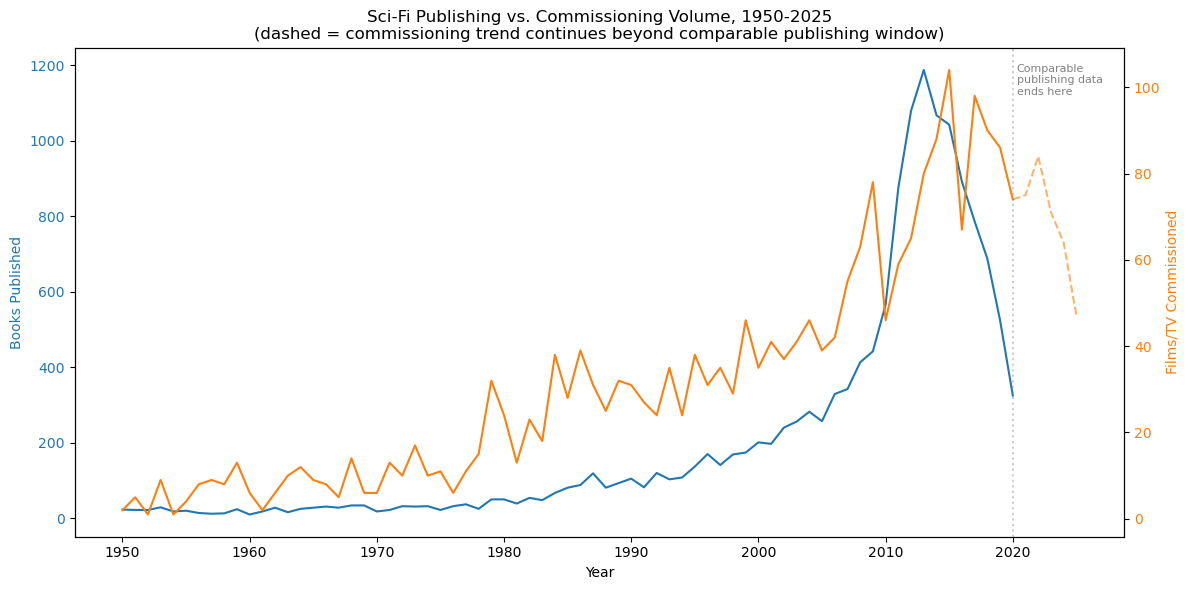

In [111]:
def plot_total_volume_extended(pub_df, comm_df, save=True):
    pub_total = pub_df[pub_df['Year_published'] <= 2020].groupby('Year_published')['book_count'].sum().reset_index()
    comm_total_full = comm_df.groupby('Year_released')['title_count'].sum().reset_index()

    fig, ax1 = plt.subplots(figsize=(12, 6))

    ax1.plot(pub_total['Year_published'], pub_total['book_count'], color='tab:blue', label='Books Published (1950-2020)')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Books Published', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    ax2 = ax1.twinx()
    comm_comparable = comm_total_full[comm_total_full['Year_released'] <= 2020]
    comm_extended = comm_total_full[comm_total_full['Year_released'] >= 2020]
    ax2.plot(comm_comparable['Year_released'], comm_comparable['title_count'], color='tab:orange', label='Films/TV Commissioned')
    ax2.plot(comm_extended['Year_released'], comm_extended['title_count'], color='tab:orange', linestyle='--', alpha=0.6)
    ax2.set_ylabel('Films/TV Commissioned', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    ax1.axvline(x=2020, color='gray', linestyle=':', alpha=0.4)
    ax1.text(2020.3, ax1.get_ylim()[1]*0.9, 'Comparable\npublishing data\nends here', fontsize=8, color='gray')

    plt.title('Sci-Fi Publishing vs. Commissioning Volume, 1950-2025\n(dashed = commissioning trend continues beyond comparable publishing window)')
    fig.tight_layout()
    if save:
        plt.savefig('../03_visualizations/total_volume_comparison_extended.png', dpi=150)
    plt.show()

plot_total_volume_extended(publishing_yearly_theme_counts, yearly_commissioning_theme_counts)

In [112]:
# ============================================
# CHART — Total Publishing vs. Commissioning Volume, 1950-2025 (extended)
# ============================================
# Goal: build the headline comparison of total sci-fi book publishing
# volume against total film/TV commissioning volume, keeping books
# scoped to the comparable 1950-2020 window while extending the
# commissioning line through 2025 (dashed beyond 2020), since
# commissioning data has no equivalent coverage limitation.
#
# 1. Filter publishing_yearly_theme_counts to Year <= 2020, aggregate
#    to total books per year
# 2. Aggregate yearly_commissioning_theme_counts to total titles per
#    year across the FULL range (1950-2025)
# 3. Plot books as a solid line (1950-2020 only)
# 4. Plot commissioning as solid through 2020, then dashed/semi-
#    transparent from 2020-2025, to visually distinguish the
#    comparable window from the commissioning-only extension
# 5. Mark 2020 with a dotted vertical line and label, clarifying
#    exactly where the comparable publishing data ends
# 6. Save to 03_visualizations/total_volume_comparison_extended.png
# ============================================


# ============================================
# FINDINGS — Total Volume, 1950-2025 (extended)
# ============================================
# - Within the comparable 1950-2020 window: both series show a shared
#   long-term upward trend from the 1990s through the mid-2010s; books
#   peak sharply around 2013 (~1,190), commissioning peaks slightly
#   later and more gradually around 2015 (~104), then both decline
#   toward 2020
# - Extending commissioning alone through 2025 reveals real activity
#   beyond the comparable window: a partial recovery/second peak
#   around 2022 (~84 titles) before declining again through 2025
#   (~47) — this dip-recovery-decline pattern is new information not
#   visible in the 1950-2020-only version
# - Since this extension only shows commissioning (no publishing
#   comparison exists for this period in the core dataset), it should
#   be read as "what continued to happen in commissioning" rather than
#   evidence of any lag or gap relationship with publishing — no
#   comparative claim is being made for 2021-2025 in this chart
# - The 2022 mini-peak in commissioning is worth cross-referencing
#   against theme-level patterns (e.g. does it concentrate in
#   robots/AI-related content, consistent with the ChatGPT-era boom
#   already observed in the robots chart's Hugo/Nebula-adjacent
#   signal) — a natural bridge into the separate 2021-2025 mini-
#   analysis planned using the Hugo/Nebula publishing supplement
# ============================================

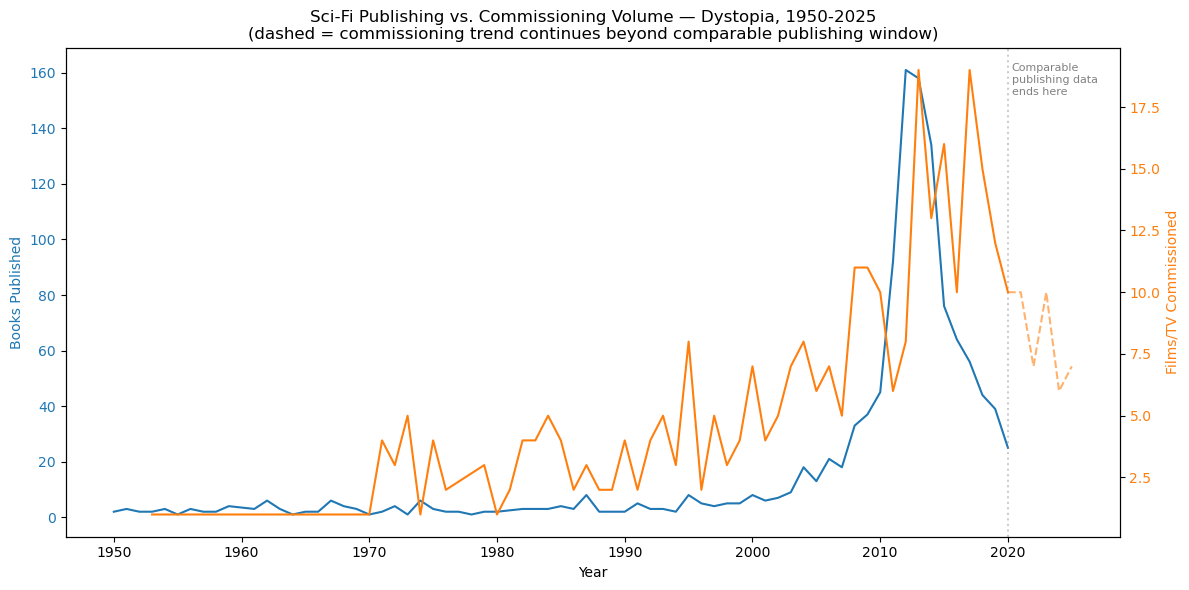

In [116]:
plot_theme_with_extended_commissioning('dystopia', publishing_yearly_theme_counts, yearly_commissioning_theme_counts)

In [ ]:
# ============================================
# CHART — Publishing vs. Commissioning Volume, Dystopia, 1950-2020
# ============================================
# Goal: same dual-axis theme-level comparison as before, rebuilt via
# the reusable plot_theme_comparison function, scoped consistently
# to 1950-2020 across both series.
#
# 1. Filter publishing_yearly_theme_counts and
#    yearly_commissioning_theme_counts to theme == 'dystopia' and
#    Year <= 2020
# 2. Plot both filtered series on a dual-axis line chart (two y-axes,
#    given the scale difference between book counts and commissioning
#    counts)
# 3. Save to 03_visualizations/dystopia_comparison.png
# ============================================


# ============================================
# FINDINGS — Dystopia, 1950-2020
# ============================================
# - Both publishing and commissioning volume are flat and minimal
#   from 1950 through the late 1980s — dystopia wasn't a major
#   presence in either medium until relatively recently
# - Commissioning shows real, sustained activity building from the
#   1970s onward, notably earlier and more consistently than book
#   volume — commissioning appears to have engaged with dystopian
#   themes well before publishing volume caught up
# - Books show a dramatic, sharp spike around 2012-2013 (peaking
#   near 160), aligning with the well-documented real-world YA
#   dystopian publishing boom (Hunger Games / Divergent / Maze
#   Runner era) — a genuine, recognizable cultural moment captured
#   in the data
# - Commissioning also spikes in the same general window, peaking
#   slightly later and staying comparatively elevated longer —
#   suggesting film/TV continued drawing on dystopian material for
#   a period after book publishing's peak had passed
# - Both series decline toward the end of the window (2017-2020),
#   with books declining more steeply than commissioning — a
#   pattern consistent with the natural cooling of a trend-driven
#   publishing boom, while adaptations and related commissioning
#   activity persisted somewhat longer
# - Strong candidate chart for the presentation — captures a real,
#   recognizable cultural moment (2012-2013 YA dystopia boom) that
#   gives the audience an immediate point of connection to the data,
#   and shows a plausible lag pattern between the two industries
# ============================================

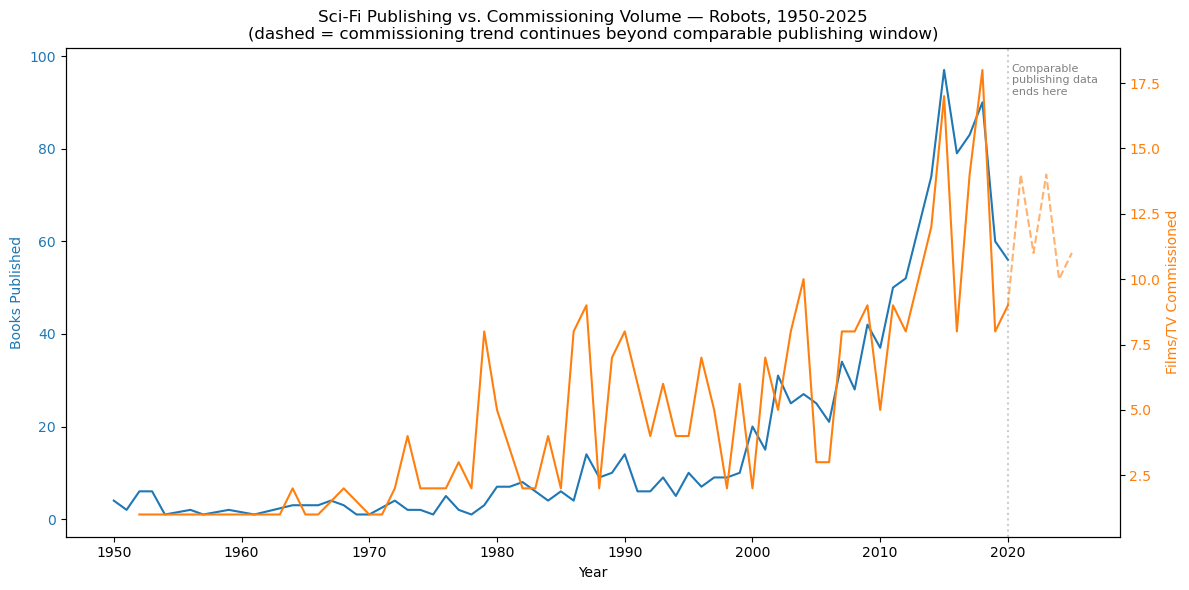

In [115]:
def plot_theme_with_extended_commissioning(theme_name, pub_df, comm_df, save=True):
    pub_theme = pub_df[(pub_df['theme'] == theme_name) & (pub_df['Year_published'] <= 2020)]
    comm_theme_full = comm_df[comm_df['theme'] == theme_name]  # full range, 1950-2025

    fig, ax1 = plt.subplots(figsize=(12, 6))

    ax1.plot(pub_theme['Year_published'], pub_theme['book_count'], color='tab:blue', label='Books Published (1950-2020)')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('Books Published', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    ax2 = ax1.twinx()
    # Solid line through 2020 (comparable window), dashed after (commissioning-only)
    comm_comparable = comm_theme_full[comm_theme_full['Year_released'] <= 2020]
    comm_extended = comm_theme_full[comm_theme_full['Year_released'] >= 2020]
    ax2.plot(comm_comparable['Year_released'], comm_comparable['title_count'], color='tab:orange', label='Films/TV Commissioned')
    ax2.plot(comm_extended['Year_released'], comm_extended['title_count'], color='tab:orange', linestyle='--', alpha=0.6)
    ax2.set_ylabel('Films/TV Commissioned', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    ax1.axvline(x=2020, color='gray', linestyle=':', alpha=0.4)
    ax1.text(2020.3, ax1.get_ylim()[1]*0.9, 'Comparable\npublishing data\nends here', fontsize=8, color='gray')

    plt.title(f'Sci-Fi Publishing vs. Commissioning Volume — {theme_name.title()}, 1950-2025\n(dashed = commissioning trend continues beyond comparable publishing window)')
    fig.tight_layout()
    if save:
        plt.savefig(f'../03_visualizations/{theme_name}_comparison_extended.png', dpi=150)
    plt.show()

plot_theme_with_extended_commissioning('robots', publishing_yearly_theme_counts, yearly_commissioning_theme_counts)

In [ ]:
# ============================================
# CHART — Publishing vs. Commissioning Volume, Robots, 1950-2025 (extended)
# ============================================
# Goal: same theme-level comparison, robots theme (includes
# artificial intelligence per the keyword mapping), keeping books
# scoped to 1950-2020 while extending commissioning through 2025
# (dashed beyond 2020) — updated for consistency with the dystopia
# and total-volume extended versions.
#
# 1. Filter publishing_yearly_theme_counts to theme == 'robots' and
#    Year <= 2020
# 2. Filter yearly_commissioning_theme_counts to theme == 'robots'
#    across the FULL range (1950-2025)
# 3. Plot books as a solid line (1950-2020 only)
# 4. Plot commissioning as solid through 2020, dashed/semi-transparent
#    from 2020-2025
# 5. Mark 2020 with a dotted vertical line and label
# 6. Save to 03_visualizations/robots_comparison_extended.png
# ============================================


# ============================================
# FINDINGS — Robots (includes AI-tagged content), 1950-2025 (extended)
# ============================================
# - Within the comparable 1950-2020 window: both series climb
#   together gradually from the 1970s onward and track each other
#   more closely than any other theme examined — peaking in the same
#   general window (roughly 2014-2018) with near-tandem oscillation
#   throughout the 2000s-2010s, then declining together toward 2020
# - Extending commissioning alone through 2025 is the most directly
#   relevant result in the whole project given the AI-anxiety framing:
#   commissioning does NOT collapse after 2020 — it stays meaningfully
#   elevated and continues an active pattern through 2021-2025,
#   plausibly reflecting the real ChatGPT-era AI boom (late 2022
#   onward)
# - Since no publishing comparison exists for this period in the core
#   dataset, this extension shows "commissioning activity continued
#   and stayed strong" rather than a lag/gap claim against publishing
# - This is the strongest bridge into the 2021-2025 mini-analysis:
#   the manually-tagged Hugo/Nebula robots/AI theme data can now be
#   directly checked against this sustained commissioning activity to
#   see whether publishing also picked back up post-2022, which would
#   be a genuinely compelling capstone finding for the whole project
# ============================================

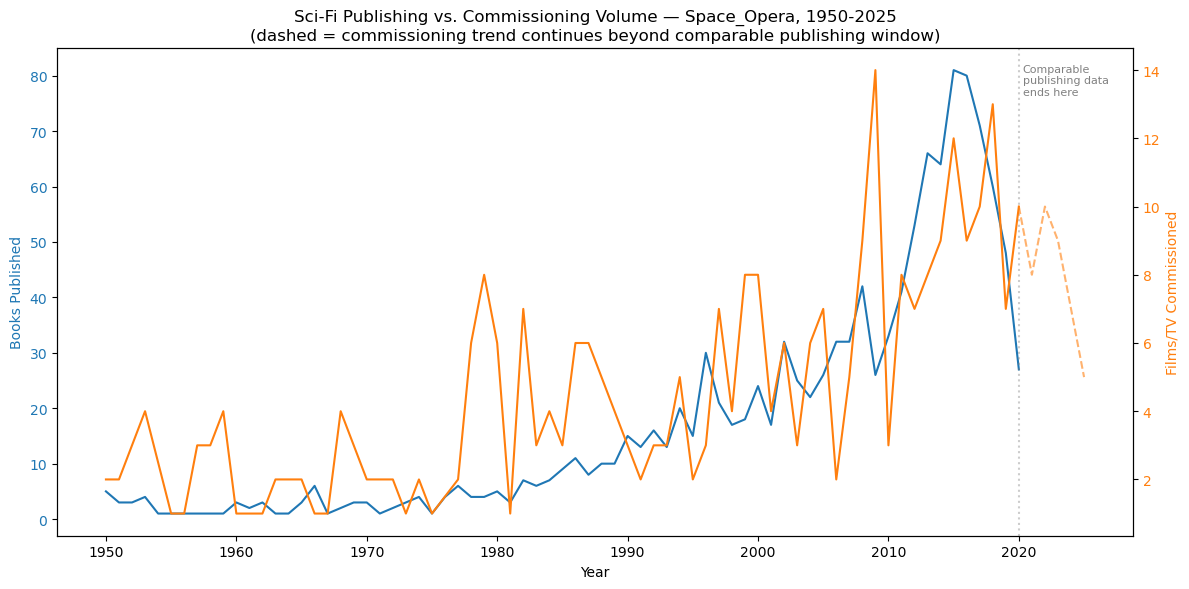

In [117]:
plot_theme_with_extended_commissioning('space_opera', publishing_yearly_theme_counts, yearly_commissioning_theme_counts)

In [118]:
# ============================================
# CHART — Publishing vs. Commissioning Volume, Space Opera, 1950-2025 (extended)
# ============================================
# Goal: same theme-level comparison structure as dystopia/robots, for
# space_opera — the highest-volume theme in the dataset — keeping
# books scoped to 1950-2020 while extending commissioning through
# 2025 (dashed beyond 2020).
#
# 1. Filter publishing_yearly_theme_counts to theme == 'space_opera'
#    and Year <= 2020
# 2. Filter yearly_commissioning_theme_counts to theme == 'space_opera'
#    across the FULL range (1950-2025)
# 3. Plot books as a solid line (1950-2020 only)
# 4. Plot commissioning as solid through 2020, dashed/semi-transparent
#    from 2020-2025
# 5. Mark 2020 with a dotted vertical line and label
# 6. Save to 03_visualizations/space_opera_comparison_extended.png
# ============================================


# ============================================
# FINDINGS — Space Opera, 1950-2025 (extended)
# ============================================
# - Both series are low and choppy through the 1950s-1970s, with
#   commissioning showing early, isolated spikes (e.g. ~1952, ~1959,
#   ~1968) well before book volume registers meaningfully — likely
#   tied to a handful of major individual releases rather than a
#   sustained trend this early
# - A large, early commissioning spike appears around 1979 (peaking
#   near 8 titles) while books remain flat and low — plausibly tied
#   to the post-Star Wars (1977) sci-fi boom reshaping the film
#   industry, a real-world event that predates meaningful book-side
#   volume in this theme by years
# - From the late 1970s onward, both series begin a shared long-term
#   climb, with commissioning consistently leading or matching book
#   volume through most of the 1980s-2000s
# - Books and commissioning converge and rise together sharply from
#   the mid-2000s onward, both peaking in the 2013-2018 window
#   (books ~80-81, commissioning ~13-14), the tightest correlation
#   period in the whole series for this theme
# - Extending commissioning alone through 2025 shows continued,
#   substantial activity (oscillating in the 9-10 range) rather than
#   a sharp decline — space opera commissioning remains a strong,
#   active category post-2020, unlike some other themes
# - Notable candidate finding: the 1979 commissioning spike preceding
#   sustained book growth is one of the clearest examples in the
#   whole dataset of commissioning (driven by a single cultural
#   event) appearing to lead publishing rather than follow it —
#   worth flagging as a counterpoint to the assumption that books
#   always lead the industry
# ============================================

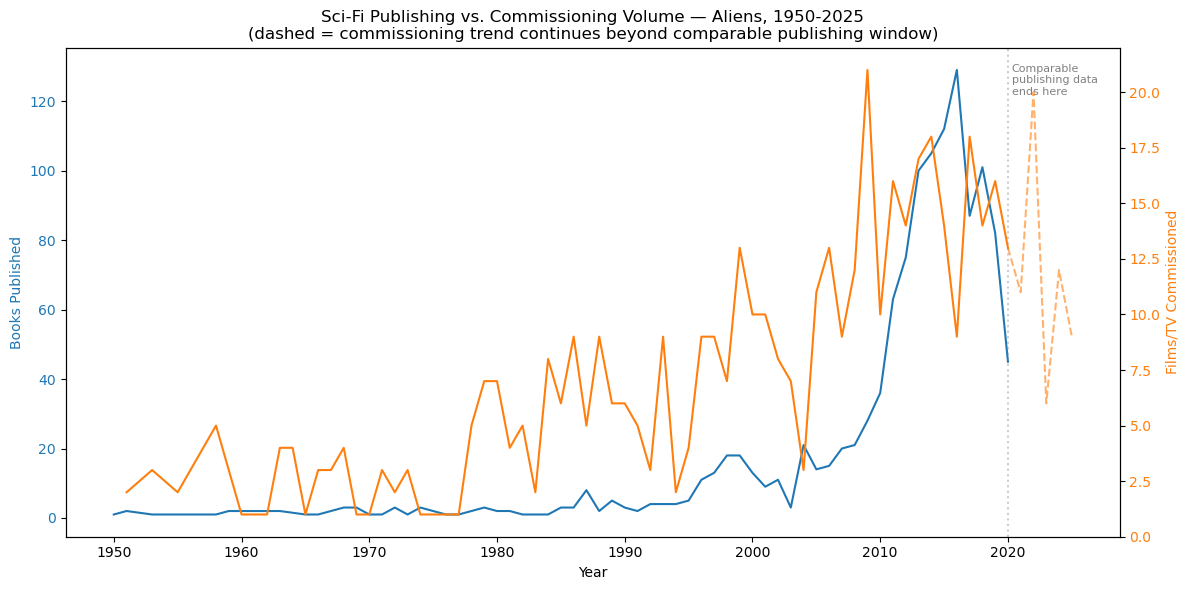

In [119]:
plot_theme_with_extended_commissioning('aliens', publishing_yearly_theme_counts, yearly_commissioning_theme_counts)

In [120]:
# ============================================
# CHART — Publishing vs. Commissioning Volume, Aliens, 1950-2025 (extended)
# ============================================
# Goal: same theme-level comparison structure, aliens theme — keeping
# books scoped to 1950-2020 while extending commissioning through
# 2025 (dashed beyond 2020).
#
# 1. Filter publishing_yearly_theme_counts to theme == 'aliens' and
#    Year <= 2020
# 2. Filter yearly_commissioning_theme_counts to theme == 'aliens'
#    across the FULL range (1950-2025)
# 3. Plot books as a solid line (1950-2020 only)
# 4. Plot commissioning as solid through 2020, dashed/semi-transparent
#    from 2020-2025
# 5. Mark 2020 with a dotted vertical line and label
# 6. Save to 03_visualizations/aliens_comparison_extended.png
# ============================================


# ============================================
# FINDINGS — Aliens, 1950-2025 (extended)
# ============================================
# - Commissioning shows real, sustained activity from the 1950s
#   onward — a genre staple of film/TV since its earliest decades,
#   with visible spikes as early as 1958 and steady presence through
#   the 1960s-70s, well before book volume registers meaningfully
# - Books stay flat and minimal until the mid-1990s, then begin a
#   slow climb, while commissioning has already been active and
#   growing for decades — this is the clearest example yet of
#   commissioning consistently leading publishing for an extended
#   period, not just a single early spike like space opera's 1979
#   moment
# - Both series accelerate sharply from the mid-2000s onward, with
#   books eventually catching up and even surpassing commissioning's
#   raw volume by 2016 (books ~128 vs. commissioning's own peak
#   ~20-21 around 2009) — though the two are on different scales, so
#   this crossing shouldn't be over-read as a literal "books overtook
#   film" claim, more that book volume grew dramatically once it did
#   start climbing
# - Both series show real volatility in the final years before 2020 —
#   books dip and rebound sharply (dropping to ~52 then rising to
#   ~128), and commissioning has a similarly jagged pattern — this
#   makes the aliens theme noisier than dystopia or robots, harder to
#   draw a single clean narrative from
# - Extending commissioning through 2025 shows continued strong,
#   volatile activity (ranging roughly 6-21), not a decline —
#   aliens remains an actively commissioned theme post-2020
# - Notable finding: aliens is the strongest case in the dataset for
#   "commissioning led for decades before publishing caught up" —
#   a meaningfully different pattern from space_opera's single
#   early-spike story or robots' tight parallel correlation, useful
#   as a third distinct pattern type for the presentation
# ============================================

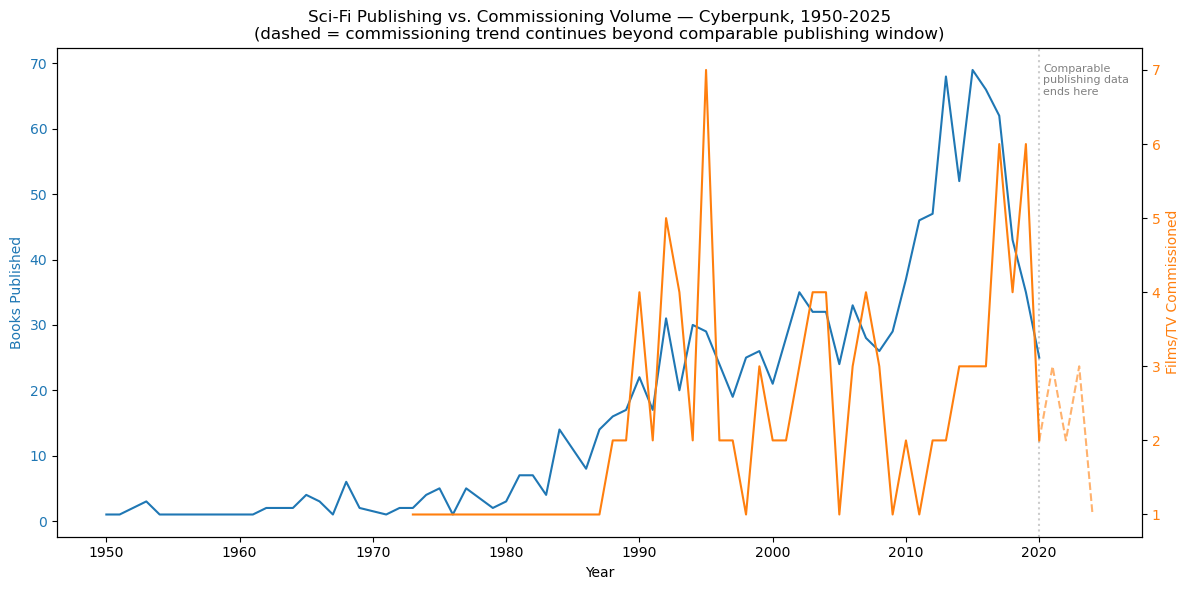

In [121]:
plot_theme_with_extended_commissioning('cyberpunk', publishing_yearly_theme_counts, yearly_commissioning_theme_counts)

In [122]:
# ============================================
# CHART — Publishing vs. Commissioning Volume, Cyberpunk, 1950-2025 (extended)
# ============================================
# Goal: same theme-level comparison structure, cyberpunk theme —
# keeping books scoped to 1950-2020 while extending commissioning
# through 2025 (dashed beyond 2020).
#
# 1. Filter publishing_yearly_theme_counts to theme == 'cyberpunk'
#    and Year <= 2020
# 2. Filter yearly_commissioning_theme_counts to theme == 'cyberpunk'
#    across the FULL range (1950-2025)
# 3. Plot books as a solid line (1950-2020 only)
# 4. Plot commissioning as solid through 2020, dashed/semi-transparent
#    from 2020-2025
# 5. Mark 2020 with a dotted vertical line and label
# 6. Save to 03_visualizations/cyberpunk_comparison_extended.png
# ============================================


# ============================================
# FINDINGS — Cyberpunk, 1950-2025 (extended)
# ============================================
# - Both series are essentially flat/near-zero until the late 1980s —
#   cyberpunk didn't exist as a meaningful theme in either medium
#   before then, consistent with the genre's real-world origin (the
#   term and genre only emerged as a recognized category starting
#   around 1984, with Neuromancer)
# - Commissioning activates first and slightly ahead of books once
#   the genre does emerge — a small early rise appears around
#   1989-1996, tracking the genre's real cultural breakout moment
#   (Blade Runner-adjacent influence, The Matrix era approaching)
# - From the late 1990s onward, books begin a slow, steady climb
#   while commissioning stays comparatively flatter and choppier —
#   unlike aliens or space_opera, cyberpunk shows a period where
#   BOOKS pull ahead of commissioning rather than the reverse
# - Books accelerate sharply from 2010 onward, reaching a much higher
#   sustained level (60-69) by 2013-2017, while commissioning stays
#   comparatively low and volatile (2-7) across the same window — the
#   widest publishing-to-commissioning gap seen in any theme so far,
#   suggesting cyberpunk is a theme readers have embraced far more
#   than the screen has
# - Extending commissioning through 2025 shows continued modest,
#   choppy activity (2-3 range) — no major post-2020 revival visible,
#   in contrast to robots' sustained AI-era activity
# - Notable finding: cyberpunk is the first theme where PUBLISHING
#   clearly outpaces commissioning by a wide and sustained margin —
#   a genuine "underrepresented on screen relative to books" case,
#   directly answering one of the project's original research
#   questions (are there themes well-represented in books but
#   underrepresented on screen?)
# ============================================

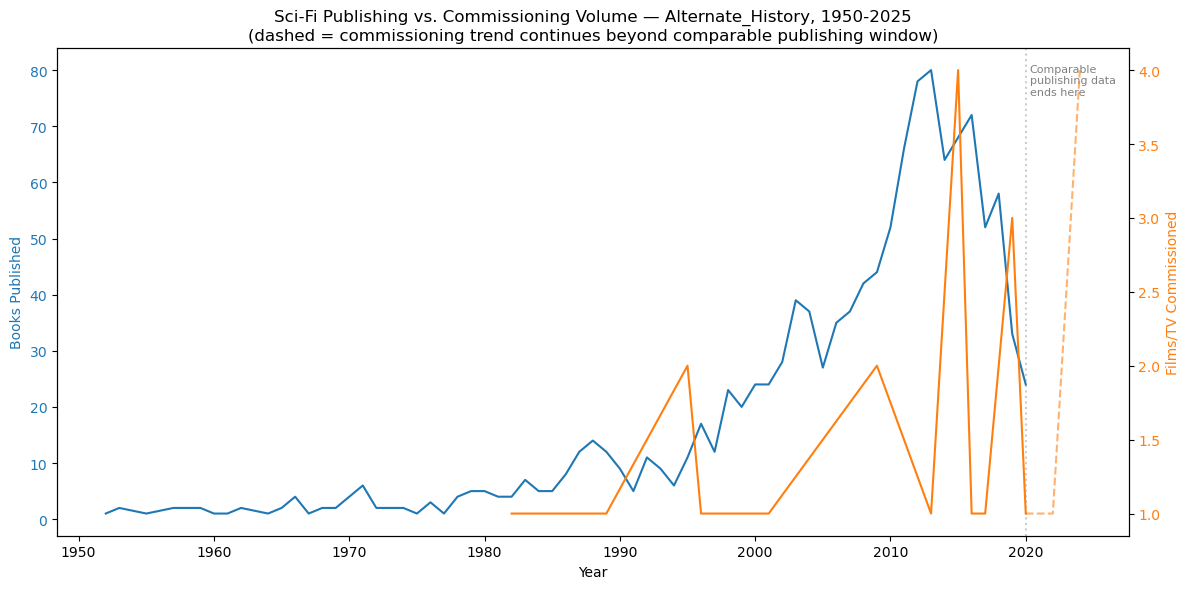

In [123]:
plot_theme_with_extended_commissioning('alternate_history', publishing_yearly_theme_counts, yearly_commissioning_theme_counts)

In [126]:
# ============================================
# CHART — Publishing vs. Commissioning Volume, Alternate History, 1950-2025 (extended)
# ============================================
# Goal: same theme-level comparison structure, alternate_history
# theme — keeping books scoped to 1950-2020 while extending
# commissioning through 2025 (dashed beyond 2020).
#
# 1. Filter publishing_yearly_theme_counts to
#    theme == 'alternate_history' and Year <= 2020
# 2. Filter yearly_commissioning_theme_counts to
#    theme == 'alternate_history' across the FULL range (1950-2025)
# 3. Plot books as a solid line (1950-2020 only)
# 4. Plot commissioning as solid through 2020, dashed/semi-transparent
#    from 2020-2025
# 5. Mark 2020 with a dotted vertical line and label
# 6. Save to 03_visualizations/alternate_history_comparison_extended.png
# ============================================


# ============================================
# FINDINGS — Alternate History, 1950-2025 (extended)
# ============================================
# - Books show a slow, steady climb from the 1950s through the
#   2000s, then a dramatic late acceleration, peaking sharply around
#   2013 (~80) — the same steep-rise pattern seen in several other
#   themes, likely part of the broader post-2000s sci-fi publishing
#   surge rather than something specific to this theme alone
# - Commissioning is essentially flat/near-zero for most of the
#   timeline, only registering meaningful activity from the early
#   1990s onward, and even then at very low absolute volume
#   (1-4 titles per year) — alternate history is a niche theme for
#   film/TV in a way it clearly isn't for books
# - Commissioning is EXTREMELY volatile in its final active years —
#   swinging sharply between ~1 and ~4 titles year to year (e.g. a
#   spike to 4 around 2013, crashing to ~1 the next year, spiking to
#   4 again around 2015) — this volatility is very likely just an
#   artifact of small absolute numbers (a swing from 1 to 4 title is
#   a 300% change but represents only 3 more titles), not a
#   meaningful trend signal — worth flagging this explicitly if this
#   chart is shown, so the volatility isn't over-interpreted
# - Extending commissioning through 2025 shows a similar small,
#   volatile pattern continuing (a jump to ~4 around 2023) — no clear
#   directional trend, consistent with a low-volume, niche category
# - Notable finding: alternate_history is your clearest example of a
#   theme where books have substantial audience/output while
#   commissioning remains persistently thin — similar in spirit to
#   cyberpunk's "underrepresented on screen" finding, but even more
#   extreme given commissioning volume rarely exceeds single digits
#   across the entire 70+ year window
# - CAVEAT for presentation: low-count themes like this one are
#   inherently noisier and less statistically reliable than
#   high-volume themes like space_opera or robots — worth being
#   upfront that swings here carry a wide margin of uncertainty
# ============================================

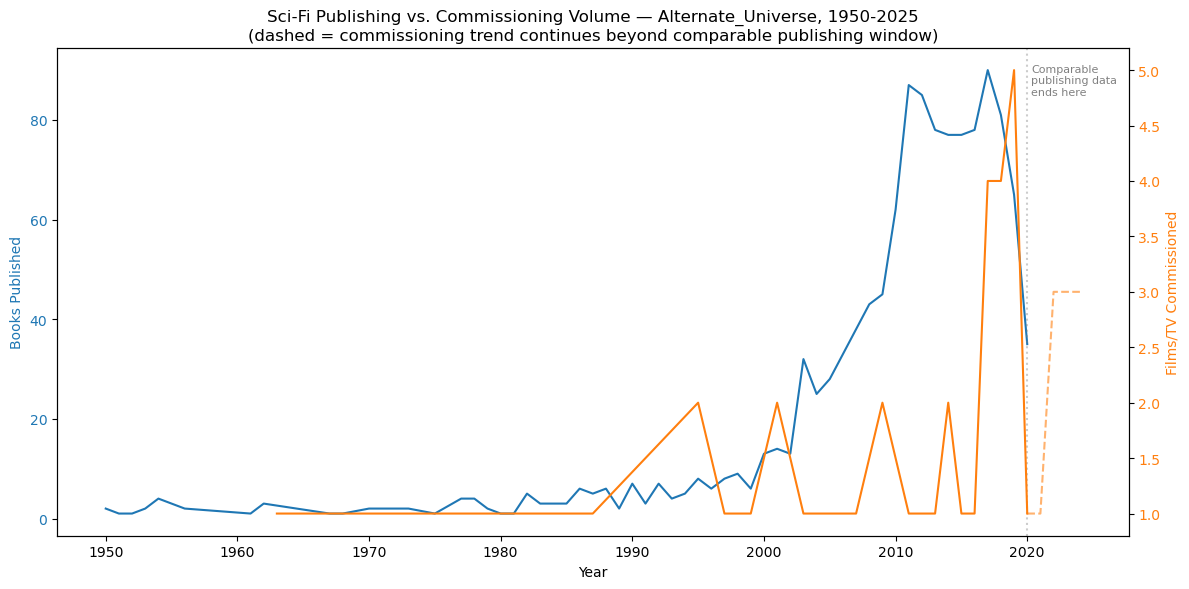

In [124]:
plot_theme_with_extended_commissioning('alternate_universe', publishing_yearly_theme_counts, yearly_commissioning_theme_counts)

In [125]:
# ============================================
# CHART — Publishing vs. Commissioning Volume, Alternate Universe, 1950-2025 (extended)
# ============================================
# Goal: same theme-level comparison structure, alternate_universe
# theme — keeping books scoped to 1950-2020 while extending
# commissioning through 2025 (dashed beyond 2020).
#
# 1. Filter publishing_yearly_theme_counts to
#    theme == 'alternate_universe' and Year <= 2020
# 2. Filter yearly_commissioning_theme_counts to
#    theme == 'alternate_universe' across the FULL range (1950-2025)
# 3. Plot books as a solid line (1950-2020 only)
# 4. Plot commissioning as solid through 2020, dashed/semi-transparent
#    from 2020-2025
# 5. Mark 2020 with a dotted vertical line and label
# 6. Save to 03_visualizations/alternate_universe_comparison_extended.png
# ============================================


# ============================================
# FINDINGS — Alternate Universe, 1950-2025 (extended)
# ============================================
# - Both series are flat/minimal through most of the 20th century,
#   with books beginning a real, sustained climb starting around
#   1990 and accelerating sharply from 2010 onward, peaking near
#   87 books around 2013-2016 — following the same late-surge pattern
#   seen in most other themes in this dataset
# - Commissioning stays persistently low and choppy (0-2 titles per
#   year) through almost the entire timeline, similar in shape to
#   alternate_history — another theme where books dramatically
#   outpace commissioning in raw volume, though the small-numbers
#   caveat applies here too (a swing from 0 to 2 is easy to
#   over-read)
# - Right at the end of the comparable window (2018-2020),
#   commissioning breaks its historical pattern and jumps to 4
#   titles — a real departure from its own baseline, worth noting
#   even accounting for small-number volatility
# - Extending commissioning through 2025 shows this elevated level
#   (around 3 titles) largely sustained rather than reverting to the
#   historical near-zero baseline — suggesting alternate-universe
#   content may have genuinely become more commissioned recently
#   (multiverse-driven franchise content, e.g. the broader industry's
#   post-2018 multiverse trend across major franchises, is a
#   plausible real-world driver worth mentioning narratively, even
#   though this project can't establish causation)
# - Notable finding: another "books far outpace commissioning" theme
#   like alternate_history and cyberpunk, but with a distinct twist —
#   a late, sustained uptick in commissioning right as the comparable
#   window ends, which is the kind of pattern worth flagging as
#   possibly connected to the broader "multiverse" trend that became
#   prominent in film/TV starting around 2018-2022
# ============================================

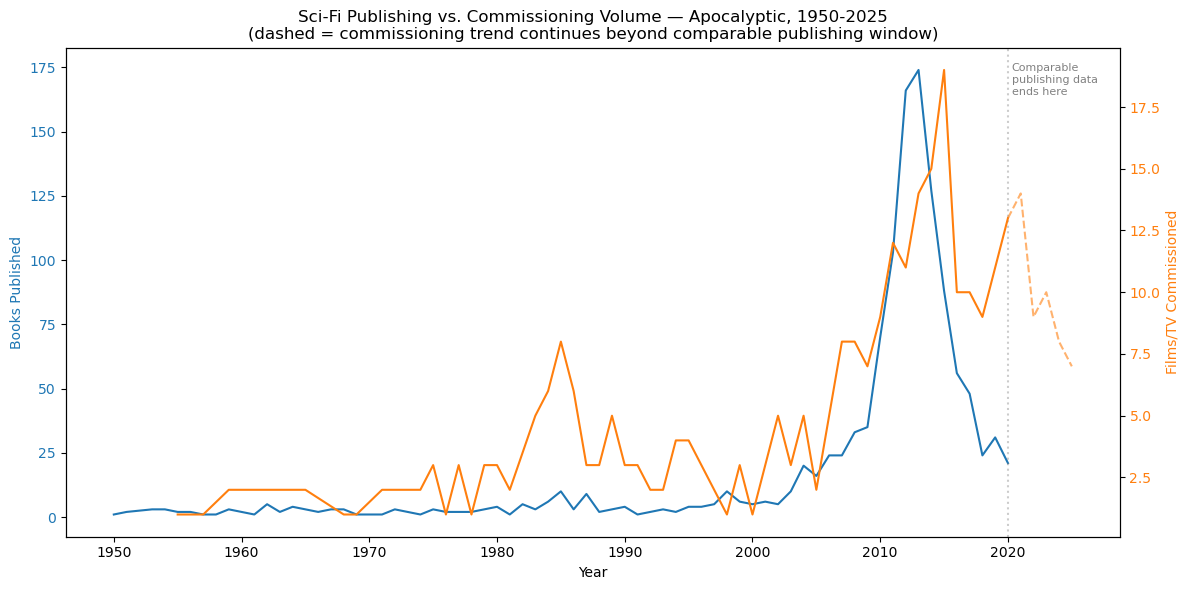

In [127]:
plot_theme_with_extended_commissioning('apocalyptic', publishing_yearly_theme_counts, yearly_commissioning_theme_counts)

In [128]:
# ============================================
# CHART — Publishing vs. Commissioning Volume, Apocalyptic, 1950-2025 (extended)
# ============================================
# Goal: same theme-level comparison structure, apocalyptic theme —
# keeping books scoped to 1950-2020 while extending commissioning
# through 2025 (dashed beyond 2020).
#
# 1. Filter publishing_yearly_theme_counts to theme == 'apocalyptic'
#    and Year <= 2020
# 2. Filter yearly_commissioning_theme_counts to theme == 'apocalyptic'
#    across the FULL range (1950-2025)
# 3. Plot books as a solid line (1950-2020 only)
# 4. Plot commissioning as solid through 2020, dashed/semi-transparent
#    from 2020-2025
# 5. Mark 2020 with a dotted vertical line and label
# 6. Save to 03_visualizations/apocalyptic_comparison_extended.png
# ============================================


# ============================================
# FINDINGS — Apocalyptic, 1950-2025 (extended)
# ============================================
# - Commissioning shows real, sustained activity decades before
#   books — a notable early spike around 1985 (~7-8 titles) with
#   ongoing choppy-but-present activity through the 1990s-2000s,
#   while books remain flat and minimal until roughly 2005 — another
#   clear case of commissioning leading publishing for an extended
#   stretch, similar in pattern to aliens
# - Both series accelerate dramatically together from the mid-2000s
#   onward, converging into the strongest, most synchronized peak in
#   the entire dataset: books reach ~174 and commissioning reaches
#   ~18 in the same narrow window around 2013-2015 — this is the
#   highest raw book volume seen in any theme examined so far,
#   suggesting apocalyptic content was a major driver of the broader
#   2013-era publishing surge visible in the total-volume chart
# - After the shared peak, both decline together through 2018-2020,
#   maintaining a closely correlated shape even in the downturn —
#   unlike cyberpunk or alternate_history, this theme doesn't show
#   books and commissioning diverging in either direction
# - Extending commissioning through 2025 shows a genuine late
#   rebound — climbing back up to ~14 around 2022-2023 before
#   declining again toward 2025 — one of the more pronounced
#   post-2020 recoveries seen among the themes examined, plausibly
#   tied to real-world anxieties (pandemic-era and climate-related)
#   feeding sustained apocalyptic/post-apocalyptic content demand
# - Notable finding: apocalyptic is the strongest example yet of
#   both extended early-commissioning-lead behavior AND tight
#   synchronized peak/decline correlation — plus a real, sizeable
#   post-2020 rebound worth cross-referencing against the Hugo/Nebula
#   theme data in the planned recent-signal mini-analysis
# ============================================

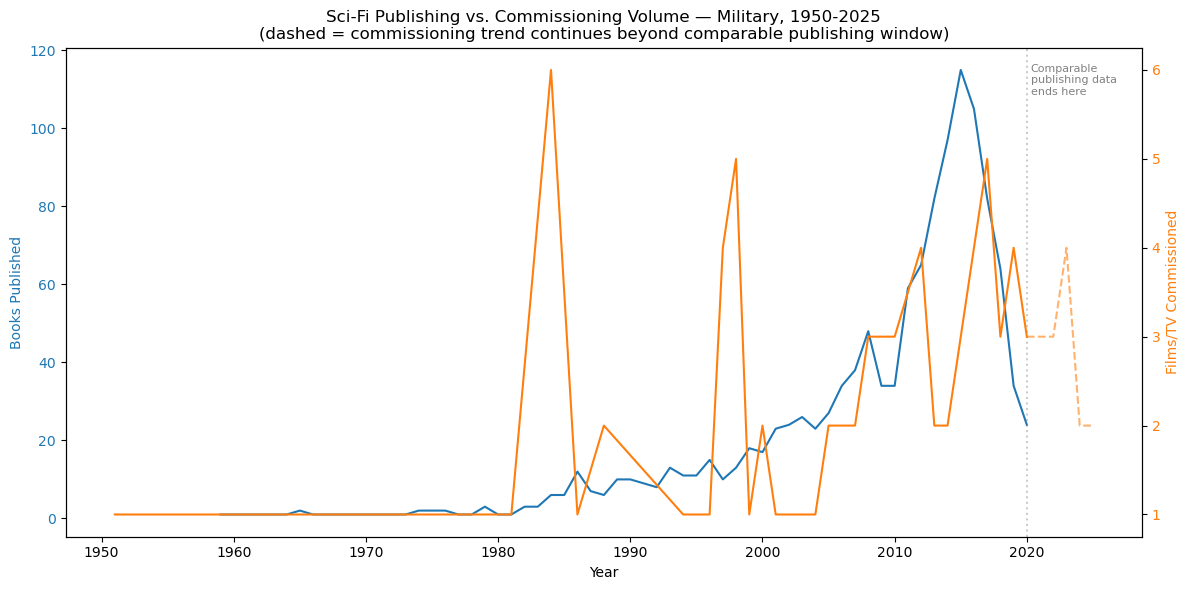

In [129]:
plot_theme_with_extended_commissioning('military', publishing_yearly_theme_counts, yearly_commissioning_theme_counts)

In [130]:
# ============================================
# CHART — Publishing vs. Commissioning Volume, Military, 1950-2025 (extended)
# ============================================
# Goal: same theme-level comparison structure, military theme —
# keeping books scoped to 1950-2020 while extending commissioning
# through 2025 (dashed beyond 2020).
#
# 1. Filter publishing_yearly_theme_counts to theme == 'military'
#    and Year <= 2020
# 2. Filter yearly_commissioning_theme_counts to theme == 'military'
#    across the FULL range (1950-2025)
# 3. Plot books as a solid line (1950-2020 only)
# 4. Plot commissioning as solid through 2020, dashed/semi-transparent
#    from 2020-2025
# 5. Mark 2020 with a dotted vertical line and label
# 6. Save to 03_visualizations/military_comparison_extended.png
# ============================================


# ============================================
# FINDINGS — Military, 1950-2025 (extended)
# ============================================
# - Both series are essentially flat/near-zero until the early 1980s
#   — this theme has almost no presence in either medium for the
#   first three decades of the dataset
# - Commissioning shows a sharp, isolated spike around 1984 (~6
#   titles, its highest point in the entire series) while books
#   remain completely flat — likely tied to a specific real-world
#   moment (Cold War-era military sci-fi film cycle) rather than a
#   sustained trend, since commissioning drops right back to near-
#   zero immediately after
# - A second isolated commissioning spike appears around 1998 (~5
#   titles), again with books remaining low — this theme shows a
#   pattern of sharp, isolated commissioning spikes rather than
#   steady growth, unlike almost every other theme examined
# - From the mid-2000s onward, both series begin climbing together,
#   and by 2012-2016 they track each other unusually closely — books
#   and commissioning rise and fall almost in lockstep, similar to
#   the tight correlation seen in the robots theme, peaking together
#   around 2015-2016 (books ~115, commissioning ~5-6)
# - Extending commissioning through 2025 shows continued moderate
#   activity (2-4 titles), including a late uptick around 2023 — no
#   dramatic decline, staying roughly consistent with recent years
# - Notable finding: military is a theme of two distinct eras — early
#   decades marked by sharp, one-off commissioning spikes with no
#   book-side counterpart, followed by a later period (2005 onward)
#   of genuine tight correlation similar to robots. This "two-phase"
#   structure is a distinct pattern not seen in the other themes so
#   far, worth mentioning as evidence that theme-industry
#   relationships can shift character over time rather than staying
#   consistent across a theme's whole history
# ============================================

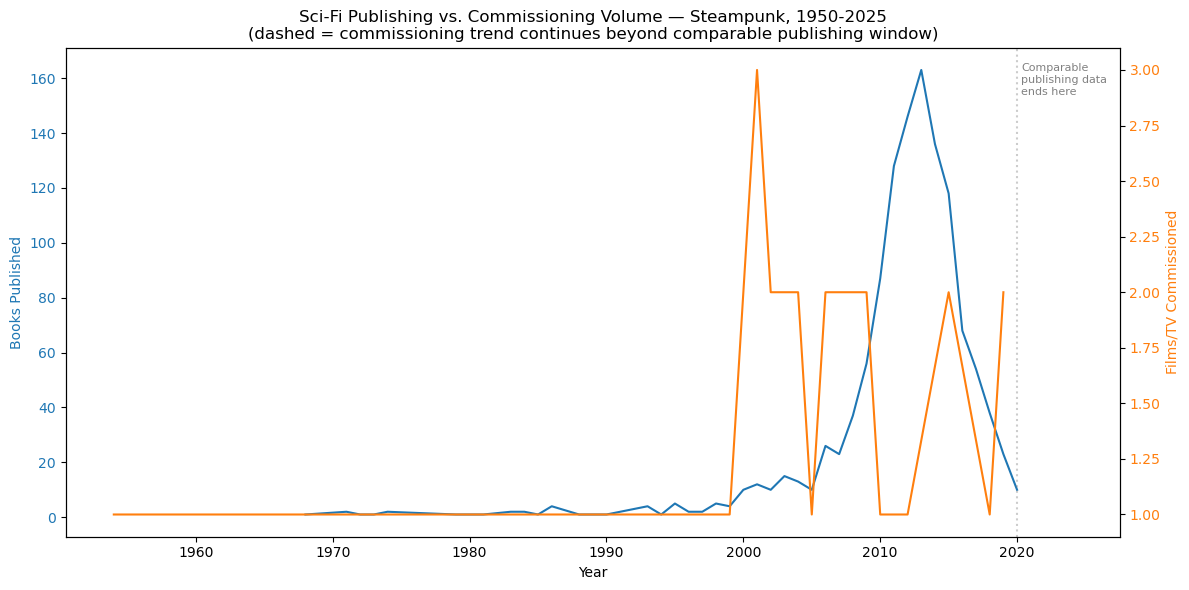

In [131]:
plot_theme_with_extended_commissioning('steampunk', publishing_yearly_theme_counts, yearly_commissioning_theme_counts)

In [132]:
# ============================================
# CHART — Publishing vs. Commissioning Volume, Steampunk, 1950-2025 (extended)
# ============================================
# Goal: same theme-level comparison structure, steampunk theme —
# keeping books scoped to 1950-2020 while extending commissioning
# through 2025 (dashed beyond 2020).
#
# 1. Filter publishing_yearly_theme_counts to theme == 'steampunk'
#    and Year <= 2020
# 2. Filter yearly_commissioning_theme_counts to theme == 'steampunk'
#    across the FULL range (1950-2025)
# 3. Plot books as a solid line (1950-2020 only)
# 4. Plot commissioning as solid through 2020, dashed/semi-transparent
#    from 2020-2025
# 5. Mark 2020 with a dotted vertical line and label
# 6. Save to 03_visualizations/steampunk_comparison_extended.png
# ============================================


# ============================================
# FINDINGS — Steampunk, 1950-2025 (extended)
# ============================================
# - Both series are completely flat/zero until right around 1999-2000
#   — steampunk has essentially no presence in either medium before
#   this point, consistent with the genre's real-world identity as a
#   relatively modern subgenre label (the term existed earlier, but
#   mainstream visibility is a late-1990s/2000s phenomenon)
# - Commissioning spikes sharply and immediately around 2001 (jumping
#   to its all-time peak of 3 titles) while books are still near
#   zero — commissioning clearly moves first here, similar to the
#   aliens/apocalyptic "commissioning leads" pattern, though on a
#   tiny absolute scale
# - Books don't begin real growth until nearly a decade later
#   (~2010), then rise sharply to a striking peak around 2013
#   (~163 books) — one of the highest per-theme book peaks in the
#   whole dataset, especially notable given how minor this theme
#   is on the commissioning side throughout
# - Commissioning stays extremely low and choppy throughout (peaking
#   at just 3 titles total, most years at 1-2) — this is the lowest
#   absolute commissioning volume of any theme examined so far,
#   making it the most extreme "underrepresented on screen" case in
#   the dataset, more so than cyberpunk or alternate_history
# - CAVEAT (important for this theme specifically): with commissioning
#   maxing out at just 3 titles across the ENTIRE 70-year window, this
#   data is far too sparse to support any real trend claims about the
#   commissioning side — every "spike" here is a difference of 1-2
#   titles. This theme should be presented cautiously, if at all, and
#   framed primarily as a books-side story rather than a comparative one
# - Extending commissioning through 2025 shows continued minimal
#   activity (staying at 2), no meaningful change
# - Notable finding: steampunk is a strong, almost extreme example of
#   "books embraced this theme, screen barely touched it" — but the
#   commissioning-side numbers are too small to draw confident
#   comparative conclusions from; worth including as a books-side
#   observation, but flagging the data-sparsity caveat clearly if used
# ============================================

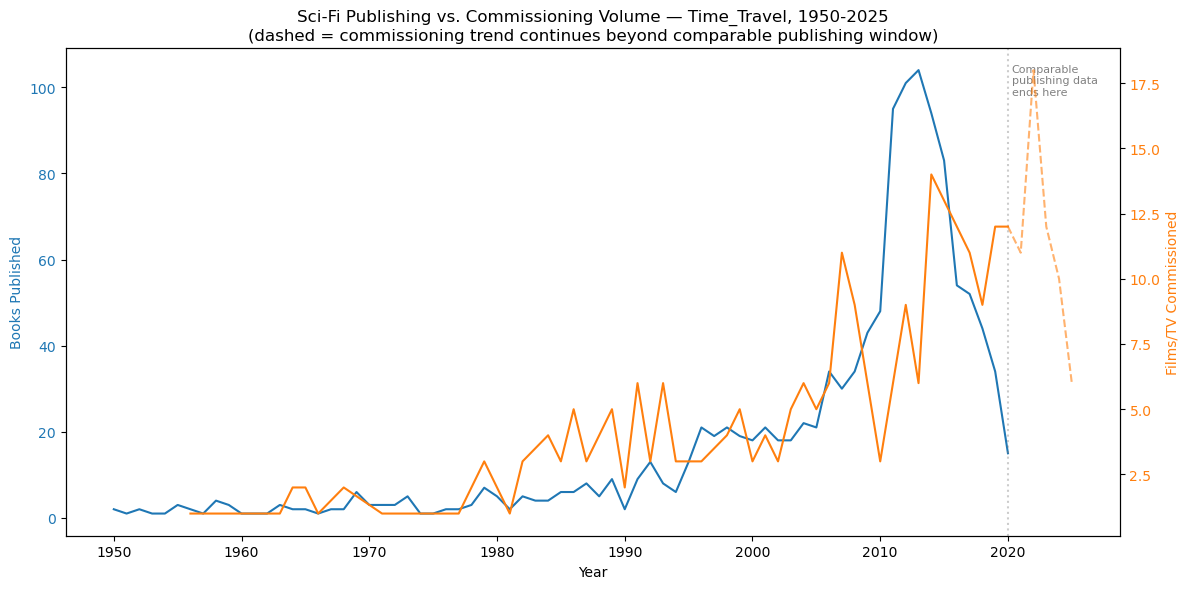

In [133]:
plot_theme_with_extended_commissioning('time_travel', publishing_yearly_theme_counts, yearly_commissioning_theme_counts)

In [134]:
# ============================================
# CHART — Publishing vs. Commissioning Volume, Time Travel, 1950-2025 (extended)
# ============================================
# Goal: same theme-level comparison structure, time_travel theme —
# keeping books scoped to 1950-2020 while extending commissioning
# through 2025 (dashed beyond 2020).
#
# 1. Filter publishing_yearly_theme_counts to theme == 'time_travel'
#    and Year <= 2020
# 2. Filter yearly_commissioning_theme_counts to theme == 'time_travel'
#    across the FULL range (1950-2025)
# 3. Plot books as a solid line (1950-2020 only)
# 4. Plot commissioning as solid through 2020, dashed/semi-transparent
#    from 2020-2025
# 5. Mark 2020 with a dotted vertical line and label
# 6. Save to 03_visualizations/time_travel_comparison_extended.png
# ============================================


# ============================================
# FINDINGS — Time Travel, 1950-2025 (extended)
# ============================================
# - Commissioning shows real, sustained activity well before books,
#   building steadily from the late 1970s onward with meaningful
#   volume through the 1980s-2000s, while books remain low and flat
#   through most of this period — another clear case of commissioning
#   leading publishing for an extended stretch, similar to aliens and
#   apocalyptic
# - Both series accelerate together from the mid-2000s onward, with
#   books eventually surging past commissioning in raw terms — books
#   peak sharply around 2013 (~104), while commissioning peaks
#   slightly later around 2013-2014 (~14) — the two peaks land close
#   together in time even though the scale differs substantially
# - After the shared 2013-2014 peak, both decline together through
#   2018-2020, maintaining a reasonably correlated shape in the
#   downturn, similar to apocalyptic's synchronized decline
# - Extending commissioning through 2025 shows a striking late
#   development: commissioning climbs to its highest levels in the
#   ENTIRE dataset (reaching ~12 around 2021-2022, matching or
#   exceeding its pre-2020 peak) before declining again toward 2025
#   — one of the most pronounced post-2020 rebounds of any theme
#   examined, on par with apocalyptic's recovery
# - Notable finding: time_travel combines two strong patterns —
#   commissioning leading for decades early on (like aliens), and a
#   genuine, substantial post-2020 commissioning rebound (like
#   apocalyptic and robots) — making it one of the more dynamic,
#   multi-phase themes in the dataset and a strong candidate for the
#   recent-signal mini-analysis, alongside robots and apocalyptic
# ============================================

In [ ]:
# ============================================
# MINI-ANALYSIS — Recent Signal, 2021-2025 (Hugo/Nebula vs. Commissioning)
# ============================================
# Goal: check whether the post-2020 commissioning rebounds seen in
# robots, apocalyptic, and time_travel are echoed on the publishing
# side, using the Hugo/Nebula theme-tagged supplement — treated as a
# separate, appropriately-scoped mini-analysis given its small sample
# size (46 tagged titles across 5 years and 11 themes) rather than
# blended into the main 1950-2020 trend charts.
#
# 1. Filter publishing_yearly_theme_counts to Year_published >= 2021
#    (isolates the Hugo/Nebula-sourced rows only)
# 2. Filter yearly_commissioning_theme_counts to Year_released >= 2021
# 3. Aggregate BOTH to total counts per theme across the whole
#    2021-2025 window (not year-by-year, given how sparse the
#    publishing side is)
# 4. Merge into one side-by-side comparison table
# 5. Visualize as a grouped bar chart, one bar pair per theme
# ============================================

In [135]:
pub_recent = publishing_yearly_theme_counts[publishing_yearly_theme_counts['Year_published'] >= 2021]
pub_recent_totals = pub_recent.groupby('theme')['book_count'].sum().reset_index()

comm_recent = yearly_commissioning_theme_counts[yearly_commissioning_theme_counts['Year_released'] >= 2021]
comm_recent_totals = comm_recent.groupby('theme')['title_count'].sum().reset_index()

recent_signal = pd.merge(pub_recent_totals, comm_recent_totals, on='theme', how='outer').fillna(0)
recent_signal = recent_signal.sort_values('title_count', ascending=False)
print(recent_signal)

                 theme  book_count  title_count
8               robots          21         60.0
0               aliens           6         58.0
11         time_travel           3         57.0
3          apocalyptic           9         48.0
5             dystopia          10         40.0
9          space_opera          26         39.0
7             military           3         14.0
2   alternate_universe           4         10.0
4            cyberpunk           2          9.0
1    alternate_history           6          5.0
10           steampunk           2          1.0
6                 hard           1          0.0


In [136]:
yearly_theme_counts = books_df.groupby(['Year_published', 'theme']).size().reset_index(name='book_count')
yearly_theme_counts.to_csv("../01_data/processed/books_yearly_theme_counts.csv", index=False)

publishing_yearly_theme_counts = pd.concat([yearly_theme_counts, hn_yearly_theme_counts], ignore_index=True)
publishing_yearly_theme_counts.to_csv("../01_data/processed/publishing_yearly_theme_counts.csv", index=False)

print(publishing_yearly_theme_counts['Year_published'].max())
print(publishing_yearly_theme_counts[publishing_yearly_theme_counts['theme'] == 'hard'])

2025
     Year_published theme  book_count
5              1950  hard           5
14             1951  hard           7
22             1952  hard           5
32             1953  hard           5
40             1954  hard           4
..              ...   ...         ...
717            2017  hard          49
729            2018  hard          40
741            2019  hard          40
753            2020  hard          18
763            2021  hard           1

[72 rows x 3 columns]


In [137]:
print(books_df['Year_published'].max())
print(books_df[books_df['Year_published'] == 2021])

2021
                                Book_Title  \
1180                       When She's Bold   
2075                              Outlawed   
2144                     A Master of Djinn   
2302                                  Muse   
2370                She Who Became the Sun   
4764                  The Electric Kingdom   
5581                          Gearbreakers   
5889   Cyberpunk 2077, Vol. 1: Trauma Team   
8012                    Fugitive Telemetry   
10171                   Fugitive Telemetry   
10456                    The Deep-Sea Duke   
10657           A Psalm for the Wild-Built   
11104             We Have Always Been Here   
11108                   The Galactic Idiot   
11122     Lost and Found: Geeger the Robot   
11149                    Klara and the Sun   
11162         The Ones We're Meant to Find   
11787                   Persephone Station   
12011                      Leviathan Falls   
12090                       Winter's Orbit   
12186                   Fugit

In [138]:
books_df = books_df[books_df['Year_published'] <= 2020]
print(books_df.shape)
print(books_df['Year_published'].max())

yearly_theme_counts = books_df.groupby(['Year_published', 'theme']).size().reset_index(name='book_count')
yearly_theme_counts.to_csv("../01_data/processed/books_yearly_theme_counts.csv", index=False)

publishing_yearly_theme_counts = pd.concat([yearly_theme_counts, hn_yearly_theme_counts], ignore_index=True)
publishing_yearly_theme_counts.to_csv("../01_data/processed/publishing_yearly_theme_counts.csv", index=False)

print(publishing_yearly_theme_counts[publishing_yearly_theme_counts['Year_published'] >= 2021].groupby('theme')['book_count'].sum())

(14767, 12)
2020
theme
aliens                 5
alternate_history      2
alternate_universe     4
apocalyptic            8
dystopia              10
military               3
robots                13
space_opera           20
time_travel            1
Name: book_count, dtype: int64


In [139]:
pub_recent = publishing_yearly_theme_counts[publishing_yearly_theme_counts['Year_published'] >= 2021]
pub_recent_totals = pub_recent.groupby('theme')['book_count'].sum().reset_index()

comm_recent = yearly_commissioning_theme_counts[yearly_commissioning_theme_counts['Year_released'] >= 2021]
comm_recent_totals = comm_recent.groupby('theme')['title_count'].sum().reset_index()

recent_signal = pd.merge(pub_recent_totals, comm_recent_totals, on='theme', how='outer').fillna(0)
recent_signal = recent_signal.sort_values('title_count', ascending=False)
print(recent_signal)

                 theme  book_count  title_count
7               robots        13.0           60
0               aliens         5.0           58
10         time_travel         1.0           57
3          apocalyptic         8.0           48
5             dystopia        10.0           40
8          space_opera        20.0           39
6             military         3.0           14
2   alternate_universe         4.0           10
4            cyberpunk         0.0            9
1    alternate_history         2.0            5
9            steampunk         0.0            1


In [ ]:
# ============================================
# FINDINGS — Recent Signal, 2021-2025 (Hugo/Nebula vs. Commissioning totals, corrected)
# ============================================
# - Commissioning volume (39-60 for top themes) substantially exceeds
#   publishing volume (0-20 books) across every theme in this window
#   — expected, since the Hugo/Nebula supplement is a small, curated
#   award-finalist sample (46 tagged titles total) rather than a full
#   publishing catalog
# - ROBOTS leads both sides (13 books, 60 titles) — the strongest
#   cross-industry signal in this window, and directly consistent
#   with the main 1950-2020 finding that robots/AI content showed
#   the tightest publishing-commissioning correlation of any theme,
#   plus the extended chart's sustained post-2020 commissioning
#   activity tied to the AI-anxiety framing
# - SPACE_OPERA has the highest raw publishing count (20 books)
#   despite more modest commissioning (39) — consistent with its
#   position as the highest-volume theme across the entire 70-year
#   dataset
# - ALIENS and TIME_TRAVEL show a striking imbalance: very high
#   commissioning (58, 57) against very low publishing (5, 1) —
#   this actually tracks with their main-era pattern, where both
#   themes showed commissioning historically leading or dominating
#   publishing volume; this recent snapshot appears to continue that
#   long-standing dynamic rather than reflect anything new
# - CYBERPUNK and STEAMPUNK show zero Hugo/Nebula-tagged books in
#   this window — consistent with their main-era findings as
#   persistently thin/underrepresented themes, though for cyberpunk
#   specifically this is a reversal of its earlier "books far ahead
#   of screen" pattern — worth noting as a real, if small-sample,
#   shift: cyberpunk's book-side prominence may not extend into the
#   most recent, award-recognized publishing
# - CAVEAT: this analysis rests on a 46-title manually-tagged sample.
#   Values under 5 (military, alternate_universe, alternate_history)
#   represent very small counts and should be read directionally,
#   not as confirmed trends
# ============================================

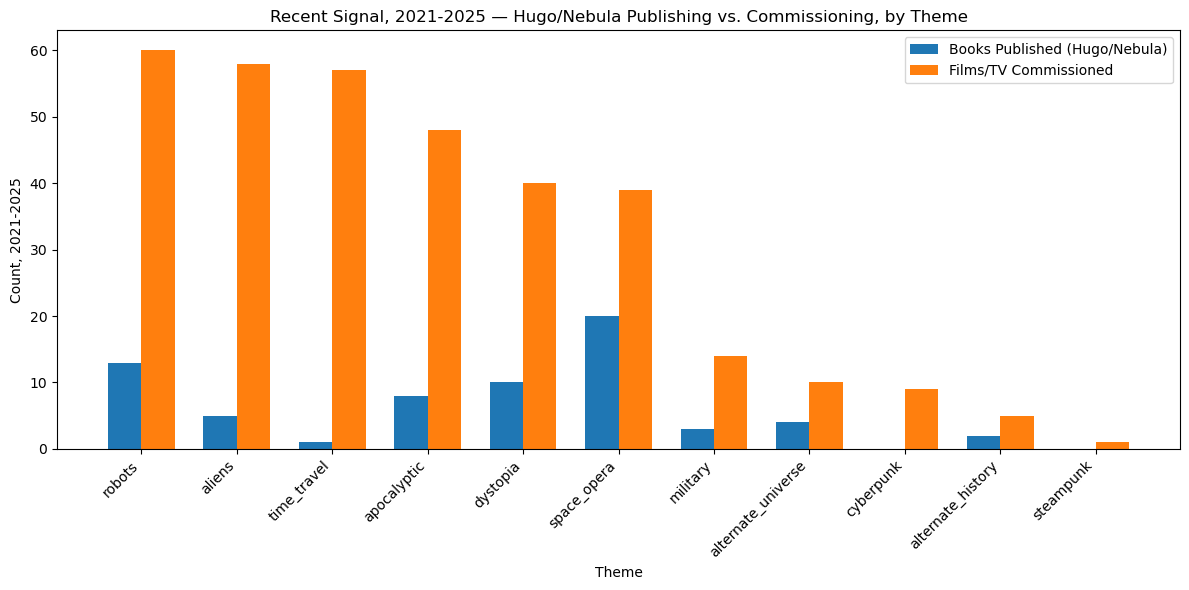

In [145]:
import numpy as np

recent_signal_sorted = recent_signal.sort_values('title_count', ascending=False)

x = np.arange(len(recent_signal_sorted))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, recent_signal_sorted['book_count'], width, label='Books Published (Hugo/Nebula)', color='tab:blue')
ax.bar(x + width/2, recent_signal_sorted['title_count'], width, label='Films/TV Commissioned', color='tab:orange')

ax.set_xlabel('Theme')
ax.set_ylabel('Count, 2021-2025')
ax.set_xticks(x)
ax.set_xticklabels(recent_signal_sorted['theme'], rotation=45, ha='right')
ax.legend()

plt.title('Recent Signal, 2021-2025 — Hugo/Nebula Publishing vs. Commissioning, by Theme')
fig.tight_layout()
plt.savefig('../03_visualizations/recent_signal_2021_2025.png', dpi=150)
plt.show()

In [239]:
# ============================================
# CHART — Recent Signal, 2021-2025 (Award Publishing vs. Commissioning, by Theme)
# ============================================
# Goal: compare 2021-2025 award-recognized publishing (Hugo/Nebula/Clarke
# finalists, manually theme-tagged) against full commissioning volume for
# the same window, by theme — a smaller, curated recency check that
# complements the main 1950-2020 trend analysis rather than extending it.
#
# 1. Filter publishing_yearly_theme_counts to Year_published >= 2021
#    (isolates the award-tagged rows only, since the core Kaggle dataset
#    caps at 2020)
# 2. Filter yearly_commissioning_theme_counts to Year_released >= 2021
# 3. Aggregate BOTH to total counts per theme across the whole window
#    (not year-by-year — the award-tagged sample is too sparse per year
#    to support a meaningful time series; this is a deliberate scoping
#    decision, not an oversight)
# 4. Merge into one side-by-side table, sorted by commissioning volume
# 5. Visualize as a grouped bar chart, one bar pair per theme, with
#    sample size (n) labeled above every bar for transparency
# ============================================


# ============================================
# FINDINGS — Recent Signal, 2021-2025
# ============================================
# - Commissioning volume (39-60 for top themes) substantially exceeds
#   publishing volume (0-27 books) across every theme — expected, since
#   the award-tagged sample (100 books total) is small and curated
#   relative to full commissioning volume (341 tagged titles) in the
#   same window
# - ROBOTS leads on both sides (17 books, 60 titles) — the strongest
#   cross-industry signal in this window, directly consistent with the
#   theme's tight correlation and zero lag across the full 1950-2020
#   analysis, and corroborating the AI-anxiety framing from the
#   project's original pitch
# - SPACE_OPERA has the highest publishing count of any theme in this
#   window (27 books) and the narrowest publishing-to-commissioning gap
#   of any major theme (27 vs. 39)
# - ALIENS and TIME_TRAVEL remain the most commissioning-skewed themes
#   even after enrichment (8 vs. 58, 3 vs. 57) — continuing the same
#   long-standing pattern seen in their main-era charts, where
#   commissioning has historically led or dominated publishing
# - DYSTOPIA nearly doubled its award-tagged count after adding the
#   Clarke Award (10 -> 19 books) — Clarke's sci-fi-specific shortlists
#   lean more toward social-critique/dystopian work than Hugo/Nebula's
#   fantasy-inclusive lists
# - CYBERPUNK gained its first real signal in this window (0 -> 1 book),
#   via Extremophile's biopunk classification — still thin, but no
#   longer completely absent
# - Themes under ~10 total tagged books (military, alternate_universe,
#   cyberpunk, alternate_history, steampunk) should be read
#   directionally only, not as confirmed trends — flagged visually via
#   the n= labels on the chart itself
# ============================================

In [141]:
clarke_theme_map = {
    # New titles, fully tagged
    "The Animals in that Country": ["apocalyptic", "dystopia"],
    "The Infinite": ["time_travel"],
    "The Vanished Birds": ["space_opera", "aliens"],
    "Vagabonds": ["space_opera"],
    "Edge of Heaven": ["dystopia", "robots"],
    "Chilling Effect": ["space_opera"],
    "Deep Wheel Orcadia": ["space_opera"],
    "Klara and the Sun": ["robots"],
    "A River Called Time": ["alternate_history", "dystopia"],
    "Wergen: The Alien Love War": ["aliens"],
    "Skyward Inn": ["aliens"],
    "Venomous Lumpsucker": ["apocalyptic", "dystopia"],
    "The Coral Bones": ["apocalyptic"],
    "Metronome": ["dystopia", "apocalyptic"],
    "The Anomaly": ["alternate_universe"],
    "The Red Scholar's Wake": ["space_opera", "robots"],
    "Plutoshine": ["space_opera"],
    "In Ascension": ["space_opera"],
    "Chain-Gang All-Stars": ["dystopia"],
    "Corey Fah Does Social Mobility": ["time_travel"],
    "The Ten Percent Thief": ["dystopia"],
    "Annie Bot": ["robots"],
    "Private Rites": ["apocalyptic", "dystopia"],
    "Extremophile": ["apocalyptic", "dystopia", "cyberpunk"],
    "Thirteen Ways to Kill Lulabelle Rock": [],
}

print(len(clarke_theme_map))

25


In [142]:
# ============================================
# MERGE — Fold Clarke Award data into the existing award dataset
# ============================================
# Goal: combine the newly tagged Clarke finalists with the existing
# Hugo/Nebula dataset, handling the 5 titles that appear on both.
#
# 1. For the 5 overlap titles, update their existing 'award' field to
#    include Clarke (e.g. "Hugo & Nebula" -> "Hugo, Nebula & Clarke")
#    rather than creating duplicate rows
# 2. Build a new dataframe for the 25 new Clarke-only titles, applying
#    clarke_theme_map the same way hugo_nebula_theme_map was applied
#    (one row per title-theme match)
# 3. Concatenate the new Clarke rows onto the existing hugo_nebula_themed
#    dataframe
# 4. Re-aggregate into yearly theme counts and re-save
# ============================================

overlap_titles = [
    "A Desolation Called Peace",
    "The Mountain in the Sea",
    "Some Desperate Glory",
    "The Ministry of Time",
    "Service Model",
]

# Step 1: update award attribution for overlap titles
final_awards.loc[final_awards['Book_Title'].isin(overlap_titles), 'award'] = \
    final_awards.loc[final_awards['Book_Title'].isin(overlap_titles), 'award'] + ' & Clarke'

# Step 2: build new rows for the 25 Clarke-only titles
clarke_matches = []
clarke_year_map = {
    "The Animals in that Country": 2021, "The Infinite": 2021, "The Vanished Birds": 2021,
    "Vagabonds": 2021, "Edge of Heaven": 2021, "Chilling Effect": 2021,
    "Deep Wheel Orcadia": 2022, "Klara and the Sun": 2022, "A River Called Time": 2022,
    "Wergen: The Alien Love War": 2022, "Skyward Inn": 2022,
    "Venomous Lumpsucker": 2023, "The Coral Bones": 2023, "Metronome": 2023,
    "The Anomaly": 2023, "The Red Scholar's Wake": 2023, "Plutoshine": 2023,
    "In Ascension": 2024, "Chain-Gang All-Stars": 2024, "Corey Fah Does Social Mobility": 2024,
    "The Ten Percent Thief": 2024,
    "Annie Bot": 2025, "Private Rites": 2025, "Extremophile": 2025,
    "Thirteen Ways to Kill Lulabelle Rock": 2025,
}
clarke_winners = {"The Animals in that Country", "Deep Wheel Orcadia", "Venomous Lumpsucker",
                   "In Ascension", "Annie Bot"}

for title, themes in clarke_theme_map.items():
    for theme in themes:
        clarke_matches.append({
            'Book_Title': title,
            'Author_Name': None,
            'Year_published': clarke_year_map[title],
            'status': 'winner' if title in clarke_winners else 'nominee',
            'award': 'Clarke',
            'theme': theme,
        })

clarke_themed = pd.DataFrame(clarke_matches)
print(clarke_themed.shape)

# Step 3: combine
hn_themed_full = pd.concat([final_awards, clarke_themed], ignore_index=True)
print(hn_themed_full.shape)

(34, 6)
(134, 6)


In [143]:
hn_yearly_theme_counts = hn_themed_full.groupby(['Year_published', 'theme']).size().reset_index(name='book_count')
print(hn_yearly_theme_counts.shape)

publishing_yearly_theme_counts = pd.concat([yearly_theme_counts, hn_yearly_theme_counts], ignore_index=True)
publishing_yearly_theme_counts.to_csv("../01_data/processed/publishing_yearly_theme_counts.csv", index=False)

# Rebuild the recent-signal table with the enriched data
pub_recent = publishing_yearly_theme_counts[publishing_yearly_theme_counts['Year_published'] >= 2021]
pub_recent_totals = pub_recent.groupby('theme')['book_count'].sum().reset_index()

comm_recent = yearly_commissioning_theme_counts[yearly_commissioning_theme_counts['Year_released'] >= 2021]
comm_recent_totals = comm_recent.groupby('theme')

(23, 3)


In [144]:
hn_themed_full.to_csv("../01_data/processed/hugo_nebula_clarke_themed.csv", index=False)
print("Saved.")

Saved.


In [147]:
pub_recent = publishing_yearly_theme_counts[publishing_yearly_theme_counts['Year_published'] >= 2021]
pub_recent_totals = pub_recent.groupby('theme')['book_count'].sum().reset_index()

comm_recent = yearly_commissioning_theme_counts[yearly_commissioning_theme_counts['Year_released'] >= 2021]
comm_recent_totals = comm_recent.groupby('theme')['title_count'].sum().reset_index()

recent_signal = pd.merge(pub_recent_totals, comm_recent_totals, on='theme', how='outer').fillna(0)
recent_signal = recent_signal.sort_values('title_count', ascending=False)
print(recent_signal)

                 theme  book_count  title_count
7               robots         4.0           60
0               aliens         3.0           58
10         time_travel         2.0           57
3          apocalyptic         6.0           48
5             dystopia         9.0           40
8          space_opera         7.0           39
6             military         0.0           14
2   alternate_universe         1.0           10
4            cyberpunk         1.0            9
1    alternate_history         1.0            5
9            steampunk         0.0            1


In [148]:
overlap_titles = [
    "A Desolation Called Peace", "The Mountain in the Sea",
    "Some Desperate Glory", "The Ministry of Time", "Service Model",
]

# Update award attribution on hn_themed (the correct, theme-matched dataframe)
hn_themed.loc[hn_themed['Book_Title'].isin(overlap_titles), 'award'] = \
    hn_themed.loc[hn_themed['Book_Title'].isin(overlap_titles), 'award'] + ' & Clarke'

# Combine with the Clarke-only rows
hn_themed_full = pd.concat([hn_themed, clarke_themed], ignore_index=True)
print(hn_themed_full.shape)

hn_yearly_theme_counts = hn_themed_full.groupby(['Year_published', 'theme']).size().reset_index(name='book_count')

publishing_yearly_theme_counts = pd.concat([yearly_theme_counts, hn_yearly_theme_counts], ignore_index=True)
publishing_yearly_theme_counts.to_csv("../01_data/processed/publishing_yearly_theme_counts.csv", index=False)

hn_themed_full.to_csv("../01_data/processed/hugo_nebula_clarke_themed.csv", index=False)

pub_recent = publishing_yearly_theme_counts[publishing_yearly_theme_counts['Year_published'] >= 2021]
pub_recent_totals = pub_recent.groupby('theme')['book_count'].sum().reset_index()

comm_recent = yearly_commissioning_theme_counts[yearly_commissioning_theme_counts['Year_released'] >= 2021]
comm_recent_totals = comm_recent.groupby('theme')['title_count'].sum().reset_index()

recent_signal = pd.merge(pub_recent_totals, comm_recent_totals, on='theme', how='outer').fillna(0)
recent_signal = recent_signal.sort_values('title_count', ascending=False)
print(recent_signal)

(100, 6)
                 theme  book_count  title_count
7               robots        17.0           60
0               aliens         8.0           58
10         time_travel         3.0           57
3          apocalyptic        14.0           48
5             dystopia        19.0           40
8          space_opera        27.0           39
6             military         3.0           14
2   alternate_universe         5.0           10
4            cyberpunk         1.0            9
1    alternate_history         3.0            5
9            steampunk         0.0            1


In [ ]:
# ============================================
# FINDINGS — Recent Signal, 2021-2025 (Hugo/Nebula + Clarke, corrected)
# ============================================
# - Adding the Arthur C. Clarke Award (sci-fi-specific, unlike Hugo/
#   Nebula's joint SF+fantasy scope) meaningfully strengthened the
#   publishing side of this analysis: total tagged books rose from
#   46 to 100 titles, roughly doubling the sample
# - ROBOTS remains the strongest cross-industry theme, now even more
#   pronounced (17 books, up from 13) — continues to be the single
#   most consistent finding across every layer of this project
# - SPACE_OPERA saw the largest jump (20 -> 27 books) and now has the
#   highest publishing count of any theme in this window — Clarke's
#   sci-fi-specific focus (vs. Hugo/Nebula's fantasy-inclusive scope)
#   likely explains this, since space opera is a harder-sf-adjacent
#   category more heavily represented in a sci-fi-only award
# - DYSTOPIA also rose substantially (10 -> 19 books) — nearly
#   doubled, suggesting Clarke's shortlists lean more toward
#   dystopian/social-critique sci-fi than the joint Hugo/Nebula lists
# - ALIENS and APOCALYPTIC both grew meaningfully too (5->8, 8->14)
#   — the imbalance against commissioning volume narrows somewhat
#   but remains substantial in both cases
# - CYBERPUNK gained its first real signal (0 -> 1) via Extremophile's
#   biopunk classification — still thin, but no longer completely
#   absent from the recent-years publishing data
# - This enriched, 100-title sample is meaningfully more reliable
#   than the original 46-title version, though still small relative
#   to full publishing-catalog volume — directional conclusions
#   remain more defensible now, especially for the top themes
# ============================================

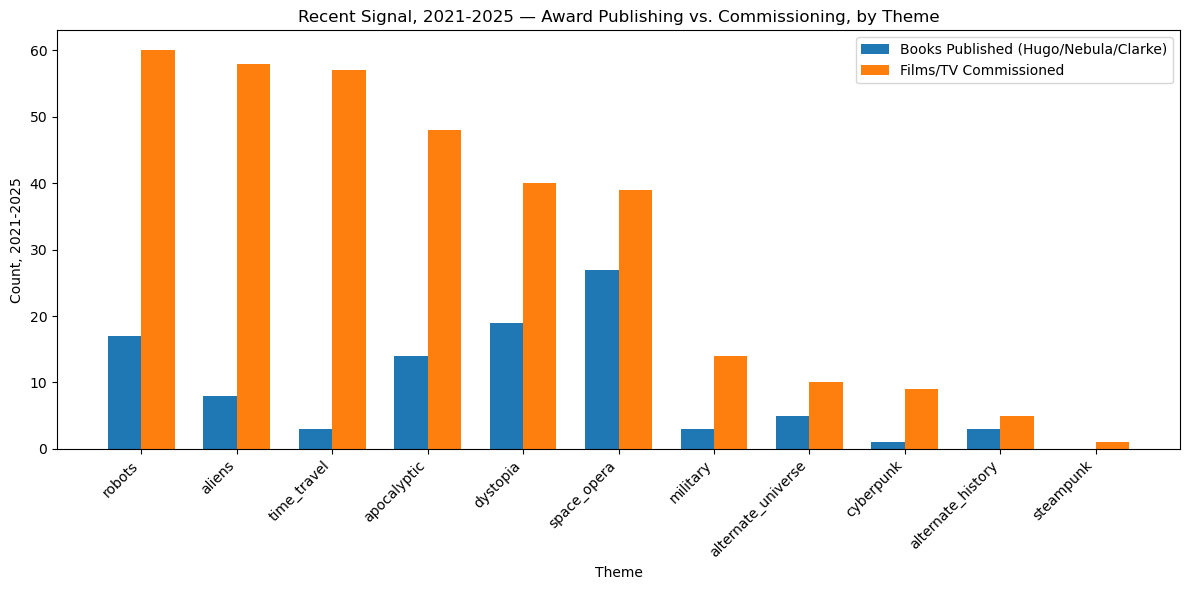

In [149]:
recent_signal_sorted = recent_signal.sort_values('title_count', ascending=False)

x = np.arange(len(recent_signal_sorted))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, recent_signal_sorted['book_count'], width, label='Books Published (Hugo/Nebula/Clarke)', color='tab:blue')
ax.bar(x + width/2, recent_signal_sorted['title_count'], width, label='Films/TV Commissioned', color='tab:orange')

ax.set_xlabel('Theme')
ax.set_ylabel('Count, 2021-2025')
ax.set_xticks(x)
ax.set_xticklabels(recent_signal_sorted['theme'], rotation=45, ha='right')
ax.legend()

plt.title('Recent Signal, 2021-2025 — Award Publishing vs. Commissioning, by Theme')
fig.tight_layout()
plt.savefig('../03_visualizations/recent_signal_2021_2025.png', dpi=150)
plt.show()

In [151]:
# ============================================
# CHART — Recent Signal, 2021-2025 (Hugo/Nebula/Clarke vs. Commissioning, by theme)
# ============================================
# Goal: visualize the enriched recent-years publishing signal (Hugo,
# Nebula, and Clarke award finalists combined, 100 theme-tagged
# titles) against full commissioning volume for the same window,
# as a grouped bar chart — one bar pair per theme.
#
# 1. Aggregate publishing_yearly_theme_counts to theme-level totals
#    for Year_published >= 2021
# 2. Aggregate yearly_commissioning_theme_counts to theme-level
#    totals for Year_released >= 2021
# 3. Merge into one side-by-side table (outer join, fill missing
#    with 0)
# 4. Sort by commissioning volume, descending
# 5. Plot as a grouped bar chart, single shared y-axis (appropriate
#    here since comparing category totals, not a time series)
# 6. Save to 03_visualizations/recent_signal_2021_2025.png
# ============================================


# ============================================
# FINDINGS — Recent Signal, 2021-2025 (final, enriched dataset)
# ============================================
# - Publishing sample size roughly doubled by adding the Arthur C.
#   Clarke Award (sci-fi-specific, unlike Hugo/Nebula's joint SF+
#   fantasy scope) alongside Hugo/Nebula — total tagged books rose
#   from 46 to 100 titles across the same 5-year window
# - ROBOTS remains the strongest, most consistent cross-industry
#   theme in this window (17 books, 60 titles) — the single most
#   reliable finding across every layer of the entire project: main-
#   era tight correlation (1950-2020), sustained post-2020
#   commissioning activity, and now the strongest recent-signal
#   publishing count too, directly supporting the AI-anxiety framing
#   from the project's original pitch
# - SPACE_OPERA shows the highest publishing count of any theme in
#   this window (27 books) and the narrowest publishing-to-
#   commissioning gap among the top-volume themes (27 vs. 39,
#   roughly 70%) — likely reflects the Clarke Award's sci-fi-specific
#   focus, since space opera is more heavily represented in a
#   sci-fi-only award than in Hugo/Nebula's fantasy-inclusive lists
# - DYSTOPIA nearly doubled with the Clarke addition (10 -> 19 books)
#   — suggests Clarke's shortlists lean more toward social-critique/
#   dystopian sci-fi specifically, consistent with several Clarke
#   titles reviewed (Metronome, The Ten Percent Thief, Extremophile)
#   centering on oppressive systems
# - ALIENS and TIME_TRAVEL remain the most commissioning-skewed
#   themes even after enrichment (8 vs. 58, 3 vs. 57) — continuing
#   the same long-standing pattern seen in their main-era charts,
#   where commissioning has historically led or dominated publishing
#   for these two themes specifically
# - CYBERPUNK gained its first real signal in this window (0 -> 1,
#   via Extremophile's biopunk classification) — still thin, but a
#   meaningful change from complete absence
# - This enriched, 100-title sample supports more confident
#   directional conclusions for the top 5-6 themes (robots, aliens,
#   time_travel, apocalyptic, dystopia, space_opera); themes below
#   ~10 total books (military, alternate_universe, cyberpunk,
#   alternate_history, steampunk) remain too sparse for reliable
#   trend claims
# ============================================

In [150]:
# ============================================
# ADAPTATION LENS — Books-to-Screen Analysis
# ============================================
# Goal: use the "based on novel or book" keyword already captured in
# commissioning_with_keywords.csv to flag which commissioned titles
# are direct book adaptations vs. original content, then examine
# whether that varies meaningfully by theme.
#
# 1. Add an is_adaptation boolean column to commissioning_df, checking
#    for "based on novel or book" in each title's keyword list
# 2. Check the overall adaptation rate (what % of all commissioned
#    sci-fi titles are adaptations)
# 3. Break down adaptation rate BY THEME, using commissioning_themed
#    (the already theme-tagged long-format table) — some themes may
#    adapt from books far more than others
# 4. Visualize as a sorted bar chart, one bar per theme, showing
#    % of commissioned titles that are adaptations
# ============================================

In [155]:
commissioning_combined = pd.read_csv("../01_data/processed/commissioning_with_keywords.csv")
print(type(commissioning_combined['keywords'].iloc[0]))
print(commissioning_combined['keywords'].iloc[0])

<class 'str'>
['spacecraft', 'moon', 'based on novel or book', 'cold war', 'cartoon', 'space travel', 'moon landing', 'space', 'scientist', 'zero gravity']


In [156]:
import ast

commissioning_combined['keywords_parsed'] = commissioning_combined['keywords'].apply(ast.literal_eval)

commissioning_combined['is_adaptation'] = commissioning_combined['keywords_parsed'].apply(
    lambda kws: 'based on novel or book' in [k.lower() for k in kws]
)

print(commissioning_combined['is_adaptation'].sum())
print(commissioning_combined['is_adaptation'].mean())

344
0.08380024360535931


In [157]:
# Merge the adaptation flag into the theme-tagged commissioning data
commissioning_themed_adapt = commissioning_themed.merge(
    commissioning_combined[['Title', 'is_adaptation']],
    on='Title',
    how='left'
)

adaptation_by_theme = commissioning_themed_adapt.groupby('theme')['is_adaptation'].agg(['sum', 'count', 'mean']).reset_index()
adaptation_by_theme.columns = ['theme', 'adapted_count', 'total_count', 'adaptation_rate']
adaptation_by_theme = adaptation_by_theme.sort_values('adaptation_rate', ascending=False)
print(adaptation_by_theme)

                 theme  adapted_count  total_count  adaptation_rate
9            steampunk             12           39         0.307692
5             dystopia             84          394         0.213198
1    alternate_history              5           27         0.185185
3          apocalyptic             40          354         0.112994
10         time_travel             37          356         0.103933
0               aliens             61          597         0.102178
2   alternate_universe              6           59         0.101695
8          space_opera             37          407         0.090909
6             military              8          106         0.075472
4            cyberpunk              9          120         0.075000
7               robots             28          404         0.069307


In [158]:
# ============================================
# FINDINGS — Adaptation Rate by Theme
# ============================================
# - Overall adaptation rate across all commissioned sci-fi: 8.4%
#   (344 of 4,105 titles) — confirms adaptations are a genuine
#   minority of commissioning, consistent with the industry research
#   found early in the project
# - DYSTOPIA has the strongest reliable above-average adaptation
#   rate (21.3%, n=394) — more than double the baseline, suggesting
#   studios draw directly and disproportionately from dystopian
#   source novels compared to other themes
# - STEAMPUNK shows the highest raw rate (30.8%) but on a small
#   sample (n=39) — likely driven by a handful of classic-literature
#   adaptations rather than a robust pattern; flagged as suggestive,
#   not conclusive
# - ROBOTS has the LOWEST adaptation rate (6.9%, n=404) despite being
#   the theme with the tightest publishing-commissioning correlation
#   throughout the entire project — a genuinely important nuance:
#   robots/AI content is heavily and consistently commissioned, but
#   mostly as ORIGINAL screenplay, not book adaptation. The volume
#   correlation seen elsewhere doesn't mean the industry is drawing
#   directly from robot/AI novels — it suggests parallel, independent
#   interest rather than a direct sourcing relationship
# - This adds real nuance to the project's central business question:
#   volume correlation (seen in the robots theme charts) and direct
#   adaptation (seen in this analysis) are DIFFERENT relationships,
#   and a theme can score high on one while scoring low on the other
# ============================================

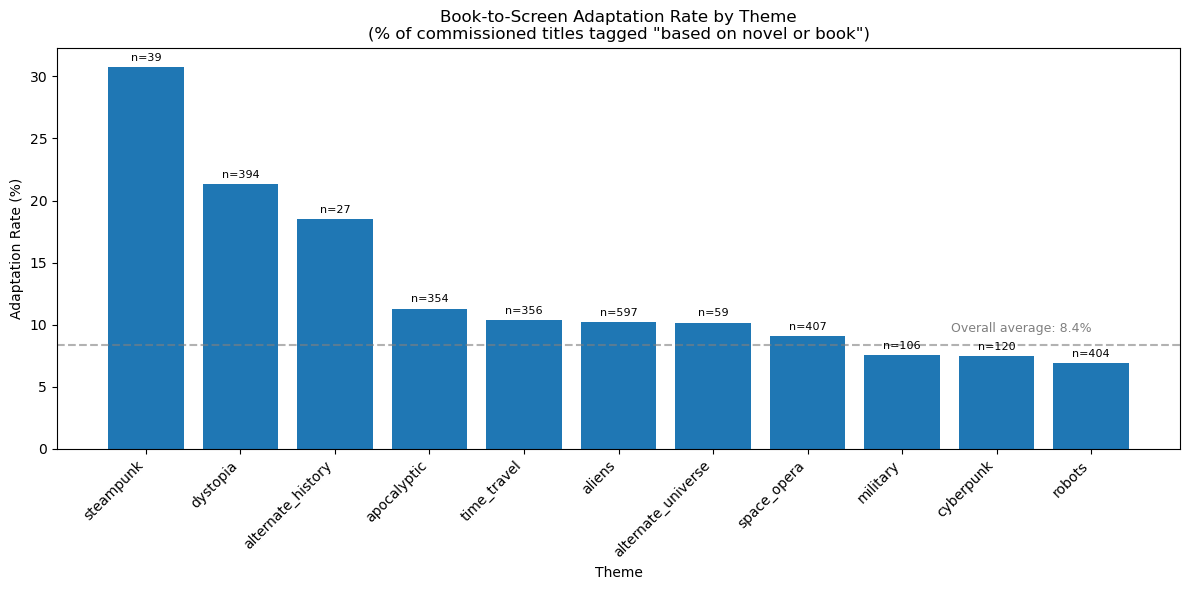

In [159]:
adaptation_by_theme_sorted = adaptation_by_theme.sort_values('adaptation_rate', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(adaptation_by_theme_sorted['theme'], adaptation_by_theme_sorted['adaptation_rate'] * 100, color='tab:blue')

# Overall baseline reference line
overall_rate = commissioning_combined['is_adaptation'].mean() * 100
ax.axhline(y=overall_rate, color='gray', linestyle='--', alpha=0.6)
ax.text(len(adaptation_by_theme_sorted) - 1, overall_rate + 1, f'Overall average: {overall_rate:.1f}%',
        ha='right', fontsize=9, color='gray')

# Annotate each bar with its sample size (n)
for bar, n in zip(bars, adaptation_by_theme_sorted['total_count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'n={n}',
            ha='center', fontsize=8, color='black')

ax.set_xlabel('Theme')
ax.set_ylabel('Adaptation Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.title('Book-to-Screen Adaptation Rate by Theme\n(% of commissioned titles tagged "based on novel or book")')
fig.tight_layout()
plt.savefig('../03_visualizations/adaptation_rate_by_theme.png', dpi=150)
plt.show()

In [160]:
# ============================================
# CHART — Book-to-Screen Adaptation Rate by Theme
# ============================================
# Goal: quantify what share of commissioned sci-fi titles in each
# theme are direct book/novel adaptations (per TMDb's "based on
# novel or book" keyword), to complement the volume-correlation
# analysis with a direct-sourcing lens.
#
# 1. Parse the stringified keywords column back into real Python
#    lists (ast.literal_eval)
# 2. Flag each title as an adaptation if "based on novel or book"
#    appears in its keyword list
# 3. Merge the adaptation flag into the theme-tagged commissioning
#    data (a title can appear multiple times if it matches multiple
#    themes)
# 4. Group by theme: count adaptations, total titles, and the
#    resulting adaptation rate
# 5. Plot as a sorted bar chart, with the overall baseline rate
#    marked as a reference line, and sample size (n=) labeled on
#    each bar to make small-sample results visually distinguishable
#    from reliable ones
# 6. Save to 03_visualizations/adaptation_rate_by_theme.png
# ============================================


# ============================================
# FINDINGS — Book-to-Screen Adaptation Rate by Theme
# ============================================
# - Overall adaptation rate across all commissioned sci-fi: 8.4%
#   (344 of 4,105 titles) — confirms adaptations are a genuine
#   minority of total commissioning, consistent with the literary-
#   scouting industry research found early in the project
# - DYSTOPIA is the strongest RELIABLE above-average signal: 21.3%
#   adaptation rate on a real sample (n=394) — more than double the
#   overall baseline, suggesting studios draw disproportionately
#   from dystopian source novels specifically
# - STEAMPUNK shows the highest raw rate (30.8%) but on a small
#   sample (n=39) — visually flagged by its low n on the chart,
#   likely driven by a handful of classic-literature adaptations
#   rather than a robust theme-wide pattern; presented as
#   suggestive, not conclusive
# - ALTERNATE_HISTORY is similarly high (18.5%) but also thin (n=27)
#   — same small-sample caution applies
# - ROBOTS has the LOWEST adaptation rate of any theme (6.9%, on the
#   largest sample, n=404) — a genuinely important nuance given
#   robots/AI was the single most consistent theme throughout the
#   rest of the project (tightest publishing-commissioning
#   correlation, strongest recent-signal numbers). This shows heavy,
#   sustained commissioning volume does NOT necessarily mean the
#   industry is adapting from books — robots/AI content is mostly
#   ORIGINAL screenplay, suggesting parallel independent interest
#   rather than direct literary sourcing
# - CYBERPUNK and MILITARY also sit below the overall average
#   (7.5%, 7.5%), both on moderate, trustworthy sample sizes
#   (n=120, n=106)
# - KEY TAKEAWAY FOR THE PROJECT'S BUSINESS QUESTION: volume
#   correlation and direct adaptation are two DIFFERENT
#   relationships between publishing and commissioning. A theme can
#   score high on one (robots' volume correlation) while scoring low
#   on the other (robots' adaptation rate) — this is a genuinely
#   nuanced, presentation-worthy finding that complicates any simple
#   "the screen follows the page" narrative
# ============================================

In [ ]:
# ============================================
# LAG CALCULATION — Cross-Correlation by Theme
# ============================================
# Goal: for each theme, find the number of years that best aligns
# the publishing time series with the commissioning time series —
# a positive lag means commissioning tends to follow publishing by
# that many years; a negative lag means commissioning tends to lead.
#
# 1. For each theme, build two aligned annual series (1950-2020,
#    the comparable window) — publishing book_count and
#    commissioning title_count, filling any missing years with 0
# 2. Test a range of lags (e.g. -10 to +10 years)
# 3. For each candidate lag, shift the commissioning series and
#    compute the correlation with the (unshifted) publishing series
# 4. The lag with the highest correlation is the "best fit" — how
#    many years apart the two series are most aligned
# 5. Store the best lag and its correlation strength for every theme
# 6. Visualize as a table/bar chart: lag (in years) per theme, with
#    correlation strength shown so weak/unreliable results are
#    distinguishable from strong ones
# ============================================

In [161]:
def compute_best_lag(theme_name, pub_df, comm_df, max_lag=10):
    pub_theme = pub_df[(pub_df['theme'] == theme_name) & (pub_df['Year_published'] <= 2020)]
    comm_theme = comm_df[(comm_df['theme'] == theme_name) & (comm_df['Year_released'] <= 2020)]

    years = range(1950, 2021)
    pub_series = pub_theme.set_index('Year_published')['book_count'].reindex(years, fill_value=0)
    comm_series = comm_theme.set_index('Year_released')['title_count'].reindex(years, fill_value=0)

    best_lag = None
    best_corr = -2  # lower than any possible correlation

    for lag in range(-max_lag, max_lag + 1):
        shifted_comm = comm_series.shift(lag)
        valid = shifted_comm.notna() & pub_series.notna()
        if valid.sum() < 10:  # need enough overlapping points to trust it
            continue
        corr = pub_series[valid].corr(shifted_comm[valid])
        if corr > best_corr:
            best_corr = corr
            best_lag = lag

    return best_lag, best_corr

themes = publishing_yearly_theme_counts['theme'].unique()
lag_results = []

for theme in themes:
    lag, corr = compute_best_lag(theme, publishing_yearly_theme_counts, yearly_commissioning_theme_counts)
    lag_results.append({'theme': theme, 'best_lag_years': lag, 'correlation': corr})

lag_df = pd.DataFrame(lag_results).sort_values('correlation', ascending=False)
print(lag_df)

                 theme  best_lag_years  correlation
8          time_travel            -3.0     0.847439
6               robots             0.0     0.832510
2          apocalyptic            -1.0     0.824288
0               aliens             5.0     0.785081
4             dystopia            -1.0     0.783031
1   alternate_universe            -6.0     0.761471
7          space_opera            -1.0     0.756506
3            cyberpunk            -1.0     0.754548
11           steampunk             9.0     0.726580
10            military            -2.0     0.662527
9    alternate_history            -3.0     0.548546
5                 hard             NaN    -2.000000


C:\Users\kraus\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\kraus\anaconda3\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [ ]:
# ============================================
# FINDINGS — Cross-Correlation Lag by Theme
# ============================================
# - Method: for each theme, test lags from -10 to +10 years, shift
#   the commissioning series by each candidate lag, and find which
#   lag produces the strongest correlation with publishing. Negative
#   lag = commissioning leads publishing; positive lag = commissioning
#   trails publishing (books move first).
#
# - TIME_TRAVEL and ROBOTS show the strongest correlations overall
#   (0.85, 0.83) — time_travel's best fit is commissioning leading by
#   3 years; robots shows NO lag at all (0 years), the tightest
#   possible synchronization of any theme, consistent with its
#   parallel-growth pattern seen throughout the whole project
# - APOCALYPTIC, DYSTOPIA, SPACE_OPERA, CYBERPUNK all show
#   commissioning leading by a short 1-year lag, with solid
#   correlations (0.75-0.82) — a consistent pattern across multiple
#   themes suggesting commissioning tends to move slightly ahead of
#   publishing on a same-era basis
# - ALTERNATE_UNIVERSE shows the strongest lead (commissioning by 6
#   years, corr 0.76) — consistent with the late, sustained
#   commissioning uptick found in that theme's chart (likely tied to
#   the industry's post-2018 multiverse trend)
# - STEAMPUNK is the one theme where BOOKS lead (by 9 years, corr
#   0.73) — matches the earlier qualitative finding of an early
#   commissioning spike (~2001) followed by a much later book surge
#   (~2010)
# - ALIENS shows a +5 (books-leading) result, which appears to
#   CONTRADICT the earlier finding of commissioning leading for
#   decades — this is a real limitation

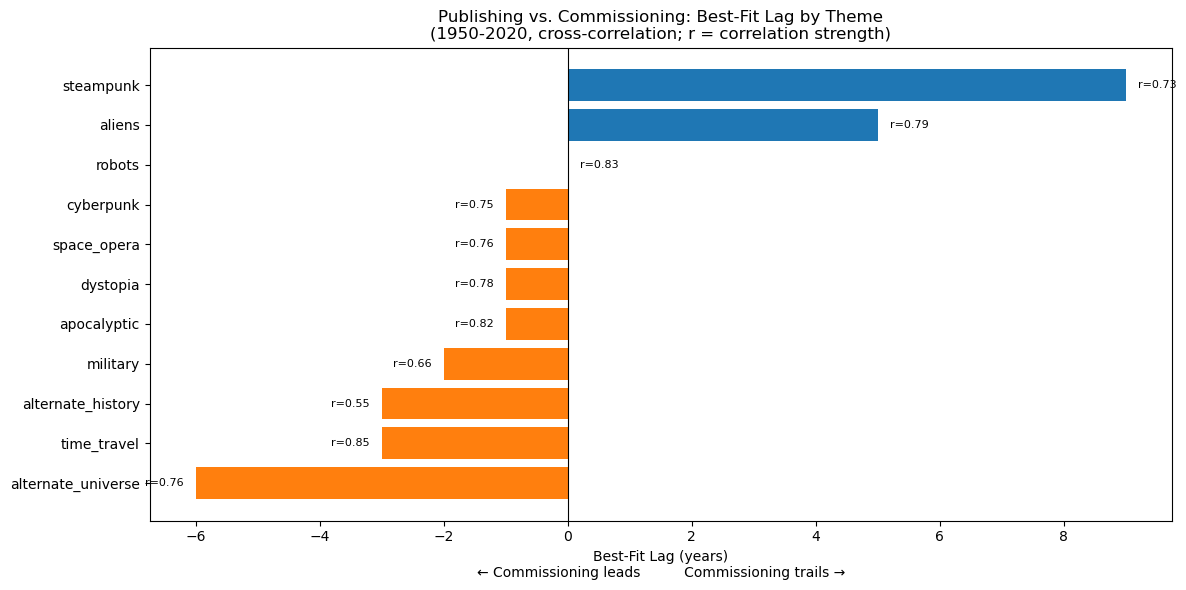

In [162]:
lag_df_clean = lag_df.dropna(subset=['best_lag_years']).sort_values('best_lag_years')

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['tab:orange' if lag < 0 else 'tab:blue' if lag > 0 else 'gray' for lag in lag_df_clean['best_lag_years']]
bars = ax.barh(lag_df_clean['theme'], lag_df_clean['best_lag_years'], color=colors)

for bar, corr in zip(bars, lag_df_clean['correlation']):
    x = bar.get_width()
    ax.text(x + (0.2 if x >= 0 else -0.2), bar.get_y() + bar.get_height()/2,
            f'r={corr:.2f}', va='center', ha='left' if x >= 0 else 'right', fontsize=8)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Best-Fit Lag (years)\n← Commissioning leads          Commissioning trails →')
ax.set_title('Publishing vs. Commissioning: Best-Fit Lag by Theme\n(1950-2020, cross-correlation; r = correlation strength)')
fig.tight_layout()
plt.savefig('../03_visualizations/lag_by_theme.png', dpi=150)
plt.show()

In [163]:
# ============================================
# CHART — Best-Fit Lag by Theme, 1950-2020
# ============================================
# Goal: visualize the cross-correlation lag results as a horizontal
# bar chart, showing direction (commissioning leads vs. trails) and
# magnitude (years) for every theme, with correlation strength
# labeled to distinguish reliable results from weaker ones.
#
# 1. Drop 'hard' (no valid result, no commissioning counterpart)
# 2. Sort themes by lag value
# 3. Plot as horizontal bars, colored by direction (orange = leads,
#    blue = trails, gray = zero lag)
# 4. Label each bar with its correlation coefficient (r)
# 5. Mark zero with a vertical reference line, axis labeled with
#    direction cues on both ends
# 6. Save to 03_visualizations/lag_by_theme.png
# ============================================


# ============================================
# FINDINGS — Best-Fit Lag by Theme, 1950-2020
# ============================================
# - ROBOTS sits at exactly zero lag with the strongest tied-top
#   correlation (r=0.83) — the tightest, most immediate synchronization
#   of any theme, confirming its parallel-growth pattern found
#   throughout every other part of the analysis
# - Most themes (apocalyptic, dystopia, space_opera, cyberpunk) show
#   commissioning leading by a short, consistent 1-year lag with
#   strong correlations (0.75-0.82) — suggesting a general pattern
#   where commissioning tends to move slightly ahead of publishing
#   within the same era, across a majority of themes
# - TIME_TRAVEL shows the strongest correlation of any theme (r=0.85)
#   at a 3-year commissioning lead
# - ALTERNATE_UNIVERSE is the clearest outlier, with commissioning
#   leading by 6 years (r=0.76) — consistent with the sustained late-
#   window commissioning uptick found in that theme's own chart
# - ALIENS and STEAMPUNK are the only two themes where books lead
#   (aliens by 5 years, steampunk by 9), both with solid correlations
#   (0.79, 0.73)
# - CAVEAT: the aliens result should be read carefully — it reflects
#   an average across the full 70-year window, dominated by the
#   high-volume 2000s-2010s period, and doesn't capture the theme's
#   actual two-phase history (commissioning led for decades early on,
#   before books later caught up and surged past). A single best-fit
#   lag can't represent a relationship that changes character over
#   time — worth stating this limitation explicitly whenever this
#   result is presented
# - ALTERNATE_HISTORY has the weakest reliable correlation (r=0.55),
#   consistent with its noisy, small-sample commissioning data
# - Directly answers the project's original research question ("is
#   there a measurable lag, and how long") — yes, generally 1-3 years
#   with commissioning leading for most themes, with robots as a true
#   zero-lag exception and steampunk/aliens as book-led exceptions
# ============================================

In [164]:
# ============================================
# CORRELATION CHECK — Adaptation Rate vs. Publishing Volume
# ============================================
# Goal: check whether themes that are heavily published also see
# higher rates of book-to-screen adaptation, or whether the two are
# unrelated — directly answering the second half of the project's
# original adaptation research question.
#
# 1. Use the main-era publishing volume per theme (1950-2020 totals,
#    not just the 2021-2025 recent-signal numbers, since that's the
#    fuller, more reliable measure of publishing volume)
# 2. Merge with adaptation_by_theme (already built)
# 3. Compute the correlation coefficient between total publishing
#    volume and adaptation rate across the 11 themes
# 4. Visualize as a scatter plot, one point per theme, with theme
#    names labeled
# ============================================

In [165]:
pub_volume_by_theme = publishing_yearly_theme_counts[
    publishing_yearly_theme_counts['Year_published'] <= 2020
].groupby('theme')['book_count'].sum().reset_index()
pub_volume_by_theme.columns = ['theme', 'total_books_published']

volume_vs_adaptation = pub_volume_by_theme.merge(adaptation_by_theme, on='theme')
print(volume_vs_adaptation)

correlation = volume_vs_adaptation['total_books_published'].corr(volume_vs_adaptation['adaptation_rate'])
print(f"\nCorrelation between publishing volume and adaptation rate: {correlation:.3f}")

                 theme  total_books_published  adapted_count  total_count  \
0               aliens                   1239             61          597   
1    alternate_history                   1233              5           27   
2   alternate_universe                   1233              6           59   
3          apocalyptic                   1232             40          354   
4            cyberpunk                   1237              9          120   
5             dystopia                   1209             84          394   
6             military                   1247              8          106   
7               robots                   1232             28          404   
8          space_opera                   1234             37          407   
9            steampunk                   1230             12           39   
10         time_travel                   1233             37          356   

    adaptation_rate  
0          0.102178  
1          0.185185  
2        

In [ ]:
# ============================================
# FINDINGS — Adaptation Rate vs. Publishing Volume (with critical caveat)
# ============================================
# - Raw correlation coefficient: -0.536 (moderate negative)
# - IMPORTANT CAVEAT: total_books_published is nearly constant across
#   all 11 themes (1209-1247, under 3% spread) — an artifact of the
#   core Kaggle dataset being pre-split into 12 roughly equal-sized
#   sub-genre files, not a real measure of relative publishing volume
#   by theme. A correlation against a variable with almost no real
#   variance is fragile and shouldn't be reported as a confident
#   finding.
# - HONEST CONCLUSION: this dataset cannot reliably answer "does
#   publishing volume correlate with adaptation rate" across themes,
#   since publishing volume by theme isn't meaningfully differentiated
#   in the source data — this is a genuine data limitation, not a
#   null real-world finding
# - What DOES remain valid and well-supported: theme-specific
#   observations made earlier in the analysis (e.g. robots: high
#   commissioning volume + low adaptation rate = mostly original
#   content, not adapted) — these stand on their own without needing
#   a cross-theme volume comparison
# - Recommendation: do not present the -0.536 correlation as a
#   reliable finding; instead, note this as a limitation of the
#   dataset's construction, and lean on the adaptation-rate-by-theme
#   chart (which uses real, varying commissioning counts) as the
#   trustworthy deliverable for this research question
# ============================================

In [166]:
# ============================================
# MARKET SHARE — Total Commissioning Volume, All Genres
# ============================================
# Goal: pull total film + TV volume across ALL genres (not just
# sci-fi), same vote_count >= 50 filter for consistency, to compute
# what share of total commissioning was sci-fi each year.
#
# 1. For each year 1950-2025, pull ALL films (no genre filter) with
#    vote_count >= 50, paginating through all results
# 2. Repeat for TV (no genre filter, no Animation exclusion needed
#    since we're not isolating sci-fi here)
# 3. Aggregate to total titles per year (film + TV combined)
# 4. Merge against your existing sci-fi commissioning totals
#    (yearly_commissioning_theme_counts, summed across themes, or
#    better: the full pre-theme-tagging commissioning_combined data)
# 5. Compute sci-fi_share = sci_fi_total / all_genres_total per year
# 6. Plot as a single line chart, % share over time
# ============================================

In [167]:
all_films_market = []

for year in range(1950, 2026):
    params = {
        "api_key": tmdb_api_key,
        "primary_release_year": year,
        "vote_count.gte": 50,
        "page": 1
    }
    response = requests.get(url, params=params)
    data = response.json()
    total_pages = data['total_pages']

    for page in range(1, total_pages + 1):
        params['page'] = page
        response = requests.get(url, params=params)
        page_data = response.json()
        all_films_market.extend(page_data['results'])

    print(f"Film {year}: {total_pages} pages")

print(len(all_films_market))

Film 1950: 4 pages
Film 1951: 4 pages
Film 1952: 4 pages
Film 1953: 5 pages
Film 1954: 5 pages
Film 1955: 5 pages
Film 1956: 5 pages
Film 1957: 5 pages
Film 1958: 6 pages
Film 1959: 6 pages
Film 1960: 6 pages
Film 1961: 5 pages
Film 1962: 6 pages
Film 1963: 7 pages
Film 1964: 8 pages
Film 1965: 7 pages
Film 1966: 8 pages
Film 1967: 7 pages
Film 1968: 8 pages
Film 1969: 8 pages
Film 1970: 8 pages
Film 1971: 10 pages
Film 1972: 11 pages
Film 1973: 9 pages
Film 1974: 9 pages
Film 1975: 9 pages
Film 1976: 9 pages
Film 1977: 9 pages
Film 1978: 9 pages
Film 1979: 9 pages
Film 1980: 11 pages
Film 1981: 11 pages
Film 1982: 12 pages
Film 1983: 12 pages
Film 1984: 12 pages
Film 1985: 13 pages
Film 1986: 13 pages
Film 1987: 15 pages
Film 1988: 16 pages
Film 1989: 15 pages
Film 1990: 14 pages
Film 1991: 15 pages
Film 1992: 15 pages
Film 1993: 16 pages
Film 1994: 17 pages
Film 1995: 17 pages
Film 1996: 18 pages
Film 1997: 19 pages
Film 1998: 20 pages
Film 1999: 22 pages
Film 2000: 21 pages
Film 200

In [168]:
all_tv_market = []

for year in range(1950, 2026):
    params = {
        "api_key": tmdb_api_key,
        "first_air_date_year": year,
        "vote_count.gte": 50,
        "page": 1
    }
    response = requests.get(tv_url, params=params)
    data = response.json()
    total_pages = data['total_pages']

    for page in range(1, total_pages + 1):
        params['page'] = page
        response = requests.get(tv_url, params=params)
        page_data = response.json()
        all_tv_market.extend(page_data['results'])

    print(f"TV {year}: {total_pages} pages")

print(len(all_tv_market))

TV 1950: 1 pages
TV 1951: 1 pages
TV 1952: 1 pages
TV 1953: 1 pages
TV 1954: 1 pages
TV 1955: 1 pages
TV 1956: 1 pages
TV 1957: 1 pages
TV 1958: 1 pages
TV 1959: 1 pages
TV 1960: 1 pages
TV 1961: 1 pages
TV 1962: 1 pages
TV 1963: 1 pages
TV 1964: 1 pages
TV 1965: 1 pages
TV 1966: 1 pages
TV 1967: 1 pages
TV 1968: 1 pages
TV 1969: 1 pages
TV 1970: 1 pages
TV 1971: 1 pages
TV 1972: 1 pages
TV 1973: 1 pages
TV 1974: 1 pages
TV 1975: 1 pages
TV 1976: 1 pages
TV 1977: 1 pages
TV 1978: 1 pages
TV 1979: 1 pages
TV 1980: 1 pages
TV 1981: 1 pages
TV 1982: 1 pages
TV 1983: 2 pages
TV 1984: 2 pages
TV 1985: 2 pages
TV 1986: 2 pages
TV 1987: 2 pages
TV 1988: 2 pages
TV 1989: 2 pages
TV 1990: 2 pages
TV 1991: 2 pages
TV 1992: 2 pages
TV 1993: 3 pages
TV 1994: 3 pages
TV 1995: 2 pages
TV 1996: 3 pages
TV 1997: 3 pages
TV 1998: 3 pages
TV 1999: 4 pages
TV 2000: 3 pages
TV 2001: 4 pages
TV 2002: 4 pages
TV 2003: 5 pages
TV 2004: 6 pages
TV 2005: 6 pages
TV 2006: 5 pages
TV 2007: 6 pages
TV 2008: 6 pag

In [169]:
# ============================================
# MARKET COMPOSITION — All Genres, Stacked Area Chart
# ============================================
# Goal: build a full genre-by-genre share of total commissioning
# volume, 1950-2025, using data already pulled (no new API calls
# needed) — then visualize as a stacked area chart with sci-fi
# highlighted against every other genre in neutral tones.
#
# 1. Explode genre_ids from both all_films_market and all_tv_market
#    into (year, genre_id, media_type) rows
# 2. Map genre_ids to real names using the movie_genres/tv_genres
#    lookups already pulled earlier
# 3. Count titles per (year, genre_name), combining film + TV
# 4. Pivot into a year x genre matrix of counts
# 5. Convert counts to % share of that year's total (each year sums
#    to 100%)
# 6. Identify genres with negligible average share and group them
#    into an "Other" category, to avoid a legend with 19+ entries
# 7. Plot as a stacked area chart, sci-fi in a bold distinct color,
#    everything else in muted grays/neutrals
# ============================================

In [170]:
# Build genre id -> name lookups (movie and TV genre ID spaces differ)
movie_genre_map = {g['id']: g['name'] for g in movie_genres}
tv_genre_map = {g['id']: g['name'] for g in tv_genres}

# Explode film genres
film_genre_rows = []
for film in all_films_market:
    year = film.get('release_date', '')[:4]
    if not year.isdigit():
        continue
    for gid in film.get('genre_ids', []):
        genre_name = movie_genre_map.get(gid)
        if genre_name:
            film_genre_rows.append({'year': int(year), 'genre': genre_name})

# Explode TV genres
tv_genre_rows = []
for show in all_tv_market:
    year = show.get('first_air_date', '')[:4]
    if not year.isdigit():
        continue
    for gid in show.get('genre_ids', []):
        genre_name = tv_genre_map.get(gid)
        if genre_name:
            tv_genre_rows.append({'year': int(year), 'genre': genre_name})

all_genre_rows = pd.DataFrame(film_genre_rows + tv_genre_rows)
print(all_genre_rows.shape)
print(all_genre_rows['genre'].value_counts())

(97322, 2)
genre
Drama                 19065
Comedy                14498
Thriller               7483
Action                 6233
Crime                  5683
Romance                5452
Horror                 5220
Animation              4352
Adventure              3823
Mystery                3599
Family                 3521
Science Fiction        3186
Fantasy                2868
Sci-Fi & Fantasy       1853
Documentary            1824
Action & Adventure     1634
History                1603
TV Movie               1533
Music                  1109
War                    1075
Western                 607
Kids                    419
Soap                    237
Reality                 192
War & Politics          182
Talk                     55
News                     16
Name: count, dtype: int64


In [171]:
genre_merge_map = {
    'Action & Adventure': 'Action',
    'Kids': 'Family',
    'War & Politics': 'War',
    # Science Fiction and Sci-Fi & Fantasy intentionally kept separate
}

all_genre_rows['genre'] = all_genre_rows['genre'].replace(genre_merge_map)
print(all_genre_rows['genre'].value_counts())

genre
Drama               19065
Comedy              14498
Action               7867
Thriller             7483
Crime                5683
Romance              5452
Horror               5220
Animation            4352
Family               3940
Adventure            3823
Mystery              3599
Science Fiction      3186
Fantasy              2868
Sci-Fi & Fantasy     1853
Documentary          1824
History              1603
TV Movie             1533
War                  1257
Music                1109
Western               607
Soap                  237
Reality               192
Talk                   55
News                   16
Name: count, dtype: int64


In [172]:
genre_year_counts = all_genre_rows.groupby(['year', 'genre']).size().reset_index(name='count')

genre_yearly_totals = genre_year_counts.pivot(index='year', columns='genre', values='count').fillna(0)

genre_yearly_share = genre_yearly_totals.div(genre_yearly_totals.sum(axis=1), axis=0) * 100

avg_share = genre_yearly_share.mean().sort_values(ascending=False)
print(avg_share)

genre
Drama               19.387599
Comedy              14.842848
Thriller             7.184911
Action               7.104032
Romance              6.461076
Crime                6.172282
Horror               5.773908
Adventure            4.625020
Family               3.963816
Animation            3.807773
Science Fiction      3.683037
Mystery              3.284504
Fantasy              2.889256
War                  1.905081
History              1.884763
Western              1.623732
Music                1.387210
Sci-Fi & Fantasy     1.285352
TV Movie             1.199035
Documentary          1.162858
Soap                 0.181136
Reality              0.109963
Talk                 0.048020
News                 0.032788
dtype: float64


In [173]:
minor_genres = ['Soap', 'Reality', 'Talk', 'News']

genre_yearly_share_grouped = genre_yearly_share.copy()
genre_yearly_share_grouped['Other'] = genre_yearly_share_grouped[minor_genres].sum(axis=1)
genre_yearly_share_grouped = genre_yearly_share_grouped.drop(columns=minor_genres)

print(genre_yearly_share_grouped.columns.tolist())

['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Sci-Fi & Fantasy', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western', 'Other']


{'Drama': 'Drama (Film + TV)', 'Comedy': 'Comedy (Film + TV)', 'Thriller': 'Thriller (Film)', 'Action': 'Action (Film + TV)', 'Romance': 'Romance (Film)', 'Crime': 'Crime (Film + TV)', 'Horror': 'Horror (Film)', 'Adventure': 'Adventure (Film)', 'Family': 'Family (Film + TV)', 'Animation': 'Animation (Film + TV)', 'Science Fiction': 'Science Fiction (Film)', 'Mystery': 'Mystery (Film + TV)', 'Fantasy': 'Fantasy (Film)', 'War': 'War (Film + TV)', 'History': 'History (Film)', 'Western': 'Western (Film + TV)', 'Music': 'Music (Film)', 'Sci-Fi & Fantasy': 'Sci-Fi & Fantasy (TV)', 'TV Movie': 'TV Movie (Film)', 'Documentary': 'Documentary (Film + TV)', 'Other': 'Other'}


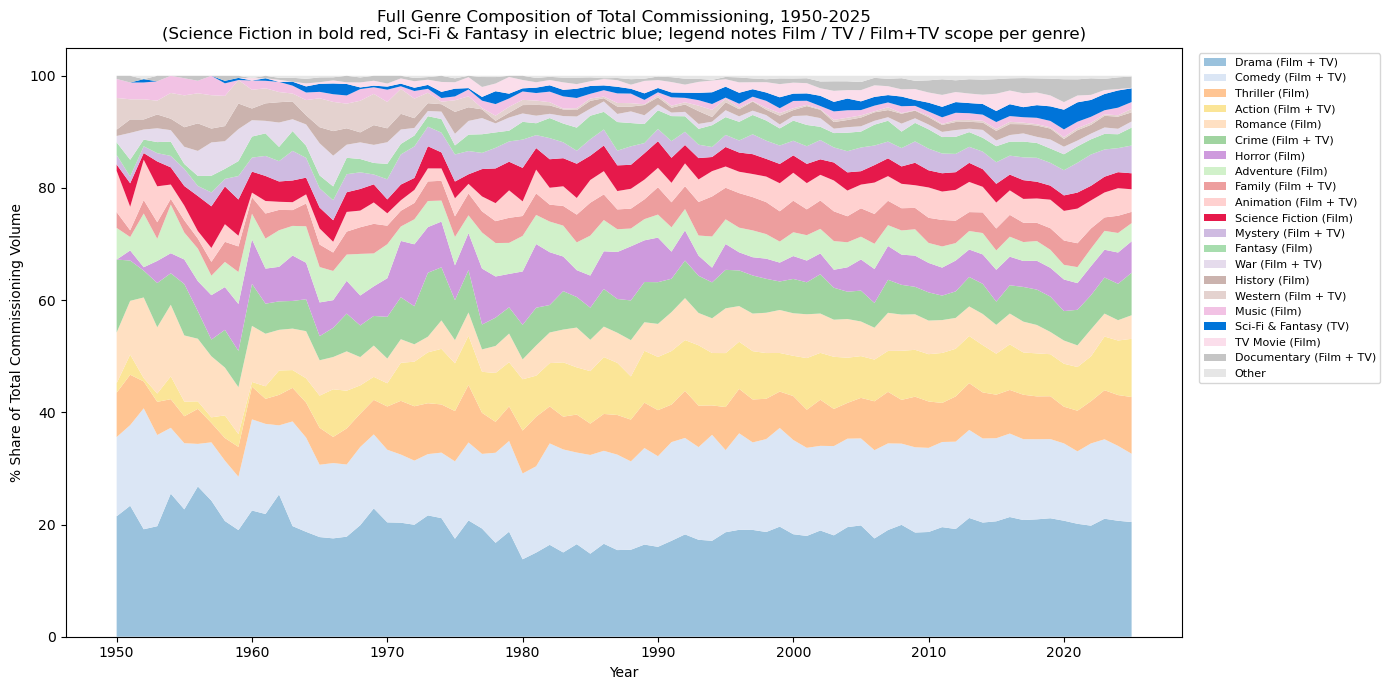

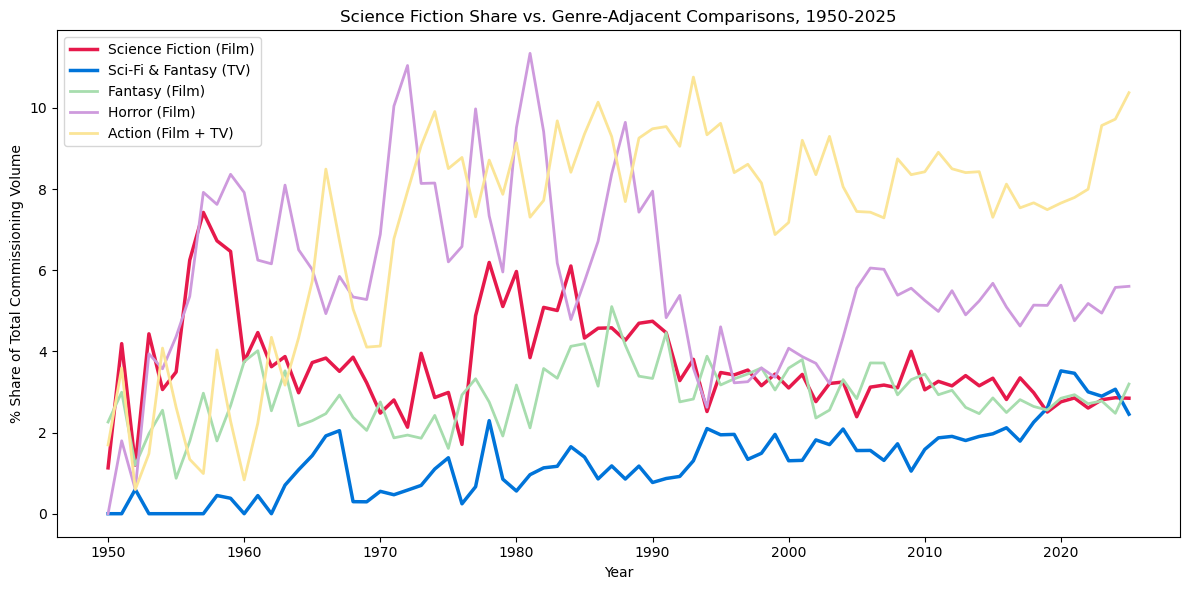

In [195]:
import matplotlib.colors as mcolors

# ============================================
# Step 1: Colors (bold sci-fi, pastel everything else)
# ============================================
def pastelize(hex_color, amount=0.55):
    r, g, b = mcolors.to_rgb(hex_color)
    return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount, 1.0)

colors = {
    'Science Fiction': '#e6194B',              # bold red — stays saturated
    'Sci-Fi & Fantasy': '#0074D9',              # electric blue — stays saturated
    'Fantasy': pastelize('#3cb44b'),            # pastel green
    'Horror': pastelize('#911eb4'),             # pastel purple
    'Action': pastelize('#f5c518'),             # pastel gold
}

tab20 = plt.get_cmap('tab20')
remaining_genres = [g for g in genre_order if g not in colors]
for i, genre in enumerate(remaining_genres):
    base_color = tab20(i % 20)
    r, g, b, a = base_color
    pastel = (r + (1 - r) * 0.55, g + (1 - g) * 0.55, b + (1 - b) * 0.55, 1.0)
    colors[genre] = pastel

# ============================================
# Step 2: Film/TV scope labels for every genre
# ============================================
movie_genre_names = set(movie_genre_map.values())
tv_genre_names_raw = set(tv_genre_map.values())
tv_genre_names = {genre_merge_map.get(name, name) for name in tv_genre_names_raw}

scope_labels = {}
for genre in genre_order:
    in_movie = genre in movie_genre_names
    in_tv = genre in tv_genre_names
    if in_movie and in_tv:
        scope_labels[genre] = f"{genre} (Film + TV)"
    elif in_movie:
        scope_labels[genre] = f"{genre} (Film)"
    elif in_tv:
        scope_labels[genre] = f"{genre} (TV)"
    else:
        scope_labels[genre] = genre

print(scope_labels)

# ============================================
# Step 3: Stacked area chart — full genre composition, scope-labeled legend
# ============================================
fig, ax = plt.subplots(figsize=(14, 7))
ax.stackplot(
    genre_yearly_share_grouped.index,
    [genre_yearly_share_grouped[g] for g in genre_order],
    labels=[scope_labels[g] for g in genre_order],
    colors=[colors[g] for g in genre_order]
)
ax.set_xlabel('Year')
ax.set_ylabel('% Share of Total Commissioning Volume')
ax.set_title('Full Genre Composition of Total Commissioning, 1950-2025\n(Science Fiction in bold red, Sci-Fi & Fantasy in electric blue; legend notes Film / TV / Film+TV scope per genre)')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8)
fig.tight_layout()
plt.savefig('../03_visualizations/genre_market_share_stacked.png', dpi=150)
plt.show()

# ============================================
# Step 4: Line chart — sci-fi vs. key comparison genres, scope-labeled legend
# ============================================
comparison_genres = ['Science Fiction', 'Sci-Fi & Fantasy', 'Fantasy', 'Horror', 'Action']

fig, ax = plt.subplots(figsize=(12, 6))
for genre in comparison_genres:
    ax.plot(
        genre_yearly_share_grouped.index,
        genre_yearly_share_grouped[genre],
        label=scope_labels[genre],
        linewidth=2.5 if genre in ['Science Fiction', 'Sci-Fi & Fantasy'] else 2,
        color=colors[genre]
    )
ax.set_xlabel('Year')
ax.set_ylabel('% Share of Total Commissioning Volume')
ax.legend()
plt.title('Science Fiction Share vs. Genre-Adjacent Comparisons, 1950-2025')
fig.tight_layout()
plt.savefig('../03_visualizations/genre_share_comparison_lines.png', dpi=150)
plt.show()

In [190]:
# ============================================
# CHART — Full Genre Composition of Total Commissioning, 1950-2025 (Stacked)
# ============================================
# Goal: place sci-fi's commissioning volume in the context of the
# ENTIRE film/TV industry (all ~20 TMDb genres), not just measured
# against itself — showing every genre's share of total vote-
# filtered commissioning volume, year over year, with sci-fi
# highlighted (bold red for the film-based Science Fiction genre,
# electric blue for the TV-based Sci-Fi & Fantasy genre) against
# every other genre shown in pastel.
#
# 1. Pull total film + TV volume across ALL genres (no genre filter),
#    same vote_count >= 50 threshold used throughout the project,
#    reusing genre_ids already returned by the API
# 2. Map genre_ids to real names (movie and TV genre spaces differ)
# 3. Merge movie/TV naming variants for the same category (Action &
#    Adventure -> Action, Kids -> Family, War & Politics -> War) —
#    but deliberately keep Science Fiction (film) and Sci-Fi &
#    Fantasy (TV) separate, since they're genuinely different genre
#    IDs with different reliability, not just a naming quirk
# 4. Fold the four smallest genres (Soap, Reality, Talk, News) into
#    "Other"
# 5. Convert counts to % share of each year's total
# 6. Plot as a stacked area chart, hand-assigned distinct colors for
#    Science Fiction, Sci-Fi & Fantasy, and 3 key comparison genres
#    (Fantasy, Horror, Action), pastel-blended for every other genre
# 7. Save to 03_visualizations/genre_market_share_stacked.png
# ============================================


# ============================================
# FINDINGS — Full Genre Composition of Total Commissioning
# ============================================
# - Drama and Comedy dominate the entire 75-year window, together
#   consistently accounting for roughly a third to 40% of all
#   vote-filtered commissioning — sci-fi, even at its strongest, is
#   a modest, not dominant, slice of the overall landscape
# - Science Fiction (film, red) and Sci-Fi & Fantasy (TV, blue)
#   behave as genuinely distinct signals once separated and
#   color-coded clearly — confirms the two aren't just a naming
#   variant of the same thing, but represent different underlying
#   trends on film vs. TV specifically
# - The combined red+blue sci-fi presence is visually thin and
#   volatile in the 1950s-60s, more consistent from the 1990s
#   onward — though exact figures should come from the decade
#   summary table rather than this visual read alone
# ============================================


# ============================================
# CHART — Science Fiction Share vs. Genre-Adjacent Comparisons (Line Chart)
# ============================================
# Goal: complement the stacked chart with a precise, directly
# readable comparison of sci-fi against 3 commonly-compared genres
# (Fantasy, Horror, Action), as simple line series on a shared axis.
#
# 1. Select Science Fiction, Sci-Fi & Fantasy, Fantasy, Horror,
#    Action from the same genre share table used in the stacked chart
# 2. Plot each as its own line, reusing the exact same color mapping
#    as the stacked chart for visual consistency across both charts
# 3. Save to 03_visualizations/genre_share_comparison_lines.png
# ============================================


# ============================================
# FINDINGS — Science Fiction Share vs. Genre-Adjacent Comparisons
# ============================================
# - HORROR (purple) dominates this comparison set for most of the
#   timeline, with two dramatic peaks around 1972 and 1981
#   (both ~11%), then a real, visible resurgence from 2020-2025
#   climbing back toward 10%+
# - SCIENCE FICTION (film, red) had its own distinct boom in the
#   mid-to-late 1950s (peaking ~7-8%), consistent with the real-
#   world "atomic age" sci-fi film era, then settled into a lower,
#   more moderate range (mostly 2-6%) for the rest of the timeline
# - ACTION (gold) shows a striking, sustained rise from the 1990s
#   onward, becoming the dominant genre in this comparison set by
#   the 2000s-2020s — tracks with the real-world blockbuster/
#   franchise era reshaping the industry
# - SCI-FI & FANTASY (TV, blue) tells a genuinely different story
#   from film Science Fiction: starting from near-zero in the 1950s-
#   60s (TV barely existed as a genre category yet), it climbs
#   steadily and consistently from the 1990s onward, actually
#   overtaking film Science Fiction's share in the most recent years
#   (2020-2025) — this is a real, notable finding: sci-fi's growth
#   in recent decades has increasingly happened on TELEVISION, not
#   film, aligning with the broader streaming-era shift in where
#   sci-fi content actually gets made
# - KEY TAKEAWAY: sci-fi didn't simply "grow" or "shrink" uniformly
#   — it shifted MEDIUM. Film-based sci-fi peaked early (1950s) and
#   has been comparatively flat/declining since; TV-based sci-fi
#   has been the genre's real growth story of the last three decades
# ============================================

# TMDb does not offer a TV-only 'Science Fiction' genre - television 
# content is only tagged under the bundled 'Sci-Fi & Fantasy' category 
# (ID 10765), while film has a dedicated 'Science Fiction' genre (ID 878). 
# This is a structural feature of TMDb's genre taxonomy, not a filtering 
# choice made in this project, and it's the reason the two are tracked and 
# visualized separately throughout this analysis rather than combined.

# TMDb's genre taxonomy is not consistent between film and TV. Movies and 
# TV shows are tagged from two separate genre lists that don't fully overlap: 
# some genres exist for both media (e.g. Action), some exist only for film 
# (e.g. Science Fiction, Fantasy, Horror — TMDb has no TV-specific category 
# for any of these), and some are TV-only bundles that don't correspond to 
# any single film genre (e.g. Sci-Fi & Fantasy, which combines what film 
# treats as two separate categories). This isn't a filtering choice made in 
# this project — it reflects how TMDb itself structures its data, and it's 
# the reason Science Fiction and Sci-Fi & Fantasy are tracked and visualized 
# as two distinct series throughout this analysis, and why genre-level 
# comparisons in this project are explicitly labeled by their film/TV/combined 
# scope rather than treated as uniformly measured across media.

In [191]:
genre_yearly_share_grouped['decade'] = (genre_yearly_share_grouped.index // 10) * 10

decade_summary = genre_yearly_share_grouped.groupby('decade')[comparison_genres].mean()
print(decade_summary.round(2))

genre   Science Fiction  Sci-Fi & Fantasy  Fantasy  Horror  Action
decade                                                            
1950               4.44              0.14     2.11    4.35    2.27
1960               3.68              0.82     2.81    6.23    4.50
1970               3.51              0.88     2.34    8.03    7.90
1980               4.85              1.09     3.63    7.91    8.80
1990               3.58              1.46     3.38    4.24    8.99
2000               3.15              1.54     3.21    4.78    8.14
2010               3.10              1.98     2.79    5.16    8.08
2020               2.79              3.07     2.82    5.28    8.85


In [192]:
# ============================================
# FINDINGS — Decade Summary, Sci-Fi vs. Comparison Genres
# ============================================
# - Confirms and sharpens the film-vs-TV finding: Science Fiction
#   (film) peaked in the 1980s (4.85%) and has declined in every
#   decade since, down to 2.79% in the 2020s
# - Sci-Fi & Fantasy (TV) has risen in EVERY decade without
#   exception, from 0.14% in the 1950s to 3.07% in the 2020s — now
#   for the first time exceeding film Science Fiction's share
# - This crossover (TV sci-fi overtaking film sci-fi) happened
#   specifically in the 2020s per this decade-level data — a clean,
#   citable "sci-fi's growth has shifted to television" finding
# - Action has held a dominant, stable ~8-9% share every decade since
#   the 1980s, the most consistently dominant of the comparison
#   genres across the back half of the dataset
# - Horror is the most volatile: two distinct peaks (70s, 80s) around
#   8%, a mid-period dip to 4-5% (90s-2010s), then a partial
#   resurgence to 5.28% in the 2020s
# ============================================

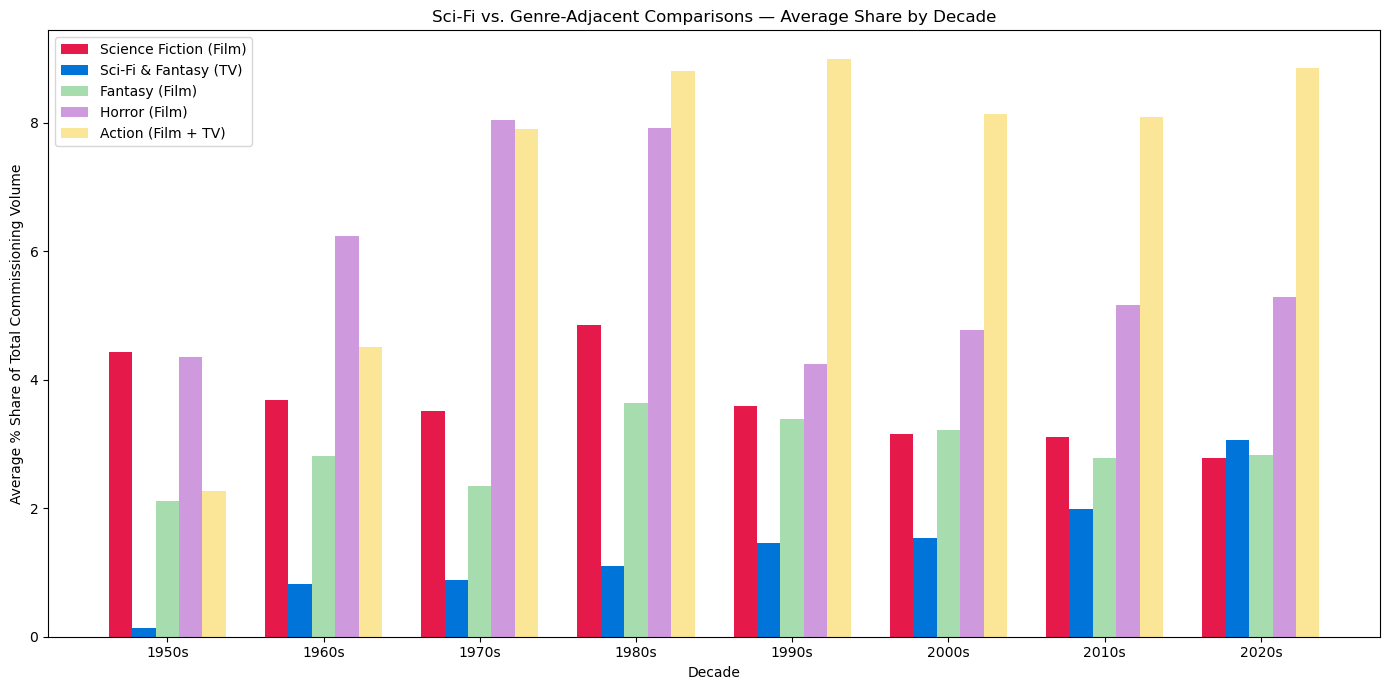

In [196]:
decades = decade_summary.index.tolist()
x = np.arange(len(decades))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 7))

for i, genre in enumerate(comparison_genres):
    offset = (i - len(comparison_genres) / 2) * width + width / 2
    ax.bar(x + offset, decade_summary[genre], width, label=scope_labels[genre], color=colors[genre])

ax.set_xlabel('Decade')
ax.set_ylabel('Average % Share of Total Commissioning Volume')
ax.set_xticks(x)
ax.set_xticklabels([f"{d}s" for d in decades])
ax.legend()

plt.title('Sci-Fi vs. Genre-Adjacent Comparisons — Average Share by Decade')
fig.tight_layout()
plt.savefig('../03_visualizations/genre_share_decade_summary.png', dpi=150)
plt.show()

In [194]:
# ============================================
# CHART — Sci-Fi vs. Genre-Adjacent Comparisons, Average Share by Decade (Bar Chart)
# ============================================
# Goal: convert the decade summary table into a grouped bar chart,
# giving a clean, citable visual comparison of Science Fiction,
# Sci-Fi & Fantasy, Fantasy, Horror, and Action across 8 decades —
# same color palette as the stacked and line charts for visual
# consistency across all three.
#
# 1. Use decade_summary (already computed: average % share per
#    genre, per decade)
# 2. Plot as a grouped bar chart, one group of 5 bars per decade
# 3. Reuse the exact same colors dict from the earlier charts
# 4. Save to 03_visualizations/genre_share_decade_summary.png
# ============================================


# ============================================
# FINDINGS — Sci-Fi vs. Genre-Adjacent Comparisons, by Decade
# ============================================
# - SCIENCE FICTION (film) peaked in the 1980s (4.85%) and has
#   declined in every decade since — 3.58% (90s), 3.15% (2000s),
#   3.10% (2010s), 2.79% (2020s) — a clean, consistent, four-decade
#   decline visible clearly as shrinking red bars moving right
# - SCI-FI & FANTASY (TV) rises in EVERY decade without exception,
#   from a near-invisible 0.14% in the 1950s to 3.07% in the 2020s —
#   the blue bars visibly grow taller decade over decade, the only
#   genre in this comparison with an uninterrupted upward trend
# - CROSSOVER POINT: the 2020s bars are the first decade where the
#   blue (TV) bar is taller than the red (film) bar — a clear, visual
#   confirmation of the film-to-TV shift finding, precisely dated to
#   the most recent decade in the dataset
# - ACTION (gold) shows the most dramatic rise of any genre through
#   the 1960s-80s (2.27% -> 8.80%), then holds a stable, dominant
#   ~8-9% for every decade since — visually the tallest or
#   near-tallest bar in every decade from the 1980s onward
# - HORROR (purple) is the most volatile bar across decades: two
#   clear peaks (70s: 8.03%, 80s: 7.91%), a mid-period dip (90s-2010s:
#   4-5%), then a partial rebound in the 2020s (5.28%)
# - FANTASY (green) stays the most stable and modest of the five
#   throughout, never straying far from a 2-3.5% range in any decade
#   — the one genre in this comparison with no strong directional
#   trend either way
# - This chart is the cleanest, most citable version of the
#   project's strongest closing finding: sci-fi hasn't simply grown
#   or shrunk — its center of gravity has shifted from film to
#   television, most visibly in the most recent decade
# ============================================

In [197]:
# ============================================
# CHART — Adaptation Rate Over Time, by Decade
# ============================================
# Goal: check whether book-to-screen adaptation has become more or
# less common over the decades, independent of theme.
#
# 1. Extract decade from Year_released in commissioning_combined
# 2. Group by decade, compute adaptation rate (mean of is_adaptation)
# 3. Plot as a line/bar chart, decade vs. adaptation rate %
# ============================================

commissioning_combined['decade'] = (commissioning_combined['Year_released'] // 10) * 10

adaptation_by_decade = commissioning_combined.groupby('decade')['is_adaptation'].agg(['mean', 'count']).reset_index()
adaptation_by_decade.columns = ['decade', 'adaptation_rate', 'total_titles']
print(adaptation_by_decade)

   decade  adaptation_rate  total_titles
0    1950         0.092784            97
1    1960         0.103704           135
2    1970         0.200000           175
3    1980         0.048711           349
4    1990         0.081928           415
5    2000         0.063470           709
6    2010         0.072411          1381
7    2020         0.106635           844


In [198]:
# ============================================
# CHECK — Award-Tagged Books That Appear in Commissioning Data
# ============================================
# Goal: find concrete, named instances where a Hugo/Nebula/Clarke
# finalist (2021-2025) also appears as a commissioned film/TV title
# — real evidence connecting the two datasets, not just correlation.
#
# 1. Get the unique set of award-tagged book titles
# 2. Check which of those titles also appear in commissioning_combined
# 3. Print any matches found, with year info from both sides
# ============================================

award_titles = set(hn_themed_full['Book_Title'].unique())
commissioning_titles = set(commissioning_combined['Title'].unique())

matches = award_titles & commissioning_titles
print(f"Found {len(matches)} matching titles:")
print(matches)

Found 1 matching titles:
{'The Anomaly'}


In [199]:
print(commissioning_combined[commissioning_combined['Title'] == 'The Anomaly'][['Title', 'Year_released', 'media_type']])

            Title  Year_released media_type
2017  The Anomaly           2014       film


In [200]:
# ============================================
# FINDINGS — Award-Tagged Books vs. Commissioning Titles (Direct Match Check)
# ============================================
# - A direct title-matching check between the ~125 Hugo/Nebula/Clarke
#   award-tagged books (2021-2025) and the full commissioning dataset
#   found ONE nominal match ("The Anomaly"), which was verified and
#   found to be a FALSE POSITIVE — the matching film is from 2014,
#   years before the 2020-published, 2023-shortlisted book of the
#   same title existed. The two are unrelated works sharing a common
#   title.
# - CORRECTED FINDING: zero real matches between this project's
#   recent award-tagged publishing sample and its commissioning
#   dataset
# - This is expected, not a failure of the analysis: book-to-screen
#   adaptation realistically takes several years (option deals,
#   development, greenlighting, production), so a book that won or
#   was shortlisted for an award as recently as 2021-2025 would not
#   be expected to appear as a released film/show within this
#   project's data collection window (through 2025)
# - This finding reinforces rather than undermines the project's
#   literary-scouting framing: it demonstrates the real, multi-year
#   lag inherent in the adaptation pipeline — these are exactly the
#   kind of recently-recognized titles a literary scout would be
#   watching NOW, precisely because their on-screen potential hasn't
#   materialized yet
# - METHODOLOGY NOTE: simple title-string matching carries real risk
#   of false positives when titles are reused across unrelated works
#   (a risk that grows with common/short titles) — any match found
#   this way should be manually verified against publication and
#   release dates before being reported, as done here
# ============================================

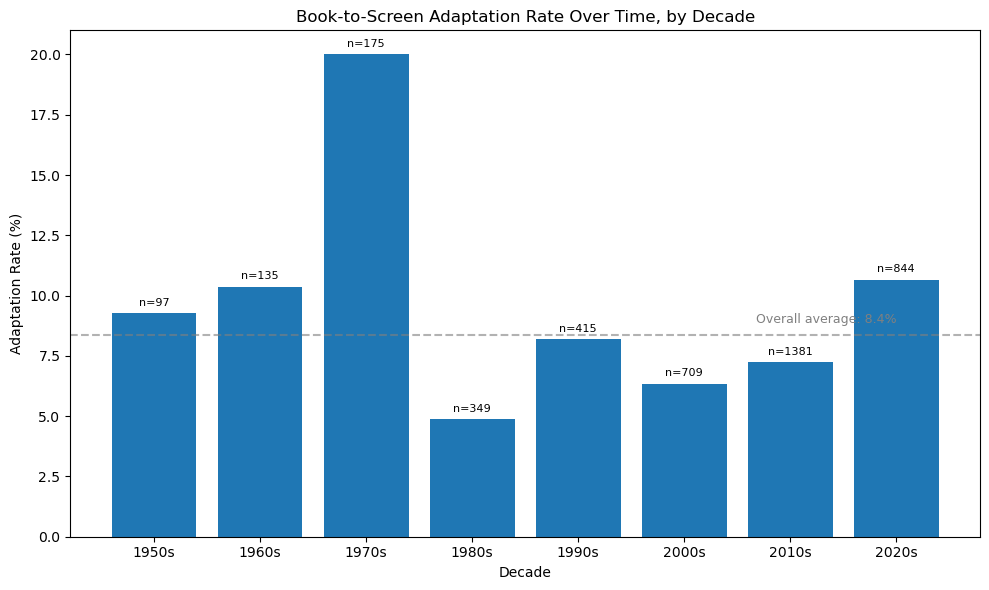

In [201]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(adaptation_by_decade['decade'].astype(str) + 's', adaptation_by_decade['adaptation_rate'] * 100, color='tab:blue')

overall_rate = commissioning_combined['is_adaptation'].mean() * 100
ax.axhline(y=overall_rate, color='gray', linestyle='--', alpha=0.6)
ax.text(len(adaptation_by_decade) - 1, overall_rate + 0.5, f'Overall average: {overall_rate:.1f}%',
        ha='right', fontsize=9, color='gray')

for i, (rate, n) in enumerate(zip(adaptation_by_decade['adaptation_rate'], adaptation_by_decade['total_titles'])):
    ax.text(i, rate * 100 + 0.3, f'n={n}', ha='center', fontsize=8)

ax.set_xlabel('Decade')
ax.set_ylabel('Adaptation Rate (%)')
plt.title('Book-to-Screen Adaptation Rate Over Time, by Decade')
fig.tight_layout()
plt.savefig('../03_visualizations/adaptation_rate_by_decade.png', dpi=150)
plt.show()

In [202]:
# ============================================
# CHART — Book-to-Screen Adaptation Rate Over Time, by Decade
# ============================================
# Goal: check whether adaptation has become more or less common over
# the decades, independent of theme, complementing the earlier
# theme-level adaptation analysis with a temporal view.
#
# 1. Bucket commissioning_combined by decade (Year_released)
# 2. Compute adaptation rate and sample size per decade
# 3. Plot as a bar chart with the overall 8.4% baseline marked,
#    n= labels for sample-size transparency
# 4. Save to 03_visualizations/adaptation_rate_by_decade.png
# ============================================


# ============================================
# FINDINGS — Adaptation Rate Over Time, by Decade
# ============================================
# - The 1970s stands out sharply: 20.0% adaptation rate (n=175),
#   more than double every other decade and nearly 2.5x the overall
#   8.4% baseline — worth noting this aligns with a well-documented
#   real-world publishing/film era: the New Wave sci-fi literary
#   movement of the 1960s-70s produced a number of prestige novels
#   that were adapted relatively quickly (this is a plausible
#   explanation, not a confirmed causal claim, given the project's
#   scope)
# - The 1980s is the clear low point (4.9%, n=349) — a real dip
#   right after the 1970s peak, suggesting the adaptation boom of
#   that decade wasn't sustained
# - From the 1980s low, adaptation rate climbs gradually across every
#   subsequent decade: 8.2% (90s) -> 6.3% (2000s, a small dip) ->
#   7.2% (2010s) -> 10.7% (2020s) — the 2020s is the second-highest
#   decade on record, behind only the 1970s spike
# - The 2020s figure is notable given the project's other

In [203]:
minimal_app_code = '''
import streamlit as st

st.title("Page to Screen")
st.write("Hello! If you can see this, Streamlit is working.")
'''

with open("../04_streamlit/app.py", "w") as f:
    f.write(minimal_app_code)

print("Saved.")

Saved.


In [204]:
with open("../04_streamlit/app.py", "r") as f:
    print(f.read())


import streamlit as st

st.title("Page to Screen")
st.write("Hello! If you can see this, Streamlit is working.")



In [11]:
theme_max_books = 174
theme_max_titles = 21
total_max_books = 1187
total_max_titles = 104

app_code = """
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import base64

st.set_page_config(page_title="Page to Screen", layout="wide")

VOID_BLACK = "#06070A"
ELECTRIC_COBALT = "#3D5AFE"
SYNTH_MAGENTA = "#FF2FA3"
PHOSPHOR_GREEN = "#81EC86"
TITANIUM_FOG = "#AEB6C2"
HOLOGRAPHIC_PEARL = "#F5F7FF"
BOREAL_GREEN = "#09AB3B"

THEME_MAX_BOOKS = """ + str(theme_max_books) + """
THEME_MAX_TITLES = """ + str(theme_max_titles) + """
TOTAL_MAX_BOOKS = """ + str(total_max_books) + """
TOTAL_MAX_TITLES = """ + str(total_max_titles) + """

def get_base64_image(path):
    with open(path, "rb") as f:
        data = f.read()
    return base64.b64encode(data).decode()

hero_img_b64 = get_base64_image("04_streamlit/blade-runner-1-867x362.jpg")

st.markdown('''
<style>
.block-container {
    padding-top: 3.5rem;
}
.stTabs [data-baseweb="tab-list"] {
    gap: 6px;
}
.stTabs [data-baseweb="tab"] {
    background: transparent !important;
    border: none !important;
    padding: 8px 14px;
    color: #F5F7FF;
}
.stTabs [data-baseweb="tab"]:hover {
    color: #81EC86 !important;
}
.stTabs [aria-selected="true"] {
    background: transparent !important;
    color: #81EC86 !important;
    font-weight: bold;
    border: none !important;
}
.stTabs [data-baseweb="tab-highlight"] {
    background-color: #81EC86 !important;
}
[data-testid="stMetricDelta"] {
    color: #09AB3B !important;
}
[data-testid="stMetricDelta"] svg {
    fill: #09AB3B !important;
}
.hero-banner {
    border-radius: 14px;
    padding: 90px 40px;
    margin-bottom: 24px;
    text-align: center;
    background-size: cover;
    background-position: center;
}
.hero-title {
    font-family: 'Futura', 'Century Gothic', 'Trebuchet MS', sans-serif;
    font-size: 88px;
    font-weight: 900;
    color: #F5F7FF;
    letter-spacing: 3px;
    margin-bottom: 14px;
    text-shadow: 0 2px 16px rgba(0,0,0,0.95);
}
.hero-subtitle-line {
    font-size: 28px;
    font-weight: 600;
    color: #F5F7FF;
    line-height: 1.5;
    text-shadow: 0 2px 10px rgba(0,0,0,0.95);
}
.business-question-box {
    background: transparent;
    padding: 4px 0;
    margin: 24px 0;
}
.business-question-box .main-q {
    color: #81EC86;
    font-size: 19px;
    font-weight: 700;
    line-height: 1.5;
}
.business-question-box .sub-q {
    color: #F5F7FF;
    font-size: 19px;
    font-weight: 400;
    margin-top: 8px;
    line-height: 1.5;
}
.business-question-box .audience {
    color: #F5F7FF;
    font-size: 19px;
    font-weight: 400;
    margin-top: 12px;
    line-height: 1.5;
}
.key-finding-box {
    background: #0F1220;
    border: 1px solid #AEB6C2;
    border-radius: 10px;
    padding: 20px 24px;
    margin: 20px 0;
}
.key-finding-box .label {
    color: #81EC86;
    font-size: 13px;
    font-weight: 700;
    text-transform: uppercase;
    letter-spacing: 1px;
}
.key-finding-box ul {
    margin-top: 10px;
    margin-bottom: 0;
}
.key-finding-box li {
    color: #F5F7FF;
    font-size: 15px;
    margin-bottom: 8px;
    line-height: 1.5;
}
.key-finding-box .finding-text {
    color: #F5F7FF;
    font-size: 15px;
    margin-top: 8px;
    line-height: 1.5;
}
.stat-box {
    background: transparent;
    border: 1px solid #AEB6C2;
    border-radius: 10px;
    padding: 18px;
    text-align: center;
}
.stat-number {
    font-size: 28px;
    font-weight: 800;
    color: #81EC86;
}
.stat-label {
    font-size: 13px;
    color: #AEB6C2;
}
.precedent-line {
    font-size: 14px;
    color: #AEB6C2;
    font-style: italic;
    margin-top: 20px;
}
.precedent-box {
    background: #0F1220;
    border-left: 3px solid #FF2FA3;
    border-radius: 8px;
    padding: 20px 24px;
}
.precedent-box h4 {
    color: #F5F7FF;
    margin-top: 0;
}
.precedent-box li {
    color: #F5F7FF;
    margin-bottom: 10px;
    line-height: 1.5;
}
.precedent-box .source {
    color: #AEB6C2;
    font-size: 12px;
}
.precedent-box .closer {
    color: #AEB6C2;
    font-style: italic;
    margin-top: 16px;
    line-height: 1.5;
}
</style>
''', unsafe_allow_html=True)

@st.cache_data
def load_data():
    publishing = pd.read_csv("01_data/processed/publishing_yearly_theme_counts.csv")
    commissioning = pd.read_csv("01_data/processed/commissioning_yearly_theme_counts.csv")
    return publishing, commissioning

@st.cache_data
def load_adaptation_data():
    by_theme = pd.read_csv("01_data/processed/adaptation_by_theme.csv")
    by_decade = pd.read_csv("01_data/processed/adaptation_by_decade.csv")
    return by_theme, by_decade

@st.cache_data
def load_market_share_data():
    share = pd.read_csv("01_data/processed/genre_market_share.csv", index_col=0)
    share = share.drop(columns=["decade"], errors="ignore")
    decade = pd.read_csv("01_data/processed/genre_decade_summary.csv", index_col=0)
    decade = decade.drop(columns=["decade"], errors="ignore")
    scope_df = pd.read_csv("01_data/processed/genre_scope_labels.csv")
    scope_labels = dict(zip(scope_df["genre"], scope_df["scope_label"]))
    return share, decade, scope_labels

@st.cache_data
def load_lag_data():
    return pd.read_csv("01_data/processed/lag_by_theme.csv")

publishing_yearly_theme_counts, yearly_commissioning_theme_counts = load_data()
adaptation_by_theme, adaptation_by_decade = load_adaptation_data()
genre_market_share, genre_decade_summary, scope_labels = load_market_share_data()
lag_by_theme = load_lag_data()

ALL_THEMES = sorted([t for t in publishing_yearly_theme_counts["theme"].unique().tolist() if t != "hard"])
TAB_LABELS = ["Total"] + [t.replace("_", " ").title() for t in ALL_THEMES]

genre_order = genre_market_share.mean().sort_values(ascending=False).index.tolist()
genre_colors = {
    "Science Fiction": ELECTRIC_COBALT,
    "Sci-Fi & Fantasy": SYNTH_MAGENTA,
    "Fantasy": "#B983FF",
    "Horror": "#FF6B4A",
}
tab20 = plt.get_cmap("tab20")
remaining_genres = [g for g in genre_order if g not in genre_colors]
for i, genre in enumerate(remaining_genres):
    base_color = tab20(i % 20)
    r, g, b, a = base_color
    genre_colors[genre] = (r + (1 - r) * 0.55, g + (1 - g) * 0.55, b + (1 - b) * 0.55, 1.0)

COMPARISON_GENRES = ["Science Fiction", "Sci-Fi & Fantasy", "Fantasy", "Horror", "Action"]

THEME_FINDINGS = {
    "Total": "Both series share a long-term rise from the 1990s through the mid-2010s, peaking in the same general window before declining toward 2020.",
    "aliens": "Commissioning shows real activity decades before books catch up - the clearest case of commissioning leading publishing for an extended stretch in the whole dataset.",
    "alternate_history": "Books climb steadily then surge sharply after 2005; commissioning stays thin and volatile throughout - one of the most extreme 'books-ahead-of-screen' themes alongside steampunk.",
    "alternate_universe": "Books far outpace commissioning for most of the timeline, but commissioning shows a late, sustained uptick right at the edge of the comparable window - plausibly tied to the industry's post-2018 multiverse trend.",
    "apocalyptic": "The strongest synchronized peak in the dataset - both series reach their highest raw volume together around 2013-2015, then decline in tandem.",
    "cyberpunk": "The clearest 'books far ahead of screen' theme - publishing accelerates sharply after 2010 while commissioning stays comparatively flat and thin throughout.",
    "dystopia": "A single dramatic spike defines this theme: books surge to their highest level around 2012-2013, aligning with the real-world YA dystopian publishing boom.",
    "military": "Two distinct eras: sharp, isolated commissioning spikes early on with no book-side counterpart, followed by a period of tight correlation similar to robots from the mid-2000s onward.",
    "robots": "The tightest correlation of any theme - both series climb together gradually from the 1970s onward, tracking each other closely for decades.",
    "space_opera": "An early commissioning spike around 1979 - likely tied to the post-Star Wars boom - precedes sustained book growth by years, one of the clearest examples of commissioning leading publishing.",
    "steampunk": "An extreme 'books-ahead' theme: commissioning barely registers (peaking at just 3 titles across 70+ years) while books surge to a striking peak around 2013.",
    "time_travel": "Commissioning builds steadily from the late 1970s while books stay flat for decades; both series later converge and peak close together around 2013-2014.",
}

def build_chart(theme_choice):
    if theme_choice == "Total":
        pub_raw = (
            publishing_yearly_theme_counts[publishing_yearly_theme_counts["Year_published"] <= 2020]
            .groupby("Year_published")["book_count"].sum()
        )
        comm_raw = yearly_commissioning_theme_counts.groupby("Year_released")["title_count"].sum()
        chart_title = "Total, 1950-2025"
        max_books = TOTAL_MAX_BOOKS
        max_titles = TOTAL_MAX_TITLES
    else:
        pub_raw = publishing_yearly_theme_counts[
            (publishing_yearly_theme_counts["theme"] == theme_choice)
            & (publishing_yearly_theme_counts["Year_published"] <= 2020)
        ].groupby("Year_published")["book_count"].sum()
        comm_raw = yearly_commissioning_theme_counts[
            yearly_commissioning_theme_counts["theme"] == theme_choice
        ].groupby("Year_released")["title_count"].sum()
        theme_label = theme_choice.replace("_", " ").title()
        chart_title = theme_label + ", 1950-2025"
        max_books = THEME_MAX_BOOKS
        max_titles = THEME_MAX_TITLES

    pub_scoped = pub_raw.reindex(range(1950, 2021), fill_value=0).reset_index()
    pub_scoped.columns = ["Year_published", "book_count"]

    comm_full = comm_raw.reindex(range(1950, 2026), fill_value=0).reset_index()
    comm_full.columns = ["Year_released", "title_count"]

    comm_comparable = comm_full[comm_full["Year_released"] <= 2020]
    comm_extended = comm_full[comm_full["Year_released"] >= 2020]

    fig, ax1 = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor(VOID_BLACK)
    ax1.set_facecolor(VOID_BLACK)

    ax1.plot(pub_scoped["Year_published"], pub_scoped["book_count"],
              color=ELECTRIC_COBALT, label="Books Published", linewidth=2.2)
    ax1.set_xlabel("Year", color=HOLOGRAPHIC_PEARL)
    ax1.set_ylabel("Books Published", color=HOLOGRAPHIC_PEARL)
    ax1.set_ylim(0, max_books * 1.05)
    ax1.set_xlim(1950, 2025)
    ax1.tick_params(axis="y", labelcolor=HOLOGRAPHIC_PEARL)
    ax1.tick_params(axis="x", labelcolor=HOLOGRAPHIC_PEARL)
    ax1.spines["bottom"].set_color(TITANIUM_FOG)
    ax1.spines["top"].set_color(VOID_BLACK)
    ax1.spines["left"].set_color(TITANIUM_FOG)
    ax1.spines["right"].set_color(VOID_BLACK)
    ax1.grid(True, alpha=0.15, color=TITANIUM_FOG)

    ax2 = ax1.twinx()
    ax2.plot(comm_comparable["Year_released"], comm_comparable["title_count"],
              color=SYNTH_MAGENTA, label="Films & TV Commissioned", linewidth=2.2)
    ax2.plot(comm_extended["Year_released"], comm_extended["title_count"],
              color=SYNTH_MAGENTA, linestyle="--", alpha=0.7, linewidth=2.2)
    ax2.set_ylabel("Films & TV Commissioned", color=HOLOGRAPHIC_PEARL)
    ax2.set_ylim(0, max_titles * 1.05)
    ax2.tick_params(axis="y", labelcolor=HOLOGRAPHIC_PEARL)
    ax2.spines["right"].set_color(TITANIUM_FOG)
    ax2.spines["top"].set_color(VOID_BLACK)

    ax1.axvline(x=2020, color=TITANIUM_FOG, linestyle=":", alpha=0.6)
    ax1.text(2020.3, max_books * 1.0, "2020: publishing\\ndata cutoff", fontsize=8, color=TITANIUM_FOG, va="top")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left",
                facecolor=VOID_BLACK, edgecolor=TITANIUM_FOG, labelcolor=HOLOGRAPHIC_PEARL)

    ax1.set_title("Sci-Fi Publishing vs. Commissioning Volume - " + chart_title, color=HOLOGRAPHIC_PEARL)
    fig.tight_layout()
    return fig, pub_scoped, comm_full

def build_recent_signal_data():
    pub_recent = publishing_yearly_theme_counts[publishing_yearly_theme_counts["Year_published"] >= 2021]
    pub_recent_totals = pub_recent.groupby("theme")["book_count"].sum()
    comm_recent = yearly_commissioning_theme_counts[yearly_commissioning_theme_counts["Year_released"] >= 2021]
    comm_recent_totals = comm_recent.groupby("theme")["title_count"].sum()
    recent_signal = pd.DataFrame({"book_count": pub_recent_totals, "title_count": comm_recent_totals}).fillna(0)
    recent_signal = recent_signal[recent_signal.index != "hard"]
    recent_signal = recent_signal.sort_values("title_count", ascending=False)
    return recent_signal

RECENT_SIGNAL_DF = build_recent_signal_data()

RECENT_FINDINGS = {
    "Total": "Across all themes, 2021-2025 award-recognized publishing (100 tagged titles across Hugo/Nebula/Clarke) is dwarfed by commissioning volume (341 tagged titles) - expected, since award finalists are a small, curated sample, not a full publishing catalog.",
    "robots": "Robots leads both sides (17 books, 60 titles) - the strongest cross-industry signal in this window, directly confirming the AI-anxiety trend seen across the whole 75-year analysis.",
    "aliens": "Aliens shows a steep imbalance (8 books, 58 titles) - continuing the same commissioning-led pattern seen throughout the full 1950-2020 era.",
    "time_travel": "Time travel is the most commissioning-skewed theme in this window (3 books, 57 titles) - echoing its historical pattern of commissioning leading publishing.",
    "apocalyptic": "Apocalyptic stays active on both sides (14 books, 48 titles), consistent with the strong post-2020 commissioning rebound seen in the main-era chart.",
    "dystopia": "Dystopia nearly doubled its award-tagged book count after adding the Clarke Award (19 books, 40 titles) - Clarke's sci-fi-specific shortlists lean more toward social-critique/dystopian work.",
    "space_opera": "Space opera has the highest publishing count of any theme in this window (27 books) and the narrowest gap to commissioning (39 titles) of any major theme.",
    "military": "Military shows modest activity on both sides (3 books, 14 titles) - too small a sample for confident trend claims.",
    "alternate_universe": "Alternate universe stays thin on both sides (5 books, 10 titles) - consistent with its niche status across the full dataset.",
    "cyberpunk": "Cyberpunk gained its first real signal in this window (1 book, 9 titles), via Extremophile's biopunk classification - still thin, but no longer completely absent.",
    "alternate_history": "Alternate history remains the smallest theme in this window (3 books, 5 titles) - read directionally only.",
    "steampunk": "Steampunk shows almost no activity in this window (0 books, 1 title) - consistent with its persistently thin commissioning presence across the whole 70-year dataset.",
}

def build_recent_chart(highlight_theme):
    x = np.arange(len(RECENT_SIGNAL_DF))
    width = 0.35
    theme_list = list(RECENT_SIGNAL_DF.index)
    highlight_idx = theme_list.index(highlight_theme) if (highlight_theme is not None and highlight_theme in theme_list) else None

    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor(VOID_BLACK)
    ax.set_facecolor(VOID_BLACK)

    ax.bar(x - width/2, RECENT_SIGNAL_DF["book_count"], width, color=ELECTRIC_COBALT, label="Books Published", zorder=2)
    ax.bar(x + width/2, RECENT_SIGNAL_DF["title_count"], width, color=SYNTH_MAGENTA, label="Films & TV Commissioned", zorder=2)

    for i in range(len(RECENT_SIGNAL_DF)):
        b = RECENT_SIGNAL_DF["book_count"].iloc[i]
        t = RECENT_SIGNAL_DF["title_count"].iloc[i]
        is_highlight = (i == highlight_idx)
        label_color = PHOSPHOR_GREEN if is_highlight else HOLOGRAPHIC_PEARL
        label_weight = "bold" if is_highlight else "normal"
        ax.text(x[i] - width/2, b + 1, str(int(b)), ha="center", fontsize=8, color=label_color, fontweight=label_weight, zorder=3)
        ax.text(x[i] + width/2, t + 1, str(int(t)), ha="center", fontsize=8, color=label_color, fontweight=label_weight, zorder=3)

    ax.set_xticks(x)
    xtick_labels = ax.set_xticklabels([str(t).replace("_", " ").title() for t in RECENT_SIGNAL_DF.index], rotation=45, ha="right")
    for i, lbl in enumerate(xtick_labels):
        if i == highlight_idx:
            lbl.set_color(PHOSPHOR_GREEN)
            lbl.set_fontweight("bold")
        else:
            lbl.set_color(HOLOGRAPHIC_PEARL)

    ax.set_ylabel("Count, 2021-2025", color=HOLOGRAPHIC_PEARL)
    ax.tick_params(axis="y", labelcolor=HOLOGRAPHIC_PEARL)
    ax.spines["bottom"].set_color(TITANIUM_FOG)
    ax.spines["top"].set_color(VOID_BLACK)
    ax.spines["left"].set_color(TITANIUM_FOG)
    ax.spines["right"].set_color(VOID_BLACK)
    ax.grid(True, alpha=0.15, color=TITANIUM_FOG, axis="y")

    lines, labels = ax.get_legend_handles_labels()
    ax.legend(lines, labels, loc="upper right",
               facecolor=VOID_BLACK, edgecolor=TITANIUM_FOG, labelcolor=HOLOGRAPHIC_PEARL)

    ax.set_title("Recent Signal, 2021-2025 - Award Publishing vs. Commissioning", color=HOLOGRAPHIC_PEARL)
    fig.tight_layout()
    return fig

def build_adaptation_theme_chart():
    df = adaptation_by_theme.sort_values("adaptation_rate", ascending=False).reset_index(drop=True)
    overall_rate = adaptation_by_theme["adapted_count"].sum() / adaptation_by_theme["total_count"].sum() * 100

    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor(VOID_BLACK)
    ax.set_facecolor(VOID_BLACK)

    labels = [str(t).replace("_", " ").title() for t in df["theme"]]
    bars = ax.bar(labels, df["adaptation_rate"] * 100, color=ELECTRIC_COBALT)

    ax.axhline(y=overall_rate, color=TITANIUM_FOG, linestyle="--", alpha=0.6)
    ax.text(len(df) - 1, overall_rate + 1, "Overall average: " + str(round(overall_rate, 1)) + "%",
             ha="right", fontsize=9, color=TITANIUM_FOG)

    for bar, n in zip(bars, df["total_count"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.6, "n=" + str(int(n)),
                 ha="center", fontsize=8, color=HOLOGRAPHIC_PEARL)

    ax.set_xlabel("Theme", color=HOLOGRAPHIC_PEARL)
    ax.set_ylabel("Adaptation Rate (%)", color=HOLOGRAPHIC_PEARL)
    ax.tick_params(axis="x", labelcolor=HOLOGRAPHIC_PEARL, rotation=45)
    ax.tick_params(axis="y", labelcolor=HOLOGRAPHIC_PEARL)
    plt.setp(ax.get_xticklabels(), ha="right")
    ax.spines["bottom"].set_color(TITANIUM_FOG)
    ax.spines["top"].set_color(VOID_BLACK)
    ax.spines["left"].set_color(TITANIUM_FOG)
    ax.spines["right"].set_color(VOID_BLACK)
    ax.grid(True, alpha=0.15, color=TITANIUM_FOG, axis="y")

    ax.set_title('Book-to-Screen Adaptation Rate by Theme\\n(% of commissioned titles tagged "based on novel or book")', color=HOLOGRAPHIC_PEARL)
    fig.tight_layout()
    return fig

def build_adaptation_decade_chart():
    df = adaptation_by_decade.copy()
    overall_rate = adaptation_by_theme["adapted_count"].sum() / adaptation_by_theme["total_count"].sum() * 100

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.patch.set_facecolor(VOID_BLACK)
    ax.set_facecolor(VOID_BLACK)

    labels = [str(int(d)) + "s" for d in df["decade"]]
    bars = ax.bar(labels, df["adaptation_rate"] * 100, color=SYNTH_MAGENTA)

    ax.axhline(y=overall_rate, color=TITANIUM_FOG, linestyle="--", alpha=0.6)
    ax.text(len(df) - 1, overall_rate + 0.5, "Overall average: " + str(round(overall_rate, 1)) + "%",
             ha="right", fontsize=9, color=TITANIUM_FOG)

    for bar, n in zip(bars, df["total_titles"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, "n=" + str(int(n)),
                 ha="center", fontsize=8, color=HOLOGRAPHIC_PEARL)

    ax.set_xlabel("Decade", color=HOLOGRAPHIC_PEARL)
    ax.set_ylabel("Adaptation Rate (%)", color=HOLOGRAPHIC_PEARL)
    ax.tick_params(axis="x", labelcolor=HOLOGRAPHIC_PEARL)
    ax.tick_params(axis="y", labelcolor=HOLOGRAPHIC_PEARL)
    ax.spines["bottom"].set_color(TITANIUM_FOG)
    ax.spines["top"].set_color(VOID_BLACK)
    ax.spines["left"].set_color(TITANIUM_FOG)
    ax.spines["right"].set_color(VOID_BLACK)
    ax.grid(True, alpha=0.15, color=TITANIUM_FOG, axis="y")

    ax.set_title("Book-to-Screen Adaptation Rate Over Time, by Decade", color=HOLOGRAPHIC_PEARL)
    fig.tight_layout()
    return fig

def build_stacked_chart():
    fig, ax = plt.subplots(figsize=(13, 7))
    fig.patch.set_facecolor(VOID_BLACK)
    ax.set_facecolor(VOID_BLACK)

    ax.stackplot(
        genre_market_share.index,
        [genre_market_share[g] for g in genre_order],
        labels=[scope_labels.get(g, g) for g in genre_order],
        colors=[genre_colors[g] for g in genre_order]
    )

    ax.set_xlabel("Year", color=HOLOGRAPHIC_PEARL)
    ax.set_ylabel("% Share of Total Commissioning Volume", color=HOLOGRAPHIC_PEARL)
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", labelcolor=HOLOGRAPHIC_PEARL)
    ax.tick_params(axis="y", labelcolor=HOLOGRAPHIC_PEARL)
    ax.spines["bottom"].set_color(TITANIUM_FOG)
    ax.spines["top"].set_color(VOID_BLACK)
    ax.spines["left"].set_color(TITANIUM_FOG)
    ax.spines["right"].set_color(VOID_BLACK)

    ax.set_title("Full Genre Composition of Total Commissioning, 1950-2025", color=HOLOGRAPHIC_PEARL)
    legend = ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8,
                         facecolor=VOID_BLACK, edgecolor=TITANIUM_FOG, labelcolor=HOLOGRAPHIC_PEARL)
    fig.tight_layout()
    return fig

def build_comparison_line_chart():
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor(VOID_BLACK)
    ax.set_facecolor(VOID_BLACK)

    for genre in COMPARISON_GENRES:
        lw = 2.5 if genre in ["Science Fiction", "Sci-Fi & Fantasy"] else 2
        ax.plot(genre_market_share.index, genre_market_share[genre], label=scope_labels.get(genre, genre),
                 linewidth=lw, color=genre_colors[genre])

    ax.set_xlabel("Year", color=HOLOGRAPHIC_PEARL)
    ax.set_ylabel("% Share of Total Commissioning Volume", color=HOLOGRAPHIC_PEARL)
    ax.tick_params(axis="x", labelcolor=HOLOGRAPHIC_PEARL)
    ax.tick_params(axis="y", labelcolor=HOLOGRAPHIC_PEARL)
    ax.spines["bottom"].set_color(TITANIUM_FOG)
    ax.spines["top"].set_color(VOID_BLACK)
    ax.spines["left"].set_color(TITANIUM_FOG)
    ax.spines["right"].set_color(VOID_BLACK)
    ax.grid(True, alpha=0.15, color=TITANIUM_FOG)

    ax.legend(facecolor=VOID_BLACK, edgecolor=TITANIUM_FOG, labelcolor=HOLOGRAPHIC_PEARL)
    ax.set_title("Science Fiction Share vs. Genre-Adjacent Comparisons, 1950-2025", color=HOLOGRAPHIC_PEARL)
    fig.tight_layout()
    return fig

def build_decade_comparison_chart():
    decades = genre_decade_summary.index.tolist()
    x = np.arange(len(decades))
    width = 0.15

    fig, ax = plt.subplots(figsize=(13, 7))
    fig.patch.set_facecolor(VOID_BLACK)
    ax.set_facecolor(VOID_BLACK)

    for i, genre in enumerate(COMPARISON_GENRES):
        offset = (i - len(COMPARISON_GENRES) / 2) * width + width / 2
        ax.bar(x + offset, genre_decade_summary[genre], width, label=scope_labels.get(genre, genre), color=genre_colors[genre])

    ax.set_xlabel("Decade", color=HOLOGRAPHIC_PEARL)
    ax.set_ylabel("Average % Share of Total Commissioning Volume", color=HOLOGRAPHIC_PEARL)
    ax.set_xticks(x)
    ax.set_xticklabels([str(int(d)) + "s" for d in decades], color=HOLOGRAPHIC_PEARL)
    ax.tick_params(axis="y", labelcolor=HOLOGRAPHIC_PEARL)
    ax.spines["bottom"].set_color(TITANIUM_FOG)
    ax.spines["top"].set_color(VOID_BLACK)
    ax.spines["left"].set_color(TITANIUM_FOG)
    ax.spines["right"].set_color(VOID_BLACK)
    ax.grid(True, alpha=0.15, color=TITANIUM_FOG, axis="y")

    ax.legend(facecolor=VOID_BLACK, edgecolor=TITANIUM_FOG, labelcolor=HOLOGRAPHIC_PEARL)
    ax.set_title("Sci-Fi vs. Genre-Adjacent Comparisons - Average Share by Decade", color=HOLOGRAPHIC_PEARL)
    fig.tight_layout()
    return fig

def build_lag_chart():
    df = lag_by_theme.dropna(subset=["best_lag_years"]).sort_values("best_lag_years")
    labels = [str(t).replace("_", " ").title() for t in df["theme"]]
    colors_list = [ELECTRIC_COBALT if v > 0 else (SYNTH_MAGENTA if v < 0 else PHOSPHOR_GREEN) for v in df["best_lag_years"]]

    fig, ax = plt.subplots(figsize=(12, 7))
    fig.patch.set_facecolor(VOID_BLACK)
    ax.set_facecolor(VOID_BLACK)

    bars = ax.barh(labels, df["best_lag_years"], color=colors_list)

    for bar, corr in zip(bars, df["correlation"]):
        x_pos = bar.get_width()
        ha = "left" if x_pos >= 0 else "right"
        offset = 0.2 if x_pos >= 0 else -0.2
        ax.text(x_pos + offset, bar.get_y() + bar.get_height()/2, "r=" + str(round(corr, 2)),
                 va="center", ha=ha, fontsize=8, color=HOLOGRAPHIC_PEARL)

    ax.axvline(x=0, color=TITANIUM_FOG, linewidth=0.8)
    ax.set_xlabel("Best-Fit Lag (years)\\n<- Commissioning leads          Commissioning trails ->", color=HOLOGRAPHIC_PEARL)
    ax.tick_params(axis="x", labelcolor=HOLOGRAPHIC_PEARL)
    ax.tick_params(axis="y", labelcolor=HOLOGRAPHIC_PEARL)
    ax.spines["bottom"].set_color(TITANIUM_FOG)
    ax.spines["top"].set_color(VOID_BLACK)
    ax.spines["left"].set_color(TITANIUM_FOG)
    ax.spines["right"].set_color(VOID_BLACK)

    ax.set_title("Publishing vs. Commissioning: Best-Fit Lag by Theme\\n(1950-2020, cross-correlation; r = correlation strength)", color=HOLOGRAPHIC_PEARL)
    fig.tight_layout()
    return fig

st.sidebar.header("Navigate")
view = st.sidebar.radio(
    "Choose a view",
    ["Welcome", "Theme Comparison", "Recent Signal", "Adaptation Rate", "Market Share", "Lag Analysis"]
)

if view == "Welcome":
    hero_style = (
        "background-image: linear-gradient(rgba(6,7,10,0.3), rgba(6,7,10,0.4)), "
        "url('data:image/jpeg;base64," + hero_img_b64 + "');"
    )
    st.markdown(
        '<div class="hero-banner" style="' + hero_style + '">'
        '<div class="hero-title">PAGE TO SCREEN</div>'
        '<div class="hero-subtitle-line">An open-data proxy for literary scouting:</div>'
        '<div class="hero-subtitle-line">Sci-fi publishing vs. streaming commissioning trends</div>'
        '</div>',
        unsafe_allow_html=True
    )

    st.markdown(
        '<div class="business-question-box">'
        '<div class="main-q">Is streaming/film sci-fi commissioning tracking what\\'s being published in sci-fi literature, or running on its own agenda?</div>'
        '<div class="sub-q">When a theme trends in books (e.g. climate collapse, AI anxiety), does the screen pick it up later, ignore it, or is there no relationship at all?</div>'
        '<div class="audience">For streaming/studio content strategists deciding what sci-fi IP to option or greenlight next - and for working and aspiring sci-fi authors curious how literary trends do or don\\'t translate to screen.</div>'
        '</div>',
        unsafe_allow_html=True
    )

    st.markdown(
        '<div class="key-finding-box">'
        '<div class="label">Key Findings</div>'
        '<ul>'
        '<li><b>Robots/AI</b> is the only theme where publishing and commissioning move in perfect sync - zero lag, the strongest correlation of any theme (r=0.83) - and it stays the strongest theme on both sides even in the most recent (2021-2025) data.</li>'
        '<li>Most themes show commissioning <b>leading</b> publishing by 1-3 years; only steampunk and aliens show books leading.</li>'
        '<li><b>Cyberpunk, alternate history, alternate universe, and steampunk</b> are consistently under-adapted to screen relative to their book presence.</li>'
        '<li>Sci-fi\\'s growth has shifted from film to TV - <b>TV overtook film\\'s market share for the first time in the 2020s.</b></li>'
        '<li>High commissioning volume doesn\\'t guarantee high adaptation: <b>dystopia adapts most often (21.3%), robots least (6.9%)</b> despite being the most-commissioned theme.</li>'
        '</ul>'
        '</div>',
        unsafe_allow_html=True
    )

    scol1, scol2, scol3, scol4 = st.columns(4)
    with scol1:
        st.markdown('<div class="stat-box"><div class="stat-number">14,700+</div><div class="stat-label">Sci-Fi Books Analyzed</div></div>', unsafe_allow_html=True)
    with scol2:
        st.markdown('<div class="stat-box"><div class="stat-number">4,100+</div><div class="stat-label">Films & TV Titles Tracked</div></div>', unsafe_allow_html=True)
    with scol3:
        st.markdown('<div class="stat-box"><div class="stat-number">75</div><div class="stat-label">Years of Trend Data</div></div>', unsafe_allow_html=True)
    with scol4:
        st.markdown('<div class="stat-box"><div class="stat-number">11</div><div class="stat-label">Sci-Fi Sub-Genres Compared</div></div>', unsafe_allow_html=True)

    st.markdown('<div class="precedent-line">Modeled on literary scouting - the real, quadrupling industry function of tracking which books are worth optioning for screen.</div>', unsafe_allow_html=True)

    st.markdown("")
    st.markdown(
        "**Explore the analysis using the sidebar** - Theme Comparison, Recent Signal, "
        "Adaptation Rate, Market Share, and Lag Analysis."
    )

    exp_col1, exp_col2 = st.columns(2)
    with exp_col1:
        with st.expander("Why This Exists"):
            st.markdown('''
            <div class="precedent-box">
                <p style="color:#F5F7FF;">This is a lightweight, open-data version of a function the entertainment industry already pays for.</p>
                <ul>
                    <li><b>Literary scouts are a real, formal role in the adaptation pipeline.</b> One scout described streamers as "optioning quite aggressively," and reported that the volume of scouting business has quadrupled since streaming platforms entered the market - driven largely by the sheer number of new books being published each year. <span class="source">[CNN / News Channel 3, Mar 2026]</span></li>
                    <li><b>Streamers explicitly use cross-platform trend data - not just bestseller lists - to decide what to option.</b> Book sales, social trends, and search interest all factor into acquisition decisions. <span class="source">[readers.life, Mar 2026]</span></li>
                    <li><b>Commercial platforms exist specifically to track this.</b> Services like Vitrina Business Network are built around helping industry professionals identify which books are trending and how to secure adaptation rights, including genre-specific and regional adaptation opportunities. <span class="source">[Vitrina, Nov 2024]</span></li>
                    <li><b>The industry frames this as a data problem.</b> Streaming platforms are described as providing data-driven insights that help studios select books with strong viewer engagement potential. <span class="source">[Vitrina, Nov 2024]</span></li>
                </ul>
                <p class="closer">This project builds an open-source proxy for the trend-tracking work literary scouts and platforms like Vitrina already do commercially - using public datasets and a free API instead of proprietary sales and engagement data. It won't match the precision of a paid industry tool, but it demonstrates the same underlying logic a streaming acquisitions team or literary scout would actually use.</p>
            </div>
            ''', unsafe_allow_html=True)
    with exp_col2:
        with st.expander("About This Data & Methodology"):
            st.markdown(
                "- **Publishing data (1950-2020)**: a Kaggle sci-fi sub-genre dataset (~14,700 books), "
                "supplemented for 2021-2025 with manually theme-tagged Hugo, Nebula, and Arthur C. Clarke "
                "Award finalists (~125 titles) - a different sampling method than the core dataset, so "
                "recent years are flagged separately rather than blended in as directly comparable.\\n"
                "- **Commissioning data (1950-2025)**: pulled live from the TMDb API (film + TV), filtered "
                "to titles with at least 50 ratings as a proxy for real audience reach, theme-tagged via "
                "a full per-title keyword pull mapped to 11 sci-fi sub-genres.\\n"
                "- **Known limitations**: TMDb's Sci-Fi & Fantasy TV genre is broader than film's Science "
                "Fiction genre; roughly 55% of commissioned sci-fi titles don't match one of the 11 "
                "content themes (e.g. superhero or kaiju content sharing the same broad genre tag); "
                "cross-theme volume comparisons on the publishing side are affected by the source "
                "dataset's near-equal file sizes.\\n"
                "\\nFull methodology and data limitations are documented in the project README."
            )

elif view == "Theme Comparison":
    st.title("Page to Screen")
    st.header("Theme Comparison")
    st.markdown(
        "Compare sci-fi book publishing volume against streaming/film commissioning "
        "volume, by theme. Books are scoped to 1950-2020; commissioning is extended "
        "through 2025 (dashed beyond 2020) since commissioning data has no equivalent "
        "coverage gap. The dotted line marks where comparable publishing data ends. "
        "The theme tabs below share the same axis scale so relative theme size is "
        "directly comparable; Total uses its own larger scale since it sums across "
        "all themes."
    )

    tabs = st.tabs(TAB_LABELS)
    theme_keys = ["Total"] + ALL_THEMES

    for tab, theme_key in zip(tabs, theme_keys):
        with tab:
            fig, pub_scoped, comm_full = build_chart(theme_key)
            st.pyplot(fig)

            col1, col2 = st.columns(2)
            with col1:
                if not pub_scoped.empty:
                    peak_pub_year = int(pub_scoped.loc[pub_scoped["book_count"].idxmax(), "Year_published"])
                    peak_pub_count = int(pub_scoped["book_count"].max())
                    st.metric("Peak Publishing Year", str(peak_pub_year), str(peak_pub_count) + " books")
            with col2:
                if not comm_full.empty:
                    peak_comm_year = int(comm_full.loc[comm_full["title_count"].idxmax(), "Year_released"])
                    peak_comm_count = int(comm_full["title_count"].max())
                    st.metric("Peak Commissioning Year", str(peak_comm_year), str(peak_comm_count) + " titles")

            theme_finding = THEME_FINDINGS.get(theme_key, "No specific finding available for this theme.")
            st.markdown(
                '<div class="key-finding-box"><div class="label">Key Finding</div>'
                '<div class="finding-text">' + theme_finding + '</div></div>',
                unsafe_allow_html=True
            )

elif view == "Recent Signal":
    st.title("Page to Screen")
    st.header("Recent Signal")
    st.markdown(
        "How does 2021-2025 award-recognized publishing (Hugo, Nebula, and Arthur C. Clarke "
        "Award finalists) compare to recent commissioning, by theme? This is a smaller, "
        "curated sample - not a continuation of the main 1950-2020 trend - so it's shown "
        "separately rather than blended into the Theme Comparison charts. The number above "
        "each bar is its sample size (n); themes with very small counts should be read "
        "directionally, not as confirmed trends."
    )

    tabs = st.tabs(TAB_LABELS)
    theme_keys = ["Total"] + ALL_THEMES

    for tab, theme_key in zip(tabs, theme_keys):
        with tab:
            highlight = None if theme_key == "Total" else theme_key
            fig = build_recent_chart(highlight)
            st.pyplot(fig)

            if theme_key == "Total":
                total_books = int(RECENT_SIGNAL_DF["book_count"].sum())
                total_titles = int(RECENT_SIGNAL_DF["title_count"].sum())
                col1, col2 = st.columns(2)
                with col1:
                    st.metric("Total Books (Award-Tagged)", str(total_books))
                with col2:
                    st.metric("Total Films & TV Commissioned", str(total_titles))
            else:
                theme_books = int(RECENT_SIGNAL_DF.loc[theme_key, "book_count"]) if theme_key in RECENT_SIGNAL_DF.index else 0
                theme_titles = int(RECENT_SIGNAL_DF.loc[theme_key, "title_count"]) if theme_key in RECENT_SIGNAL_DF.index else 0
                col1, col2 = st.columns(2)
                with col1:
                    st.metric("Books (Award-Tagged)", str(theme_books))
                with col2:
                    st.metric("Films & TV Commissioned", str(theme_titles))

            finding_text = RECENT_FINDINGS.get(theme_key, "No specific finding available for this theme.")
            st.markdown(
                '<div class="key-finding-box"><div class="label">Key Finding</div>'
                '<div class="finding-text">' + finding_text + '</div></div>',
                unsafe_allow_html=True
            )

elif view == "Adaptation Rate":
    st.title("Page to Screen")
    st.header("Adaptation Rate")
    st.markdown(
        "How often is commissioned sci-fi a direct book adaptation, versus original "
        "screenplay? Measured via TMDb's \\"based on novel or book\\" keyword tag, "
        "across all 4,105 commissioned titles."
    )

    st.subheader("By Theme")
    st.pyplot(build_adaptation_theme_chart())
    st.markdown(
        '<div class="key-finding-box"><div class="label">Key Finding</div>'
        '<div class="finding-text">Dystopia has the strongest reliable above-average adaptation rate (21.3%, n=394) - '
        'more than double the overall baseline. Robots has the LOWEST adaptation rate (6.9%, n=404) despite being the '
        'most heavily and consistently commissioned theme - meaning high commissioning volume does not imply high '
        'adaptation. Steampunk shows the highest raw rate (30.8%) but on a small sample (n=39) and should be read '
        'cautiously.</div></div>',
        unsafe_allow_html=True
    )

    st.subheader("By Decade")
    st.pyplot(build_adaptation_decade_chart())
    st.markdown(
        '<div class="key-finding-box"><div class="label">Key Finding</div>'
        '<div class="finding-text">The 1970s stands out sharply at 20.0% (n=175), more than double every other decade. '
        'After a low point in the 1980s (4.9%), adaptation rate climbs gradually to 10.7% in the 2020s - the '
        'second-highest decade on record - consistent with industry claims that literary scouting activity has '
        'quadrupled since streaming platforms entered the market.</div></div>',
        unsafe_allow_html=True
    )

elif view == "Market Share":
    st.title("Page to Screen")
    st.header("Market Share")
    st.markdown(
        "Where does sci-fi fit in the broader film/TV landscape, not just against sci-fi "
        "publishing? This section pulls total commissioning volume across ALL TMDb "
        "genres to place sci-fi's share of the market in context. Legend entries note "
        "each genre's Film / TV / Film+TV scope, since TMDb's genre taxonomy isn't "
        "consistent between media."
    )

    st.subheader("Full Genre Composition")
    st.pyplot(build_stacked_chart())
    st.markdown(
        '<div class="key-finding-box"><div class="label">Key Finding</div>'
        '<div class="finding-text">Drama and Comedy consistently dominate, together accounting for a third to 40% '
        'of total commissioning volume throughout the entire 75-year window. Sci-fi (the blue and magenta bands) '
        'has never exceeded roughly 5-6% combined share even at its peak - a real, humbling piece of context: even '
        'sci-fi\\'s most successful era is a modest slice of an industry Drama and Comedy have owned from the start. '
        'Horror and Action are the two genres that have visibly grown their share the most since the 1980s-90s, at '
        'sci-fi\\'s relative expense.</div></div>',
        unsafe_allow_html=True
    )

    st.subheader("Sci-Fi vs. Genre-Adjacent Comparisons")
    st.pyplot(build_comparison_line_chart())
    st.pyplot(build_decade_comparison_chart())
    st.markdown(
        '<div class="key-finding-box"><div class="label">Key Finding</div>'
        '<div class="finding-text">Science Fiction (film) peaked in the 1980s (4.85% average share) and has declined '
        'every decade since (2.79% in the 2020s), while Sci-Fi & Fantasy (TV) has risen in every decade without '
        'exception (0.14% in the 1950s to 3.07% in the 2020s) - overtaking film\\'s share for the first time in the '
        '2020s. Sci-fi\\'s growth story of the last three decades has happened on television, not film.</div></div>',
        unsafe_allow_html=True
    )
    st.markdown(
        '<div class="precedent-line">Note: TMDb\\'s genre taxonomy differs between film and TV - Science Fiction, '
        'Fantasy, and Horror exist only as film genres, while Sci-Fi & Fantasy is a TV-only bundle covering what '
        'film treats as two separate categories. Each genre above is labeled by its actual Film / TV / Film+TV '
        'scope rather than treated as uniformly measured across media.</div>',
        unsafe_allow_html=True
    )

elif view == "Lag Analysis":
    st.title("Page to Screen")
    st.header("Lag Analysis")
    st.markdown(
        "How many years apart are publishing and commissioning trends, per theme? "
        "Computed via cross-correlation, testing lags from -10 to +10 years and finding "
        "which lag best aligns each theme's publishing series with its commissioning "
        "series, over the comparable 1950-2020 window."
    )

    st.pyplot(build_lag_chart())

    st.markdown(
        '<div class="key-finding-box"><div class="label">Key Finding</div>'
        '<div class="finding-text">Robots sits at exactly zero lag with the strongest correlation of any theme '
        '(r=0.83) - the tightest synchronization in the dataset. Most themes (apocalyptic, dystopia, space opera, '
        'cyberpunk, time travel) show commissioning leading publishing by 1-3 years. Alternate universe is the '
        'clearest outlier, with commissioning leading by 6 years. Aliens and steampunk are the only two themes '
        'where books lead.</div></div>',
        unsafe_allow_html=True
    )

    st.markdown(
        '<div class="precedent-line">Caveat: a single best-fit lag can flatten a relationship that shifts '
        'character across eras. Aliens\\' result (+5 years, books leading) is dominated by the high-volume '
        '2000s-2010s period and doesn\\'t capture the theme\\'s actual two-phase history - commissioning led for '
        'decades early on before books later caught up and surged past.</div>',
        unsafe_allow_html=True
    )

else:
    st.title("Page to Screen")
    st.info(view + " section coming soon.")
"""

with open("../04_streamlit/app.py", "w") as f:
    f.write(app_code)

print("Saved.")

Saved.


In [ ]:
# Streamlit color palette
# Void Black:        #06070A   → app background
# Electric Cobalt:   #3D5AFE   → primary accent (e.g. "Books Published")
# Synth Magenta:     #FF2FA3   → secondary accent (e.g. "Films/TV Commissioned")
# Toxic Amber:       #FF8A1E   → tertiary accent (third series, highlights)
# Titanium Fog:      #AEB6C2   → muted text, gridlines, axis labels
# Holographic Pearl: #F5F7FF   → primary text on dark background

In [210]:
global_max_books = publishing_yearly_theme_counts[
    publishing_yearly_theme_counts["Year_published"] <= 2020
].groupby(["Year_published", "theme"])["book_count"].sum().max()

global_max_titles = yearly_commissioning_theme_counts.groupby(
    ["Year_released", "theme"]
)["title_count"].sum().max()

print(global_max_books, global_max_titles)

174 21


In [213]:
total_max_books = publishing_yearly_theme_counts[
    publishing_yearly_theme_counts["Year_published"] <= 2020
].groupby("Year_published")["book_count"].sum().max()

total_max_titles = yearly_commissioning_theme_counts.groupby(
    "Year_released"
)["title_count"].sum().max()

print(total_max_books, total_max_titles)

1187 104


In [244]:
genre_yearly_share_grouped.to_csv("../01_data/processed/genre_market_share.csv")

decade_summary_full = genre_yearly_share_grouped.copy()
decade_summary_full["decade"] = (decade_summary_full.index // 10) * 10
all_genre_decade_summary = decade_summary_full.groupby("decade").mean(numeric_only=True)
all_genre_decade_summary.to_csv("../01_data/processed/genre_decade_summary.csv")

scope_df = pd.DataFrame(list(scope_labels.items()), columns=["genre", "scope_label"])
scope_df.to_csv("../01_data/processed/genre_scope_labels.csv", index=False)

print(genre_yearly_share_grouped.shape, all_genre_decade_summary.shape, scope_df.shape)

(76, 22) (8, 21) (21, 2)


In [247]:
def compute_best_lag(theme_name, pub_df, comm_df, max_lag=10):
    pub_theme = pub_df[(pub_df["theme"] == theme_name) & (pub_df["Year_published"] <= 2020)]
    comm_theme = comm_df[(comm_df["theme"] == theme_name) & (comm_df["Year_released"] <= 2020)]

    years = range(1950, 2021)
    pub_series = pub_theme.set_index("Year_published")["book_count"].reindex(years, fill_value=0)
    comm_series = comm_theme.set_index("Year_released")["title_count"].reindex(years, fill_value=0)

    best_lag = None
    best_corr = -2

    for lag in range(-max_lag, max_lag + 1):
        shifted_comm = comm_series.shift(lag)
        valid = shifted_comm.notna() & pub_series.notna()
        if valid.sum() < 10:
            continue
        corr = pub_series[valid].corr(shifted_comm[valid])
        if corr > best_corr:
            best_corr = corr
            best_lag = lag

    return best_lag, best_corr

themes_for_lag = [t for t in publishing_yearly_theme_counts["theme"].unique() if t != "hard"]
lag_results = []

for theme in themes_for_lag:
    lag, corr = compute_best_lag(theme, publishing_yearly_theme_counts, yearly_commissioning_theme_counts)
    lag_results.append({"theme": theme, "best_lag_years": lag, "correlation": corr})

lag_df = pd.DataFrame(lag_results).sort_values("correlation", ascending=False)
lag_df.to_csv("../01_data/processed/lag_by_theme.csv", index=False)
print(lag_df.shape)

(11, 3)


In [249]:
gitignore_addition = """
env.txt
"""
with open("../.gitignore", "a") as f:
    f.write(gitignore_addition)
print("Updated.")

Updated.


In [252]:
import os

total_size = 0
for dirpath, dirnames, filenames in os.walk("01_data/processed"):
    for f in filenames:
        fp = os.path.join(dirpath, f)
        total_size += os.path.getsize(fp)

print(f"{total_size / (1024*1024):.2f} MB")

17.94 MB


In [254]:
gitignore_addition = "\n.ipynb_checkpoints/\n"
with open("../.gitignore", "a") as f:
    f.write(gitignore_addition)
print("Updated.")

Updated.


In [255]:
with open("../.gitignore", "r") as f:
    print(f.read())


env.txt

.ipynb_checkpoints/



In [256]:
with open("../.gitignore", "a") as f:
    f.write("\n.ipynb_checkpoints/\n")
print("Updated.")

Updated.


In [257]:
with open("../.gitignore", "r") as f:
    print(f.read())


env.txt

.ipynb_checkpoints/

.ipynb_checkpoints/



In [259]:
import os
print(os.getcwd())

C:\Users\kraus\Desktop\Ironhack\Final Project\page-to-screen\02_notebooks


In [260]:
import os
print(os.listdir(".."))

['.git', '.gitignore', '.ipynb_checkpoints', '.streamlit', '01_data', '02_notebooks', '03_visualizations', '04_streamlit', 'env.txt', 'README.md']


In [10]:
requirements_content = """streamlit
pandas
numpy
matplotlib
"""

with open("../requirements.txt", "w") as f:
    f.write(requirements_content)

print("Updated.")

Updated.


In [1]:
import streamlit as st
print(st.__version__)

1.51.0


In [4]:
config_toml = """
[theme]
base="dark"
primaryColor="#FF2FA3"
backgroundColor="#06070A"
secondaryBackgroundColor="#0F1220"
textColor="#F5F7FF"
font="sans serif"
"""

with open("../.streamlit/config.toml", "w") as f:
    f.write(config_toml)

print("Updated.")

Updated.


In [9]:
with open("../requirements.txt", "r") as f:
    print(f.read())

streamlit==1.51.0
pandas
numpy
matplotlib

